# EDIS 8100 · Week 8 · Mini Project 4: Networks and Temporal Learning Analytics

**Estimated time:** about 20 minutes to launch in class, roughly 110 minutes in total
**Fall 2026 · Dr. Hakeoung Hannah Lee · University of Virginia**

Every dataset you have touched so far has been a table: one row per student, or one row per event, with a
number in each cell. This week we drop that assumption twice.

First we ask **who is talking to whom**, which turns a forum into a network instead of a table of posts.
Then we ask **when things happened**, which turns a term of clicks and submissions into a shape rather than a
total. Both moves recover information that a summary column throws away.

This notebook also does something none of the previous ones did: **half of it runs on real data.** The
temporal half uses 891,062 rows of real click data and 21,783 real assignment submissions from a real
university module, collected from real people who are not us. Where that data came from, what it cost to get,
and how badly it refuses to arrange itself into a clean lesson is the second subject of the week.

## 🎯 Learning objectives

By the end of this notebook you will be able to:

1. Build a reply network from forum data with `networkx` and justify the modeling choices you made along the
   way (what counts as a tie, whether direction matters, who is even in the graph).
2. Compute and contrast **degree** and **betweenness** centrality, detect communities, read a sociogram, and
   explain why a student can matter enormously to a group without being one of its loudest members.
3. State the origin, licence, and citation of a real dataset before you analyze it, and name what its
   collection process makes visible and invisible.
4. Test a hypothesis you actually hold against real data, report an effect that is not there, and reason in
   public about why it is not there without pretending to settle the question.

## How this notebook works (read this if you are new to code)

- Run the cells **from top to bottom**. Click a cell and press **Shift + Enter**, or use the play button on
  the left of the cell.
- **Nothing here can break your computer.** The worst case is an error message.
- **This notebook does download something**, and that is new. The first code cell fetches a public research
  dataset over the internet. It downloads about four megabytes, takes a couple of seconds, and asks for no
  password and no account. If your internet is down, that cell will tell you so in plain English.
- **If something looks broken, start over.** In Colab: `Runtime` > `Restart session and run all`. That fixes
  the great majority of problems, including yours.
- Cells marked **✏️ Your turn** are the ones you edit. Every one of them already contains a working value, so
  the notebook runs correctly even if you change nothing. Change things anyway. You cannot lose anything.
- An error message is not a verdict on you. Read the last line first, it usually names the problem.

## ⚙️ Setup, part one: real data, and where it came from

Run the next cell first. Before you do, read this, because from this week on you are expected to be able to
say out loud where your data came from. **Never analyze data whose origin you cannot state.**

### 📇 The dataset card

| | |
|---|---|
| **Name** | Open University Learning Analytics Dataset (OULAD), module **BBB**, presentations 2013J and 2014J |
| **Who collected it** | The Open University, a large distance-teaching university in the United Kingdom, from its own virtual learning environment |
| **What a row is** | One enrolment, one assignment submission, one assessment, or one student's clicks on one course resource on one day |
| **Licence** | Creative Commons Attribution 4.0 International (CC BY 4.0). Free to use and share, including commercially, with attribution. |
| **Citation** | Kuzilek, J., Hlosta, M., & Zdrahal, Z. (2017). Open University Learning Analytics dataset. *Scientific Data, 4*, 170171. |
| **Where this copy lives** | `github.com/HakeoungLee/edis8100-datasets`, folder `oulad-bbb` |

**The one-line story.** A university that teaches at a distance already stores every click its students make;
in 2017 a research team at that university anonymised a slice of it, obtained clearance to publish it under an
open licence, and released it so that people outside the institution could study learning at scale without
each of them having to negotiate their own access to student records.

Notice what that story contains. Someone had to decide these students' records could be released. The students
were adults enrolled in an accredited university, and the release is legal, anonymised, and widely used. They
were also not asked. That is the ordinary condition of learning analytics data, and it is worth feeling the
weight of it once, here, before you go looking for a dataset for your own project.

Notice also what the anonymisation cost. There are no names, no free text, no timestamps finer than a day, and
no way to contact anyone to ask what they meant. Every limitation you meet in the second half of this notebook
descends from a decision someone made in order to be allowed to share this at all.

In [1]:
# ============================================================================
# FIRST CODE CELL. This downloads the real Open University data. No account, no
# password, no pip install. It takes a second or two.
# ============================================================================

import pandas as pd
import numpy as np

BASE = "https://raw.githubusercontent.com/HakeoungLee/edis8100-datasets/main"

try:
    student_info = pd.read_csv(f"{BASE}/oulad-bbb/studentInfo.csv")
    assessments  = pd.read_csv(f"{BASE}/oulad-bbb/assessments.csv")
    submissions  = pd.read_csv(f"{BASE}/oulad-bbb/studentAssessment.csv")
    registration = pd.read_csv(f"{BASE}/oulad-bbb/studentRegistration.csv")
    resources    = pd.read_csv(f"{BASE}/oulad-bbb/vle.csv")
    student_vle  = pd.read_csv(f"{BASE}/oulad-bbb/studentVle.csv.gz")

    print("The real data arrived. Here is what you now have in memory:")
    print()
    arrived = pd.DataFrame({
        "table": ["student_info", "assessments", "submissions",
                  "registration", "resources", "student_vle"],
        "one row is": ["one student enrolled in one presentation",
                       "one assignment or exam, with its deadline",
                       "one assignment submission, with its score",
                       "one enrolment, with registration dates",
                       "one clickable resource in the course site",
                       "one student's clicks on one resource on one day"],
        "rows": [len(student_info), len(assessments), len(submissions),
                 len(registration), len(resources), len(student_vle)],
        "columns": [student_info.shape[1], assessments.shape[1], submissions.shape[1],
                    registration.shape[1], resources.shape[1], student_vle.shape[1]],
    })
    print(arrived.to_string(index=False))
    print()
    print("Module BBB, presentations", ", ".join(sorted(student_info["code_presentation"].unique())) + ".")
    print("Open University Learning Analytics Dataset, CC BY 4.0,")
    print("Kuzilek, Hlosta, and Zdrahal (2017), Scientific Data 4:170171.")

except Exception as err:
    print("The download did not work, and that is almost certainly not your fault.")
    print()
    print("This notebook reads six files from the course dataset repository:")
    print("    github.com/HakeoungLee/edis8100-datasets  (folder: oulad-bbb)")
    print("Nothing there needs a password, so the usual cause is no internet")
    print("connection, a network that blocks GitHub, or GitHub itself being down.")
    print()
    print("What to try, in order:")
    print("  1. Check that you are online, then re-run this cell.")
    print("  2. In Colab: Runtime > Restart session and run all.")
    print("  3. Open the repository address above in a browser tab. If it does not")
    print("     load there either, the problem is outside this notebook.")
    print()
    print("Stop here until this cell prints a table. The rest of the notebook needs it.")
    print()
    print("The technical detail, if you want to paste it to someone:", type(err).__name__, err)

The real data arrived. Here is what you now have in memory:

       table                                      one row is   rows  columns
student_info        one student enrolled in one presentation   4529       12
 assessments       one assignment or exam, with its deadline     18        6
 submissions       one assignment submission, with its score  21783        5
registration          one enrolment, with registration dates   4529        5
   resources       one clickable resource in the course site    528        6
 student_vle one student's clicks on one resource on one day 891062        6

Module BBB, presentations 2013J, 2014J.
Open University Learning Analytics Dataset, CC BY 4.0,
Kuzilek, Hlosta, and Zdrahal (2017), Scientific Data 4:170171.


## ⚙️ Setup, part two: and one half that had to be invented

The next cell builds a small synthetic forum, the same one you have used since week 1. Half of this notebook
runs on it, and the honest reason is worth a paragraph rather than a footnote.

**Why the network half is synthetic.** A reply network needs one specific thing: for every post, the identity
of the post it answers. That single column is what makes "who answered whom" a question you can ask. Open,
downloadable education datasets almost never carry it. The Open University data you just loaded is a good
example, and we will look at the evidence in the next cell rather than take my word for it: it records that
students clicked on forum pages, hundreds of thousands of times, and it records nothing about what they wrote
or whom they were answering. Anonymisation removed the text, and the text is where the ties live.

The corpora that do preserve threading tend to sit behind a data use agreement: a signed document, an
institutional affiliation, a named principal investigator, sometimes a review board approval and a wait of
weeks or months. That is not an obstacle placed there out of unfriendliness. Discussion text is identifying in
a way that click counts are not, because people write about their lives in it.

So the practical situation for you, right now, is this. **A classmate who wants real network data for their
course project will be filling in a data use agreement, not clicking a download link.** Start that process
early, and understand that "I could not get the data in time" is a normal reason for a learning analytics
project to change shape. Meanwhile the structure below is invented, the numbers are noiseless in ways real
forums are not, and every claim you make from it is a claim about a simulation. Treat the method as real and
the finding as a rehearsal.

Before we accept that, let us check it. The Open University data does contain forum
activity: `resources` (the file OULAD calls `vle.csv`) labels each clickable thing in the course site with an
`activity_type`, and one of those types is `forumng`, the university's discussion tool.

The cell below counts how much forum activity is in the real data, and then shows you every column you have
about it. Read the column list, and ask yourself what you would need to add to it to draw an arrow from one
student to another.

In [2]:
forum_sites = resources[resources['activity_type'] == 'forumng']
forum_clicks = student_vle[student_vle['id_site'].isin(forum_sites['id_site'])]

print('Forum resources in the real course site :', len(forum_sites))
print('Rows of real forum activity             :', f"{len(forum_clicks):,}")
print('Total real forum clicks                 :', f"{int(forum_clicks['sum_click'].sum()):,}")
print()
print('And here is every column you have about those clicks:')
print(' ', list(forum_clicks.columns))
print()
print(forum_clicks.head(4).to_string(index=False))
print()
print('There is no post, no author of a parent post, no thread. A student clicked')
print('a forum page on a given day, that many times. You can count attention here.')
print('You cannot draw a single arrow between two people.')

Forum resources in the real course site : 22
Rows of real forum activity             : 247,859
Total real forum clicks                 : 892,495

And here is every column you have about those clicks:
  ['code_module', 'code_presentation', 'id_student', 'id_site', 'date', 'sum_click']

code_module code_presentation  id_student  id_site  date  sum_click
        BBB             2013J      560773   703722   -10          1
        BBB             2013J      560773   703722   -10          3
        BBB             2013J      560567   703722   -10         10
        BBB             2013J      560567   703722   -10          1

There is no post, no author of a parent post, no thread. A student clicked
a forum page on a given day, that many times. You can count attention here.
You cannot draw a single arrow between two people.


**💬 Interpretation prompt.** You are looking at nearly 900,000 real clicks on
discussion pages that cannot be turned into a single tie. Write one sentence naming what was removed to make
this file publishable, and one sentence on who benefits from that removal and who is inconvenienced by it.
Then answer the practical question: if a network analysis of a real course forum were the centrepiece of your
course project, what would you have to start doing this month?

The next cell builds the synthetic forum. It is long, it is meant to be collapsed and
ignored, and it downloads nothing. It also rebuilds the synthetic `gradebook.csv` you have been using since
week 1, because in Part 2 we are going to hold the synthetic result and the real result up against each other
and we need both in the room.

Everyone in the forum below is invented. That is what lets us practise reading "student data" without
surveilling anyone. The ask in return is the same as always: treat it as if it were real.

In [3]:
# ============================================================================
# SETUP CELL, SYNTHETIC HALF. This is long on purpose. It is the seeded data
# generator, placed here so the network half of this notebook runs anywhere.
# You do NOT need to read it. Collapse it (click the arrow to the left of this
# line) and move on.
# ============================================================================

"""EDIS 8100 data generation, the subset needed for week08.

Extracted verbatim from data/generate_all_data.py so the numbers match the
canonical course datasets exactly. Seeds and helper functions are unchanged.
Only students.csv, forum_posts.csv, and gradebook.csv are built here. The
temporal half of this notebook uses the real Open University data that was
downloaded in the cell above.
"""
import time
from pathlib import Path
import numpy as np
import pandas as pd

SEED = 8100
SEED_STUDENTS = SEED + 0
SEED_CLICKSTREAM = SEED + 1
SEED_GRADEBOOK = SEED + 2
SEED_FORUM = SEED + 3
DEFAULT_OUTDIR = Path('data')
N_STUDENTS = 120
N_GROUPS = 24
N_WEEKS = 8
COURSE_START = np.datetime64("2026-09-07T00:00:00")
DAY_S = 86400
QUIZ_DEADLINE_DAY = {k: 7 * k + 1 for k in range(1, N_WEEKS + 1)}
FINAL_PROJECT_DEADLINE_DAY = 64  # Tuesday 2026-11-10
WEEK_TOPICS = {
    1: "memory",
    2: "spacing",
    3: "metacognition",
    4: "motivation",
    5: "collaboration",
    6: "note-taking",
    7: "sleep",
    8: "test anxiety",
}
STUDENT_COLS = [
    "student_id",
    "first_name",
    "last_name",
    "gender",
    "first_gen",
    "multilingual",
    "work_hours_per_week",
    "prior_gpa",
    "major_area",
]
def _outpath(outdir, filename: str) -> Path:
    path = Path(outdir).expanduser().resolve()
    path.mkdir(parents=True, exist_ok=True)
    return path / filename
def _ts(seconds_from_start) -> np.ndarray:
    """Seconds since COURSE_START to datetime64[s]."""
    secs = np.asarray(seconds_from_start, dtype="float64")
    return COURSE_START + np.round(secs).astype("int64").astype("timedelta64[s]")
def _iso(dt64) -> pd.Series:
    """Format datetime64 values as ISO 8601 strings without fractional seconds."""
    return pd.Series(pd.to_datetime(np.asarray(dt64))).dt.strftime("%Y-%m-%dT%H:%M:%S")
def _z(x) -> np.ndarray:
    x = np.asarray(x, dtype="float64")
    sd = x.std()
    return (x - x.mean()) / (sd if sd > 0 else 1.0)
def _sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.asarray(x, dtype="float64")))
def _correlated(rng, base: np.ndarray, r: float) -> np.ndarray:
    """A standard normal vector correlated with `base` at approximately r."""
    noise = rng.normal(0, 1, base.size)
    return r * base + np.sqrt(max(0.0, 1.0 - r * r)) * noise
FIRST_NAMES_WOMAN = [
    "Aaliyah", "Sofia", "Mei", "Priya", "Emma", "Zara", "Isabella", "Hana",
    "Grace", "Amara", "Leila", "Camila", "Nia", "Yuki", "Ruth", "Elena",
    "Tanvi", "Noor", "Bridget", "Maya", "Ines", "Anika", "Kaia", "Rosa",
    "Delphine", "Simone", "Adaeze", "Lucia", "Hafsa", "Marta", "Thandiwe",
    "Colette", "Fatima", "Beatriz", "Solveig", "Imani",
]
FIRST_NAMES_MAN = [
    "Elijah", "Diego", "Ravi", "Omar", "Noah", "Tobias", "Malik", "Kenji",
    "Andre", "Samuel", "Hugo", "Nikhil", "Ivan", "Caleb", "Mateo", "Youssef",
    "Liam", "Dmitri", "Jonas", "Tariq", "Peter", "Wen", "Ezra", "Rafael",
    "Bilal", "Soren", "Kwame", "Julian", "Arun", "Felix", "Mikael", "Hector",
    "Devon", "Idris", "Lorenzo", "Emeka",
]
FIRST_NAMES_NONBINARY = [
    "Avery", "Rowan", "Quinn", "Sasha", "Jules", "Kai", "Ari", "Reese",
    "Emery", "Noel", "Marlowe", "Sage",
]
LAST_NAMES = [
    "Alvarez", "Nakamura", "Okoro", "Bennett", "Silva", "Petrov", "Haddad",
    "Nguyen", "Kowalski", "O'Neill", "Rahman", "Fitzgerald", "Mbeki", "Larsen",
    "Duarte", "Chowdhury", "Vasquez", "Kim", "Delgado", "Whitfield", "Osei",
    "Ramirez", "Baptiste", "Lindqvist", "Serrano", "Tran", "Abebe", "Moreau",
    "Castillo", "Yamada", "Hollis", "Bright", "Novak", "Iyer", "Sandoval",
    "Keller", "Adeyemi", "Marchetti", "Villanueva", "Sokolov", "Barros",
    "Ferreira", "Nwosu", "Hassan", "Blackwell", "Mendoza", "Park", "Rossi",
    "Grant", "Solano", "Achebe", "Bauer", "Cruz", "Dawson", "Egan", "Farrell",
]
MAJOR_AREAS = [
    "education", "psychology", "data science", "nursing", "engineering", "humanities",
]
MAJOR_PROBS = [0.30, 0.22, 0.12, 0.15, 0.09, 0.12]
def make_students(outdir=DEFAULT_OUTDIR, write: bool = True) -> pd.DataFrame:
    """Build the 120 students of EDUC 1010 and their latent traits.

    Writes students.csv (the nine documented columns only). The returned frame
    also carries the latent traits that every other generator needs. Latents are
    never written to disk: students in the course are supposed to discover the
    planted structure, not read it off a column.
    """
    rng = np.random.default_rng(SEED_STUDENTS)
    n = N_STUDENTS

    student_id = np.array([f"S{i + 1:03d}" for i in range(n)])

    # Core latent traits.
    ability = rng.normal(0, 1, n)                       # what the assessments track
    engagement = _correlated(rng, ability, 0.20)        # how much they click
    srl_skill = _correlated(rng, ability, 0.35)         # planning, monitoring, reflecting
    procrastination = -0.42 * srl_skill + np.sqrt(1 - 0.42**2) * rng.normal(0, 1, n)
    # Regularity is how many separate days a student touches the course. It helps
    # learning, and it is also the feature the naive at-risk model leans on.
    regularity = 0.35 * engagement + 0.30 * srl_skill + 0.85 * rng.normal(0, 1, n)
    talkativeness = rng.normal(0, 1, n)                 # studio floor time
    chat_propensity = 0.30 * talkativeness + 0.95 * rng.normal(0, 1, n)
    doc_propensity = rng.normal(0, 1, n)
    forum_propensity = 0.30 * engagement + np.sqrt(1 - 0.30**2) * rng.normal(0, 1, n)

    # Demographics.
    gender = rng.choice(["woman", "man", "nonbinary"], size=n, p=[0.61, 0.34, 0.05])
    first_gen = (rng.random(n) < 0.30).astype(int)
    multilingual = (rng.random(n) < 0.24).astype(int)
    major_area = rng.choice(MAJOR_AREAS, size=n, p=MAJOR_PROBS)

    prior_gpa = np.clip(3.16 + 0.42 * ability + rng.normal(0, 0.17, n), 2.0, 4.0)
    prior_gpa = np.round(prior_gpa, 2)

    # Paid work. First generation students in this cohort work more hours, which
    # is what makes the naive at-risk model in week 3 go wrong.
    work_raw = rng.gamma(1.9, 4.3, n) + first_gen * rng.uniform(5.0, 14.0, n)
    work_hours = np.clip(np.round(work_raw), 0, 30).astype(int)

    # P2 group: works 15+ hours, first generation, studies in concentrated bursts.
    burst_worker = ((first_gen == 1) & (work_hours >= 15)).astype(int)

    # P1 group: high ability, low clickstream volume. The "efficient" cluster.
    efficient = np.zeros(n, dtype=int)
    eligible = np.where((ability > 0.28) & (burst_worker == 0))[0]
    efficient[rng.choice(eligible, size=min(18, eligible.size), replace=False)] = 1

    # P6 group: requests hints in rapid bursts instead of working the problem.
    hint_spam = np.zeros(n, dtype=int)
    eligible = np.where(srl_skill < 0.15)[0]
    hint_spam[rng.choice(eligible, size=min(18, eligible.size), replace=False)] = 1

    # Forum structure for P4: three loose clusters plus four bridge builders.
    community = np.tile(np.arange(3), int(np.ceil(n / 3)))[:n]
    rng.shuffle(community)

    silent_forum = (forum_propensity < np.quantile(forum_propensity, 0.18)).astype(int)

    fp_rank = forum_propensity.argsort().argsort() / (n - 1)
    connector = np.zeros(n, dtype=int)
    conn_pool = np.where((fp_rank > 0.45) & (fp_rank < 0.74) & (silent_forum == 0))[0]
    chosen = []
    for comm in [0, 1, 2]:
        opts = [i for i in conn_pool if community[i] == comm]
        if opts:
            chosen.append(int(rng.choice(opts)))
    remaining = [i for i in conn_pool if i not in chosen]
    while len(chosen) < 4 and remaining:
        pick = int(rng.choice(remaining))
        chosen.append(pick)
        remaining.remove(pick)
    connector[np.array(chosen, dtype=int)] = 1

    # Studio groups of five. Multilingual students are dealt round robin so that
    # no group ends up as an artifact of the assignment procedure.
    order = np.lexsort((rng.random(n), -multilingual))
    group_index = np.empty(n, dtype=int)
    group_index[order] = np.arange(n) % N_GROUPS
    group_id = np.array([f"G{g + 1:02d}" for g in group_index])

    # Names. Keep full names unique so student_id is never ambiguous in class.
    first_name = np.empty(n, dtype=object)
    last_name = np.empty(n, dtype=object)
    used = set()
    for i in range(n):
        if gender[i] == "woman":
            bank = FIRST_NAMES_WOMAN
        elif gender[i] == "man":
            bank = FIRST_NAMES_MAN
        else:
            bank = FIRST_NAMES_NONBINARY
        for _ in range(400):
            fn = str(rng.choice(bank))
            ln = str(rng.choice(LAST_NAMES))
            if (fn, ln) not in used:
                break
        used.add((fn, ln))
        first_name[i] = fn
        last_name[i] = ln

    df = pd.DataFrame(
        {
            "student_id": student_id,
            "first_name": first_name,
            "last_name": last_name,
            "gender": gender,
            "first_gen": first_gen,
            "multilingual": multilingual,
            "work_hours_per_week": work_hours,
            "prior_gpa": prior_gpa,
            "major_area": major_area,
            # latent traits below this line, never written to CSV
            "ability": ability,
            "engagement": engagement,
            "srl_skill": srl_skill,
            "procrastination": procrastination,
            "regularity": regularity,
            "talkativeness": talkativeness,
            "chat_propensity": chat_propensity,
            "doc_propensity": doc_propensity,
            "forum_propensity": forum_propensity,
            "efficient": efficient,
            "burst_worker": burst_worker,
            "hint_spam": hint_spam,
            "community": community,
            "connector": connector,
            "silent_forum": silent_forum,
            "group_id": group_id,
        }
    )

    if write:
        df[STUDENT_COLS].to_csv(_outpath(outdir, "students.csv"), index=False)
    return df
QUIZ_DIFFICULTY = np.array([2.2, 0.4, -3.1, -0.8, 1.1, -2.4, 0.2, 1.4])
def make_gradebook(outdir=DEFAULT_OUTDIR, write: bool = True) -> pd.DataFrame:
    """Eight quizzes plus a final project, with submission and deadline stamps.

    Two planted structures live here. Quiz to quiz improvement tracks self
    regulated learning skill and is flattest for the hint spam subgroup (P6,
    completed by srl_traces.csv). Submission timing tracks procrastination, which
    also drags scores down, so last minute submissions score lower (P3). The link
    is correlational by construction: nothing about submitting late causes the
    lower score, which is exactly the inference students should have to argue about.
    """
    rng = np.random.default_rng(SEED_GRADEBOOK)
    students = make_students(write=False)
    n = len(students)

    ability = students["ability"].to_numpy()
    engagement = students["engagement"].to_numpy()
    srl = students["srl_skill"].to_numpy()
    procrast = students["procrastination"].to_numpy()
    hint_spam = students["hint_spam"].to_numpy()
    burst = students["burst_worker"].to_numpy()
    sid = students["student_id"].to_numpy()

    srl_z = _z(srl)
    procrast_z = _z(procrast)
    regularity_z = _z(students["regularity"].to_numpy())

    base = (
        76.0
        + 7.2 * ability
        + 1.9 * srl_z
        + 0.3 * engagement
        + 4.2 * regularity_z
        - 4.1 * procrast_z
        - 0.6 * burst
        + rng.normal(0, 2.0, n)
    )
    # Growth across the term: SRL loops pay off, hint spamming does not.
    slope = 0.68 * srl_z - 0.62 * hint_spam + 0.12 * ability + rng.normal(0, 0.35, n)

    rows = []
    for k in range(1, N_WEEKS + 1):
        raw = (
            base
            + slope * (k - 4.5)
            + QUIZ_DIFFICULTY[k - 1]
            + rng.normal(0, 6.0, n)
        )
        score = np.round(np.clip(raw, 32.0, 100.0), 1)

        deadline_s = QUIZ_DEADLINE_DAY[k] * DAY_S + 23 * 3600 + 59 * 60
        # Hours before the deadline: procrastinators cut it close.
        mu = 3.25 - 1.35 * procrast_z
        hours_before = np.exp(mu + rng.normal(0, 0.85, n))
        # A quiz cannot be submitted before it exists. It opens with its own
        # week, so the earliest possible submission is that week's first moment.
        # Saturating against that window leaves the last minute tail exactly as
        # drawn (1 - exp(-x) is x for small x) and only bends the early tail, so
        # nobody stacks up on the release instant.
        open_s = (k - 1) * 7 * DAY_S
        max_hours = (deadline_s - open_s) / 3600.0
        hours_before = max_hours * (1.0 - np.exp(-hours_before / max_hours))
        hours_before = np.clip(hours_before, 0.03, max_hours)
        # A few submissions land after the bell.
        late = rng.random(n) < (0.02 + 0.035 * _sigmoid(1.4 * procrast_z))
        hours_before = np.where(late, -rng.uniform(0.2, 11.0, n), hours_before)
        submit_s = deadline_s - hours_before * 3600.0

        rows.append(
            pd.DataFrame(
                {
                    "student_id": sid,
                    "assessment": f"quiz_{k}",
                    "score": score,
                    "submitted_at": _iso(_ts(submit_s)),
                    "deadline": _iso(_ts(np.full(n, deadline_s))),
                }
            )
        )

    quizzes = pd.concat(rows, ignore_index=True)

    mean_quiz = quizzes.groupby("student_id")["score"].mean().reindex(sid).to_numpy()
    fp_raw = 0.55 * mean_quiz + 0.45 * (77.0 + 7.0 * ability + 2.0 * srl_z) + rng.normal(0, 4.6, n)
    fp_score = np.round(np.clip(fp_raw, 40.0, 100.0), 1)
    fp_deadline_s = FINAL_PROJECT_DEADLINE_DAY * DAY_S + 23 * 3600 + 59 * 60
    fp_hours = np.clip(np.exp(3.05 - 1.2 * procrast_z + rng.normal(0, 0.8, n)), 0.05, 14 * 24)
    final_project = pd.DataFrame(
        {
            "student_id": sid,
            "assessment": "final_project",
            "score": fp_score,
            "submitted_at": _iso(_ts(fp_deadline_s - fp_hours * 3600.0)),
            "deadline": _iso(_ts(np.full(n, fp_deadline_s))),
        }
    )

    df = pd.concat([quizzes, final_project], ignore_index=True)
    df = df.sort_values(["student_id", "assessment"], kind="stable").reset_index(drop=True)
    if write:
        df.to_csv(_outpath(outdir, "gradebook.csv"), index=False)
    return df
TOPIC_BANKS = {
    "memory": {
        "concepts": [
            "retrieval practice", "the forgetting curve", "encoding versus retrieval",
            "chunking", "the testing effect", "elaborative interrogation",
            "cue dependent forgetting", "the difference between recall and recognition",
        ],
        "claims": [
            "recognizing material is not the same as being able to recall it",
            "retrieval practice does more for me than rereading ever did",
            "the effort that feels unproductive is often the effort that works",
            "working memory limits explain why cramming feels productive and then fails",
            "expert memory is mostly organized knowledge rather than raw capacity",
            "how we encode something decides what cues will bring it back later",
        ],
        "practices": [
            "closing the book and writing down everything I could recall",
            "drawing the diagram from memory before checking my notes",
            "quizzing myself on the vocabulary instead of highlighting it",
            "explaining the model out loud to my roommate",
            "starting each session with five minutes of blank page recall",
            "turning the section headings into questions and answering them",
        ],
        "outcomes": [
            "the gaps in my understanding showed up immediately",
            "I was surprised by how much I had already lost",
            "it took longer but it stuck for the whole week",
            "I could rebuild the structure but not the specific numbers",
            "my confidence dropped and my actual scores went up",
            "the second attempt was noticeably easier than the first",
        ],
        "contexts": [
            "my anatomy course", "a statistics class I took last year",
            "the certification exam I am studying for", "my seminar readings",
            "an intro chemistry sequence", "the language class I am taking",
        ],
        "qualifiers": [
            "most of the studies used word lists rather than course material",
            "the effect might be smaller when the material is genuinely new to you",
            "students who already know the content have less to retrieve",
            "the discomfort makes it hard to keep doing on a busy week",
            "we never see how long the advantage lasts past a semester",
            "the classroom studies had far messier results than the lab ones",
        ],
        "questions": [
            "Does anyone else find retrieval practice uncomfortable at first?",
            "How do you use recall for conceptual material rather than definitions?",
            "Has anyone tried this with a partner instead of alone?",
            "Is there a point where self testing starts giving you false confidence?",
            "What do you do when you cannot recall anything at all?",
            "Would this work the same way for skills rather than facts?",
        ],
    },
    "spacing": {
        "concepts": [
            "distributed practice", "the spacing effect", "interleaving",
            "massed practice", "review scheduling", "desirable difficulty",
            "the lag effect", "retention interval",
        ],
        "claims": [
            "spacing wins even when total study time is held constant",
            "cramming buys performance today and borrows it from next month",
            "interleaving feels worse during practice and better on the test",
            "the optimal gap depends on how long you need to hold the material",
            "our sense of how well we are learning is a poor guide to scheduling",
            "spacing is less about willpower and more about calendar design",
        ],
        "practices": [
            "spreading my review over four short sessions instead of one long one",
            "mixing problem types in a single set instead of blocking them",
            "scheduling a ten minute review the morning after each lecture",
            "putting review blocks in my calendar the way I schedule classes",
            "revisiting week one material during week four",
            "keeping a running list of topics due for another pass",
        ],
        "outcomes": [
            "the material felt less familiar each time and I retained more",
            "my week stopped ending in panic",
            "the fourth pass took almost no time at all",
            "I noticed which topics kept slipping and could target them",
            "it felt inefficient and the quiz said otherwise",
            "I stopped rereading things I already knew cold",
        ],
        "contexts": [
            "a summer course that moved very fast", "my licensure exam prep",
            "the two courses I am taking back to back", "a research methods class",
            "my part time job schedule", "a course with weekly quizzes",
        ],
        "qualifiers": [
            "spacing assumes you have control over your own schedule",
            "students working long hours cannot always choose their gaps",
            "the studies rarely say what to do when the exam is in three days",
            "interleaving needs enough material to interleave in the first place",
            "the recommended gaps in the literature vary quite a lot",
            "it is hard to separate spacing from simply studying more often",
        ],
        "questions": [
            "How far apart do your review sessions actually end up being?",
            "Does interleaving still help when the problem types look identical?",
            "What do you do when the schedule collapses in a heavy week?",
            "Has anyone found a way to make spacing feel less pointless early on?",
            "Do you space by topic or by course?",
            "Is there a version of this that works for writing rather than problem sets?",
        ],
    },
    "metacognition": {
        "concepts": [
            "judgments of learning", "calibration", "monitoring and control",
            "the illusion of fluency", "self explanation", "planning and reflection",
            "overconfidence in familiar material", "the study plan nobody follows",
        ],
        "claims": [
            "we are confident about exactly the things we have not learned",
            "monitoring is worthless if it never changes what you do next",
            "fluency during reading gets mistaken for knowing the material",
            "asking why after each paragraph changes what you notice",
            "good learners are not smarter so much as better calibrated",
            "reflection has to be specific enough to point at a next action",
        ],
        "practices": [
            "predicting my quiz score before submitting and checking it after",
            "writing one sentence about what confused me at the end of each session",
            "rating my confidence on each problem before looking at the answer",
            "asking myself why a step works before moving on",
            "keeping a short log of what I planned and what I actually did",
            "stopping every ten minutes to summarize without looking",
        ],
        "outcomes": [
            "my predictions were about eight points too generous every time",
            "the reflection took two minutes and changed my next session",
            "I found out I was confident and wrong in the same places",
            "the log made my avoidance patterns embarrassingly visible",
            "I started catching confusion earlier instead of at the exam",
            "my confidence ratings slowly became more accurate",
        ],
        "contexts": [
            "a course where I had no background", "my thesis writing",
            "a coding class", "the statistics unit", "an online module",
            "a lab section with weekly reports",
        ],
        "qualifiers": [
            "self report is exactly the measure we are trying to improve",
            "reflection prompts get gamed once students know they are graded",
            "calibration studies usually use short retention intervals",
            "some of this may just be conscientiousness under another name",
            "it is unclear how much of this transfers across subjects",
            "the effect could be a byproduct of spending more time overall",
        ],
        "questions": [
            "How accurate are your own predictions of your performance?",
            "Does reflection help if nobody ever reads it?",
            "What is the smallest monitoring habit that has worked for you?",
            "Can a dashboard support calibration or does it replace it?",
            "How do you tell useful confusion from unproductive confusion?",
            "Should reflection be graded at all?",
        ],
    },
    "motivation": {
        "concepts": [
            "expectancy value theory", "self efficacy", "mastery goals",
            "autonomy support", "interest development", "cost appraisals",
            "attribution after a bad grade", "the difference between interest and utility",
        ],
        "claims": [
            "cost is the part of the motivation equation we ignore most",
            "self efficacy is built from experience and not from encouragement",
            "performance goals help until the first bad grade arrives",
            "interest can be developed and is not only something you arrive with",
            "autonomy matters more when the task is genuinely difficult",
            "telling a student to try harder tells them nothing about how",
        ],
        "practices": [
            "writing down why the unit connects to work I actually care about",
            "breaking the assignment into pieces small enough to start",
            "tracking my wins for a week instead of my failures",
            "choosing the paper topic myself instead of taking the default",
            "asking my instructor what a strong answer looks like",
            "starting with the part of the problem set I can already do",
        ],
        "outcomes": [
            "the assignment stopped feeling like one giant block",
            "I noticed how much of my avoidance was about cost and not interest",
            "my first draft finally happened",
            "the connection was thin but it was enough to start",
            "I felt more in control even though the work was the same",
            "the small wins mattered more than I expected",
        ],
        "contexts": [
            "a required course outside my field", "an early morning section",
            "a class where I felt behind from week one", "my capstone project",
            "a course with only two grades all semester", "the online section",
        ],
        "qualifiers": [
            "motivation research often measures intentions rather than behavior",
            "structural constraints get relabeled as motivation problems",
            "a student working thirty hours a week is not lacking grit",
            "the interventions that work in one course often fail in another",
            "self report measures are collected right after the intervention",
            "we rarely see what happens to motivation a year later",
        ],
        "questions": [
            "Where do you see cost showing up in your own courses?",
            "Can an analytics dashboard support motivation without shaming anyone?",
            "How do you rebuild self efficacy after a bad exam?",
            "What does autonomy support look like in a large lecture?",
            "Is interest something a course can actually design for?",
            "Do mastery goals survive contact with a curve?",
        ],
    },
    "collaboration": {
        "concepts": [
            "transactive discussion", "group regulation", "productive friction",
            "free riding", "role assignment", "shared mental models",
            "socially shared regulation", "who gets listened to in a group",
        ],
        "claims": [
            "groups get smarter when disagreement is about ideas and not people",
            "equal talk time is not the same thing as equal contribution",
            "the group that plans first usually finishes with less rework",
            "roles help until they become an excuse to stop listening",
            "one dominant voice can hide four people who understood more",
            "building on someone else's idea is a skill that has to be taught",
        ],
        "practices": [
            "starting our session with two minutes of silent individual writing",
            "assigning a rotating facilitator each week",
            "restating the previous person's point before adding mine",
            "putting our disagreements in the shared doc instead of resolving them fast",
            "asking the quietest person for their read before we decided",
            "leaving the first ten minutes for planning rather than drafting",
        ],
        "outcomes": [
            "our artifact was better and the session felt slower",
            "two people who had said nothing turned out to have the key objection",
            "we stopped redoing each other's work",
            "the conversation got sharper once we wrote first",
            "we finished early and the quality did not suffer",
            "the disagreement turned out to be about definitions",
        ],
        "contexts": [
            "our studio group", "a lab team of four", "a semester long design project",
            "a class where groups were assigned randomly", "an online group",
            "a group where two of us knew each other already",
        ],
        "qualifiers": [
            "talk time is easy to measure and easy to overinterpret",
            "quiet does not mean disengaged in every culture or every group",
            "our data cannot see who did the thinking between sessions",
            "group grades hide enormous variation inside the group",
            "the same group behaves differently on a task they care about",
            "a single session is a very thin slice of a collaboration",
        ],
        "questions": [
            "How would you measure contribution without privileging talk?",
            "What should a collaboration dashboard refuse to show the group?",
            "Has role assignment ever backfired in your experience?",
            "How do you surface a quiet objection without putting someone on the spot?",
            "Is productive friction something you can design for?",
            "What counts as an idea unit if the idea arrives in three fragments?",
        ],
    },
    "note-taking": {
        "concepts": [
            "generative note-taking", "verbatim transcription", "the encoding function",
            "the storage function", "concept mapping", "revision passes",
            "selectivity while listening", "what notes are actually for",
        ],
        "claims": [
            "notes that are complete are often notes that were never processed",
            "the encoding benefit happens while you write and not while you read",
            "reviewing notes without transforming them does very little",
            "handwriting helps mainly because it forces you to be selective",
            "the best notes are the ones you rewrite badly and then fix",
            "note structure should mirror the structure of the argument",
        ],
        "practices": [
            "leaving a wide margin for questions I write after class",
            "rewriting my lecture notes as a concept map that evening",
            "limiting myself to one page per lecture on purpose",
            "writing a three sentence summary at the bottom of each page",
            "coding my notes for claims, evidence, and open questions",
            "comparing my notes with a classmate the next day",
        ],
        "outcomes": [
            "my notes got shorter and much more useful",
            "the summary was where I discovered what I had missed",
            "I stopped transcribing and started listening",
            "the map showed two ideas I had recorded as unrelated",
            "the margin questions became my study guide",
            "our two versions disagreed in an informative way",
        ],
        "contexts": [
            "a fast lecture course", "a seminar with dense readings",
            "a class where slides were posted afterward", "my methods course",
            "a course taught mostly through examples", "an online asynchronous class",
        ],
        "qualifiers": [
            "the laptop versus longhand studies have not replicated cleanly",
            "the right strategy depends on whether slides are available",
            "students with accommodations may need transcription and that is fine",
            "note quality is hard to score reliably",
            "most studies look at one lecture rather than a semester",
            "we cannot see what students do with notes after the study ends",
        ],
        "questions": [
            "What does your revision pass actually look like?",
            "Does concept mapping help you or slow you down?",
            "How do you take notes on a reading that is already well organized?",
            "Do posted slides change what you should write?",
            "Has anyone found a note system that survives a heavy week?",
            "Should we teach note-taking explicitly in first year courses?",
        ],
    },
    "sleep": {
        "concepts": [
            "memory consolidation", "sleep debt", "circadian timing",
            "slow wave sleep", "social jetlag", "attention lapses",
            "the tradeoff between one more hour and one more cycle", "sleep as a study strategy",
        ],
        "claims": [
            "the last two hours of studying are often worth less than the sleep they cost",
            "consolidation is part of learning and not a break from it",
            "sleep debt shows up as attention lapses long before it feels like fatigue",
            "an early class schedule fights the circadian rhythm of most undergraduates",
            "napping helps but does not repay a week of short nights",
            "we treat sleep as a lifestyle choice when it is a study strategy",
        ],
        "practices": [
            "moving my last study block an hour earlier for two weeks",
            "putting my phone across the room after eleven",
            "protecting seven hours on the nights before quizzes",
            "reviewing the hardest material right before sleeping",
            "keeping a fixed wake time even on weekends",
            "trading my late night session for an early morning one",
        ],
        "outcomes": [
            "my afternoon focus improved more than my evening focus did",
            "I lost an hour of studying and gained a much better quiz",
            "the first week was rough and the second was clearly better",
            "I stopped rereading the same paragraph four times",
            "my weekend recovery sleep stopped wrecking Monday",
            "the difference was smaller than I hoped but it was real",
        ],
        "contexts": [
            "a semester with two early classes", "my night shift job",
            "finals week", "a course with Tuesday deadlines",
            "the weeks I was commuting", "a stretch when I had a newborn at home",
        ],
        "qualifiers": [
            "sleep advice assumes a schedule that many students do not control",
            "the correlational studies cannot separate sleep from stress",
            "self reported sleep is not very accurate",
            "caregiving and shift work make fixed schedules impossible",
            "the lab studies use young adults with no other obligations",
            "telling a working student to sleep more can land as a judgment",
        ],
        "questions": [
            "How do you protect sleep in a week with three deadlines?",
            "Has anyone actually shifted their schedule and kept it?",
            "Should a learning analytics system ever collect sleep data?",
            "What would you do with sleep data if you had it?",
            "Is the tradeoff different for problem sets versus writing?",
            "How do you talk about sleep without moralizing about it?",
        ],
    },
    "test anxiety": {
        "concepts": [
            "worry versus emotionality", "working memory load", "stereotype threat",
            "expressive writing", "reappraisal", "practice testing under pressure",
            "what a single high stakes exam measures", "arousal as information",
        ],
        "claims": [
            "anxiety consumes the working memory the test is trying to measure",
            "the worry component predicts performance more than the physical symptoms",
            "reappraising arousal as readiness changes performance without changing the feeling",
            "low stakes practice testing lowers the stakes of the real thing",
            "test anxiety is partly a signal about how the assessment is designed",
            "students who feel underprepared and students who are underprepared are different groups",
        ],
        "practices": [
            "writing about my worries for ten minutes before the exam",
            "taking a full practice test under timed conditions",
            "reframing my racing heart as my body getting ready",
            "arriving early enough to stop rushing",
            "starting with the question I know I can answer",
            "planning what I would do if I blanked on the first page",
        ],
        "outcomes": [
            "the writing did not calm me down but my score went up",
            "the practice test was awful and the real one was manageable",
            "I stopped spiraling after the first hard question",
            "my hands still shook and I finished the exam",
            "the plan mattered more than the calm",
            "it helped less than I hoped but it did help",
        ],
        "contexts": [
            "a high stakes licensure exam", "my first graduate statistics midterm",
            "a course where one exam was sixty percent of the grade",
            "an oral exam", "a timed coding assessment", "the final in my methods course",
        ],
        "qualifiers": [
            "some of these interventions were tested only in single sessions",
            "the effects are much smaller outside psychology labs",
            "an anxious student in a badly designed assessment is responding rationally",
            "we should probably fix the assessment before fixing the student",
            "expressive writing has had mixed replication results",
            "anxiety measures are collected right after a stressful event",
        ],
        "questions": [
            "Where does test anxiety come from in the courses you have taught?",
            "Would more frequent low stakes quizzes help or add pressure?",
            "Has reappraisal worked for anyone here?",
            "How should an early warning system talk to an anxious student?",
            "Is anxiety a student problem or an assessment design problem?",
            "What would you change about the assessment itself?",
        ],
    },
}
OPENERS_ROOT = [
    "I have been thinking about {concept} since the reading.",
    "This week's material on {concept} landed differently than I expected.",
    "I want to open a thread on {concept}.",
    "Something about {concept} has been nagging at me all week.",
    "I came into this week fairly skeptical about {concept}.",
    "The section on {concept} was the part I understood least.",
    "Quick question for the group about {concept}.",
    "Reading about {concept} made me rethink how I study.",
    "I keep circling back to the discussion of {concept}.",
]
OPENERS_REPLY = [
    "I agree with the earlier point about {concept}, but I want to push on one piece.",
    "This thread is helping me see {concept} more clearly.",
    "Building on the post above, I think {concept} is doing a lot of work here.",
    "I read that section on {concept} differently.",
    "Adding a small counterexample to what has been said about {concept}.",
    "Yes to all of this, and I want to add one thing about {concept}.",
    "I am not sure I follow the argument about {concept} yet.",
    "Coming back to an earlier comment on {concept}.",
    "This framing of {concept} lines up with my own experience.",
    "I had the opposite reaction to the claim about {concept}.",
    "Thank you for naming what bothered me about {concept}.",
    "I want to sit with the point about {concept} for a second.",
    "Two people above have said something useful about {concept}.",
    "I will take the other side on {concept}, mostly to see what happens.",
]
CLAIM_FRAMES = [
    "My takeaway is that {claim}.",
    "The reading argues that {claim}, and I think that is right.",
    "What seems clear to me is that {claim}.",
    "I keep coming back to the idea that {claim}.",
    "If I followed the chapter, {claim}.",
    "The part that convinced me is that {claim}.",
    "I would say {claim}, at least for the kind of material we work with.",
    "It looks like {claim}, though the evidence is not airtight.",
    "The strongest version of the argument is that {claim}.",
    "What I did not expect was the claim that {claim}.",
    "The authors seem to be saying that {claim}.",
    "Stated plainly, {claim}.",
]
EVIDENCE_FRAMES = [
    "Last week I tried {practice}, and {outcome}.",
    "When I started {practice}, {outcome}.",
    "I tested this on myself by {practice}, and {outcome}.",
    "In {context} I have been {practice}, and {outcome}.",
    "I gave {practice} an honest try, and {outcome}.",
    "The first time I tried {practice} it felt slow, but {outcome}.",
    "During {context} I ended up {practice}, and {outcome}.",
    "I spent two weeks {practice}, and {outcome}.",
    "Something similar happened in {context} when I was {practice}, since {outcome}.",
]
QUALIFIER_FRAMES = [
    "That said, {qualifier}.",
    "The caveat for me is that {qualifier}.",
    "One limit worth naming is that {qualifier}.",
    "I am holding this loosely, because {qualifier}.",
    "It is worth remembering that {qualifier}.",
    "Where I get stuck is that {qualifier}.",
    "I would want to know more before generalizing, since {qualifier}.",
    "My hesitation is that {qualifier}.",
    "This is probably context dependent, given that {qualifier}.",
]
GENERIC_QUESTION_FRAMES = [
    "How would you explain {concept} to a first year student?",
    "Where does {concept} break down in your experience?",
    "Would you design a course around {concept}?",
    "What would change your mind about {concept}?",
    "How would you even measure {concept} in a real classroom?",
    "Does {concept} look different in an online course?",
    "Who benefits when we take {concept} seriously, and who does not?",
    "What would you want to see before you trusted {concept}?",
]
POSITIVE_TAILS = [
    "Honestly, this was the most useful reading of the semester so far.",
    "I appreciated how concrete the examples were.",
    "This one actually changed something about my week, which is rare.",
    "Great thread, everyone.",
    "I am excited to try this in my own teaching.",
    "This clarified something I had been confused about for years.",
    "I liked that the authors admitted what they could not explain.",
    "This is the first reading that felt written for practitioners.",
    "Really glad this was assigned.",
    "I have already sent this one to a colleague.",
    "The examples were the best part for me.",
    "I finished this feeling more hopeful than I expected.",
    "Thanks to whoever picked this reading.",
    "This gave me language for something I had only felt.",
]
NEGATIVE_TAILS = [
    "I found this reading frustrating and a little discouraging.",
    "I am struggling to see how any of this survives a real classroom.",
    "This felt disconnected from the students I actually work with.",
    "I am worried we are asking students to fix a system problem.",
    "I left this reading more confused than when I started.",
    "The tone bothered me, even if the findings hold up.",
    "I wanted the authors to say what they would actually do on Monday.",
    "The sample felt too narrow for the size of the claim.",
    "This one wore me out, to be honest.",
    "I kept waiting for the part about resources and it never came.",
    "I am skeptical, and I am open to being talked out of it.",
    "The writing made a simple idea feel complicated.",
    "This landed as advice for students who already have time.",
    "I finished this a little annoyed, which may be my own week talking.",
]
def _compose_post(rng, topic: str, is_reply: bool) -> str:
    bank = TOPIC_BANKS[topic]
    parts = []

    def a_question() -> str:
        if rng.random() < 0.45:
            return str(rng.choice(GENERIC_QUESTION_FRAMES)).format(
                concept=str(rng.choice(bank["concepts"]))
            )
        return str(rng.choice(bank["questions"]))

    opener_bank = OPENERS_REPLY if is_reply else OPENERS_ROOT
    if is_reply or rng.random() < 0.85:
        parts.append(str(rng.choice(opener_bank)).format(concept=str(rng.choice(bank["concepts"]))))

    parts.append(str(rng.choice(CLAIM_FRAMES)).format(claim=str(rng.choice(bank["claims"]))))

    if rng.random() < 0.62:
        parts.append(
            str(rng.choice(EVIDENCE_FRAMES)).format(
                practice=str(rng.choice(bank["practices"])),
                outcome=str(rng.choice(bank["outcomes"])),
                context=str(rng.choice(bank["contexts"])),
            )
        )
    if rng.random() < 0.48:
        parts.append(
            str(rng.choice(QUALIFIER_FRAMES)).format(qualifier=str(rng.choice(bank["qualifiers"])))
        )
    if rng.random() < 0.55:
        parts.append(a_question())

    tail_roll = rng.random()
    if tail_roll < 0.13:
        parts.append(str(rng.choice(POSITIVE_TAILS)))
    elif tail_roll < 0.22:
        parts.append(str(rng.choice(NEGATIVE_TAILS)))

    if len(parts) < 2:
        parts.append(a_question())
    return " ".join(parts[:6])
def make_forum(outdir=DEFAULT_OUTDIR, write: bool = True) -> pd.DataFrame:
    """Threaded discussion forum, one topic per course week.

    The reply structure is the point (P4). Students belong to one of three loose
    conversational clusters and almost always reply inside their own cluster.
    Four students reply across clusters far more often. Those four end up with
    high betweenness and only middling degree, which is exactly the pattern the
    week 8 network lab asks students to find and interpret.
    """
    rng = np.random.default_rng(SEED_FORUM)
    students = make_students(write=False)
    n = len(students)

    sid = students["student_id"].to_numpy()
    community = students["community"].to_numpy()
    connector = students["connector"].to_numpy()
    silent = students["silent_forum"].to_numpy()
    fprop = students["forum_propensity"].to_numpy()

    # Posting propensity. Silent students are close to invisible on the forum,
    # which is the missingness students will have to reckon with.
    weight = np.exp(0.72 * fprop)
    weight = np.where(silent == 1, weight * 0.05, weight)
    # Connectors post a steady, unremarkable two replies a week. Their influence
    # comes from who they answer, not from how loud they are.
    weight = np.where(connector == 1, 0.0, weight)
    weight = weight / weight.sum()

    cross_p = np.where(connector == 1, 0.90, 0.010)

    conn_idx = np.where(connector == 1)[0]
    # Each connector keeps up a friendship with a few people in the other two
    # clusters. Those repeated ties are the bridges the whole network runs on.
    bridge_partners = {}
    for c in conn_idx:
        pool = np.where((community != community[c]) & (silent == 0) & (connector == 0))[0]
        bridge_partners[int(c)] = set(int(x) for x in rng.choice(pool, size=3, replace=False))

    posts = []
    thread_counter = 0
    post_counter = 0

    for week in range(1, N_WEEKS + 1):
        topic = WEEK_TOPICS[week]
        n_posts = int(rng.integers(165, 205))
        n_threads = int(rng.integers(6, 10))

        week_posts = []  # (post_id, thread_id, author_idx, seconds)
        week_start_s = (week - 1) * 7 * DAY_S

        reply_authors = [int(c) for c in conn_idx for _ in range(2)]
        n_replies = n_posts - n_threads
        reply_authors += list(
            rng.choice(n, size=max(0, n_replies - len(reply_authors)), p=weight)
        )
        rng.shuffle(reply_authors)

        for t in range(n_threads):
            author = int(rng.choice(n, p=weight))
            thread_counter += 1
            post_counter += 1
            thread_id = f"TH{thread_counter:03d}"
            post_id = f"F{post_counter:04d}"
            day = float(rng.uniform(0.2, 2.6))
            hour = float(np.clip(rng.normal(15.0, 3.2), 7.5, 23.5))
            secs = week_start_s + day * DAY_S + hour * 3600.0
            posts.append(
                {
                    "post_id": post_id,
                    "thread_id": thread_id,
                    "parent_post_id": "",
                    "student_id": sid[author],
                    "week": week,
                    "_secs": secs,
                    "text": _compose_post(rng, topic, is_reply=False),
                }
            )
            week_posts.append((post_id, thread_id, author, secs))

        for author in reply_authors:
            same_comm = rng.random() >= cross_p[author]
            candidates = [
                p for p in week_posts
                if p[2] != author
                and ((community[p[2]] == community[author]) == same_comm)
            ]
            if not candidates:
                candidates = [p for p in week_posts if p[2] != author]
            if not candidates:
                continue
            # Prefer recent posts, which produces plausible thread growth.
            ages = np.array([week_posts[-1][3] - c[3] for c in candidates])
            w = np.exp(-ages / (1.6 * DAY_S)) + 0.08
            if author in bridge_partners and not same_comm:
                boost = np.array(
                    [40.0 if c[2] in bridge_partners[author] else 1.0 for c in candidates]
                )
                w = w * boost
            else:
                # Connectors spend their time answering other people rather than
                # collecting answers, so fewer replies land on their posts.
                w = w * np.array([0.30 if connector[c[2]] == 1 else 1.0 for c in candidates])
            w = w / w.sum()
            parent = candidates[int(rng.choice(len(candidates), p=w))]

            post_counter += 1
            post_id = f"F{post_counter:04d}"
            gap = float(rng.gamma(1.6, 5.5)) * 3600.0
            # Keep the thread inside its own week without letting late replies
            # pile up on the closing instant. Saturating the gap against the
            # room that is left leaves short gaps untouched (1 - exp(-x) is x
            # for small x) and squeezes only the long tail, so a reply always
            # lands strictly after the post it answers.
            room = week_start_s + 6.9 * DAY_S - parent[3]
            if room > 1.0:
                gap = room * (1.0 - float(np.exp(-gap / room)))
                # 1 - exp(-x) saturates to exactly 1.0 in float64, so hold a
                # second back to keep room for whoever replies next.
                gap = min(gap, room - 1.0)
            else:
                gap = 1.0
            secs = parent[3] + gap
            hour_of_day = (secs % DAY_S) / 3600.0
            if hour_of_day < 7.0:
                secs += (8.0 - hour_of_day) * 3600.0
            posts.append(
                {
                    "post_id": post_id,
                    "thread_id": parent[1],
                    "parent_post_id": parent[0],
                    "student_id": sid[author],
                    "week": week,
                    "_secs": secs,
                    "text": _compose_post(rng, topic, is_reply=True),
                }
            )
            week_posts.append((post_id, parent[1], author, secs))

    # Timestamps are written to whole seconds, so a very short gap could still
    # round a reply onto its parent. Walk the posts in creation order (a parent
    # is always created before its replies) and push any collision one second
    # out. The nudge is at most a second per post, well inside the week.
    at_secs = {}
    for p in posts:
        p["_secs"] = float(np.round(p["_secs"]))
        parent_id = p["parent_post_id"]
        if parent_id:
            p["_secs"] = max(p["_secs"], at_secs[parent_id] + 1.0)
        at_secs[p["post_id"]] = p["_secs"]

    df = pd.DataFrame(posts)
    df["timestamp"] = _iso(_ts(df["_secs"].to_numpy()))
    df = df[["post_id", "thread_id", "parent_post_id", "student_id", "week", "timestamp", "text"]]
    if write:
        df.to_csv(_outpath(outdir, "forum_posts.csv"), index=False)
    return df


def build_synthetic(outdir='data'):
    """Write only the three synthetic files this notebook needs."""
    import os
    os.makedirs(outdir, exist_ok=True)
    make_students(outdir=outdir)
    make_forum(outdir=outdir)
    make_gradebook(outdir=outdir)
    return outdir


_t0 = time.time()
build_synthetic(outdir='data')
print('Synthetic forum data ready in ./data:')
print('  students.csv, forum_posts.csv, gradebook.csv')
print('  built in', round(time.time() - _t0, 1), 'seconds, with no network access.')
print()
print('Nobody in these files exists. The real data is already in memory from the cell above.')

Synthetic forum data ready in ./data:
  students.csv, forum_posts.csv, gradebook.csv
  built in 0.2 seconds, with no network access.

Nobody in these files exists. The real data is already in memory from the cell above.


Now the rest of the libraries, and the synthetic files we just wrote to disk. Four libraries in
total this week: `pandas` for tables, `numpy` for math, `matplotlib` for figures, and `networkx` for graphs.
All four are already installed in Colab.

In [4]:
%matplotlib inline

import matplotlib.pyplot as plt
import networkx as nx

pd.set_option('display.width', 120)
pd.set_option('display.max_columns', 30)

# A colorblind-safe palette (Okabe and Ito). We never rely on red versus green alone.
BLUE, ORANGE, GREEN = '#0072B2', '#E69F00', '#009E73'
VERMILLION, PURPLE, SKY, GRAY = '#D55E00', '#CC79A7', '#56B4E9', '#999999'
CLUSTER_COLORS = [BLUE, ORANGE, GREEN, PURPLE, SKY]

students = pd.read_csv('data/students.csv')
forum    = pd.read_csv('data/forum_posts.csv', parse_dates=['timestamp'])
grades   = pd.read_csv('data/gradebook.csv', parse_dates=['submitted_at', 'deadline'])

print('SYNTHETIC (Part 1, and the expectation in Part 2)')
print('  students :', students.shape)
print('  forum    :', forum.shape)
print('  grades   :', grades.shape)
print()
print('REAL, Open University module BBB (Part 2)')
print('  student_info :', student_info.shape)
print('  submissions  :', submissions.shape)
print('  student_vle  :', student_vle.shape)

SYNTHETIC (Part 1, and the expectation in Part 2)
  students : (120, 9)
  forum    : (1456, 7)
  grades   : (1080, 5)

REAL, Open University module BBB (Part 2)
  student_info : (4529, 12)
  submissions  : (21783, 5)
  student_vle  : (891062, 6)


---

# Part 1. 📊 The forum as a network

**This half runs on the synthetic forum, for the reasons in the setup section above.** The method is exactly
the method you would use on a real reply network. The forum itself is a rehearsal room.

## 1.1 What is actually in the forum?

Before we build anything, look at the raw material. `forum_posts.csv` has one row per post. The column that
makes a network possible is `parent_post_id`: it is empty when a post starts a thread, and it holds the id of
the post being answered when someone replies. It is exactly the column the real data does not have.

That single column is the difference between "how much did each student post" (a table question) and "who
answered whom" (a network question).

In [5]:
print(forum[['post_id', 'thread_id', 'parent_post_id', 'student_id', 'week']].head(6).to_string(index=False))

n_posts    = len(forum)
n_replies  = forum['parent_post_id'].notna().sum()
n_starters = n_posts - n_replies
n_authors  = forum['student_id'].nunique()
n_silent   = students['student_id'].nunique() - n_authors

print()
print('Posts in total            :', n_posts)
print('Thread starters           :', n_starters)
print('Replies (our future edges):', n_replies)
print('Threads                   :', forum['thread_id'].nunique())
print('Students who posted       :', n_authors, 'of', students['student_id'].nunique())
print('Students who never posted :', n_silent)

post_id thread_id parent_post_id student_id  week
  F0001     TH001            NaN       S072     1
  F0002     TH002            NaN       S076     1
  F0003     TH003            NaN       S115     1
  F0004     TH004            NaN       S037     1
  F0005     TH005            NaN       S105     1
  F0006     TH006            NaN       S052     1

Posts in total            : 1456
Thread starters           : 60
Replies (our future edges): 1396
Threads                   : 60
Students who posted       : 102 of 120
Students who never posted : 18


**💬 Interpretation prompt.** Eighteen students never posted once. They will not appear in the network we are
about to build, because a network is made of ties and they made none. Write one sentence about what that means
for any claim you make from the sociogram later. Is a student who never posts absent from the class, or absent
from *this measurement instrument*? Poquet and Joksimovic (2022) would push you on the difference.

## 1.2 Turning replies into edges

A network needs two things: **nodes** (here, students) and **edges** (here, "A replied to B"). We build the
edges by looking up who wrote the parent post of every reply.

Three modeling decisions get made in the next cell, and every one of them is arguable. Notice them, because a
reader of your memo is entitled to ask why you chose as you did:

1. **A reply counts as a tie.** Reading someone's post without answering leaves no trace, so quiet attention is
   invisible to us. That is a limitation of the instrument, not of the student.
2. **We drop self-replies.** A student answering their own post tells us nothing about connection.
3. **We treat ties as undirected and weight them by count.** If A answered B four times and B answered A once,
   we record one tie of weight five. Direction matters for some questions (who initiates, who gets answered),
   and you could keep it with `nx.DiGraph`. For "who bridges whom", undirected is the standard choice.

In [6]:
# Map every post id to the student who wrote it, so we can look up the author of a parent post.
post_author = dict(zip(forum['post_id'], forum['student_id']))

replies = forum[forum['parent_post_id'].notna()].copy()
replies['replied_to'] = replies['parent_post_id'].map(post_author)

# Decision 2: drop self-replies (and any reply whose parent we cannot find).
replies = replies[replies['replied_to'].notna() & (replies['replied_to'] != replies['student_id'])]

edge_list = (replies
             .groupby(['student_id', 'replied_to'])
             .size()
             .reset_index(name='n_replies')
             .sort_values('n_replies', ascending=False))

print('Reply events that became edges:', len(replies))
print('Distinct ordered pairs        :', len(edge_list))
print()
print('The busiest reply pairs:')
print(edge_list.head(8).to_string(index=False))

Reply events that became edges: 1396
Distinct ordered pairs        : 960

The busiest reply pairs:
student_id replied_to  n_replies
      S087       S039          9
      S039       S005          7
      S002       S039          7
      S065       S046          6
      S093       S057          6
      S057       S019          5
      S057       S077          5
      S039       S087          5


## 1.3 Building the graph

`networkx` stores a graph as nodes plus edges. We add every student who posted as a node first (so that even
someone who posted but was never answered still exists in the graph), then add the weighted edges.

Then we ask the graph to describe itself. Four numbers are worth knowing:

- **Density**: the share of all possible ties that actually exist. Classroom forums are sparse. A density of
  0.15 means 15 percent of possible pairs ever answered each other.
- **Components**: how many separate islands the graph breaks into. One component means everyone is reachable
  from everyone else, eventually.
- **Average degree**: the typical number of distinct people a student exchanged replies with.
- **Average shortest path**: how many hops separate two typical students. Small numbers mean information could
  travel fast, if it travels at all.

In [7]:
def build_reply_network(posts):
    """Build an undirected, weighted reply network from a slice of forum posts."""
    reps = posts[posts['parent_post_id'].notna()].copy()
    reps['replied_to'] = reps['parent_post_id'].map(post_author)
    reps = reps[reps['replied_to'].notna() & (reps['replied_to'] != reps['student_id'])]
    pairs = reps.groupby(['student_id', 'replied_to']).size().reset_index(name='n')

    G = nx.Graph()
    G.add_nodes_from(sorted(posts['student_id'].unique()))
    for a, b, n in pairs.itertuples(index=False):
        if G.has_edge(a, b):
            G[a][b]['weight'] += n
        else:
            G.add_edge(a, b, weight=n)
    return G


G = build_reply_network(forum)

largest = G.subgraph(max(nx.connected_components(G), key=len))
summary = pd.DataFrame({
    'measure': ['Nodes (students in the network)', 'Edges (pairs who exchanged replies)',
                'Density', 'Connected components', 'Isolated students (no ties)',
                'Average degree', 'Average shortest path (largest component)'],
    'value': [G.number_of_nodes(), G.number_of_edges(),
              round(nx.density(G), 3), nx.number_connected_components(G),
              len(list(nx.isolates(G))),
              round(2 * G.number_of_edges() / G.number_of_nodes(), 2),
              round(nx.average_shortest_path_length(largest), 2)]
})
print(summary.to_string(index=False))

                                  measure   value
          Nodes (students in the network) 102.000
      Edges (pairs who exchanged replies) 752.000
                                  Density   0.146
                     Connected components   1.000
              Isolated students (no ties)   0.000
                           Average degree  14.750
Average shortest path (largest component)   2.430


## 1.4 Two ways of being important

**Degree** counts your ties. It is the measure every dashboard already shows you, usually renamed something
like "engagement" or "posts and replies". High degree means many partners.

**Betweenness** counts how often you sit on the shortest path between two other people. The plain language
version: *if you stopped posting, how many pairs of classmates would suddenly have to go the long way around to
reach each other?* A student can have modest degree and enormous betweenness if their few ties happen to be the
only ones spanning a gap.

The two histograms below show how each measure is distributed across the class. Both are lopsided, but not in
the same way, and that difference is the entire point of this section.

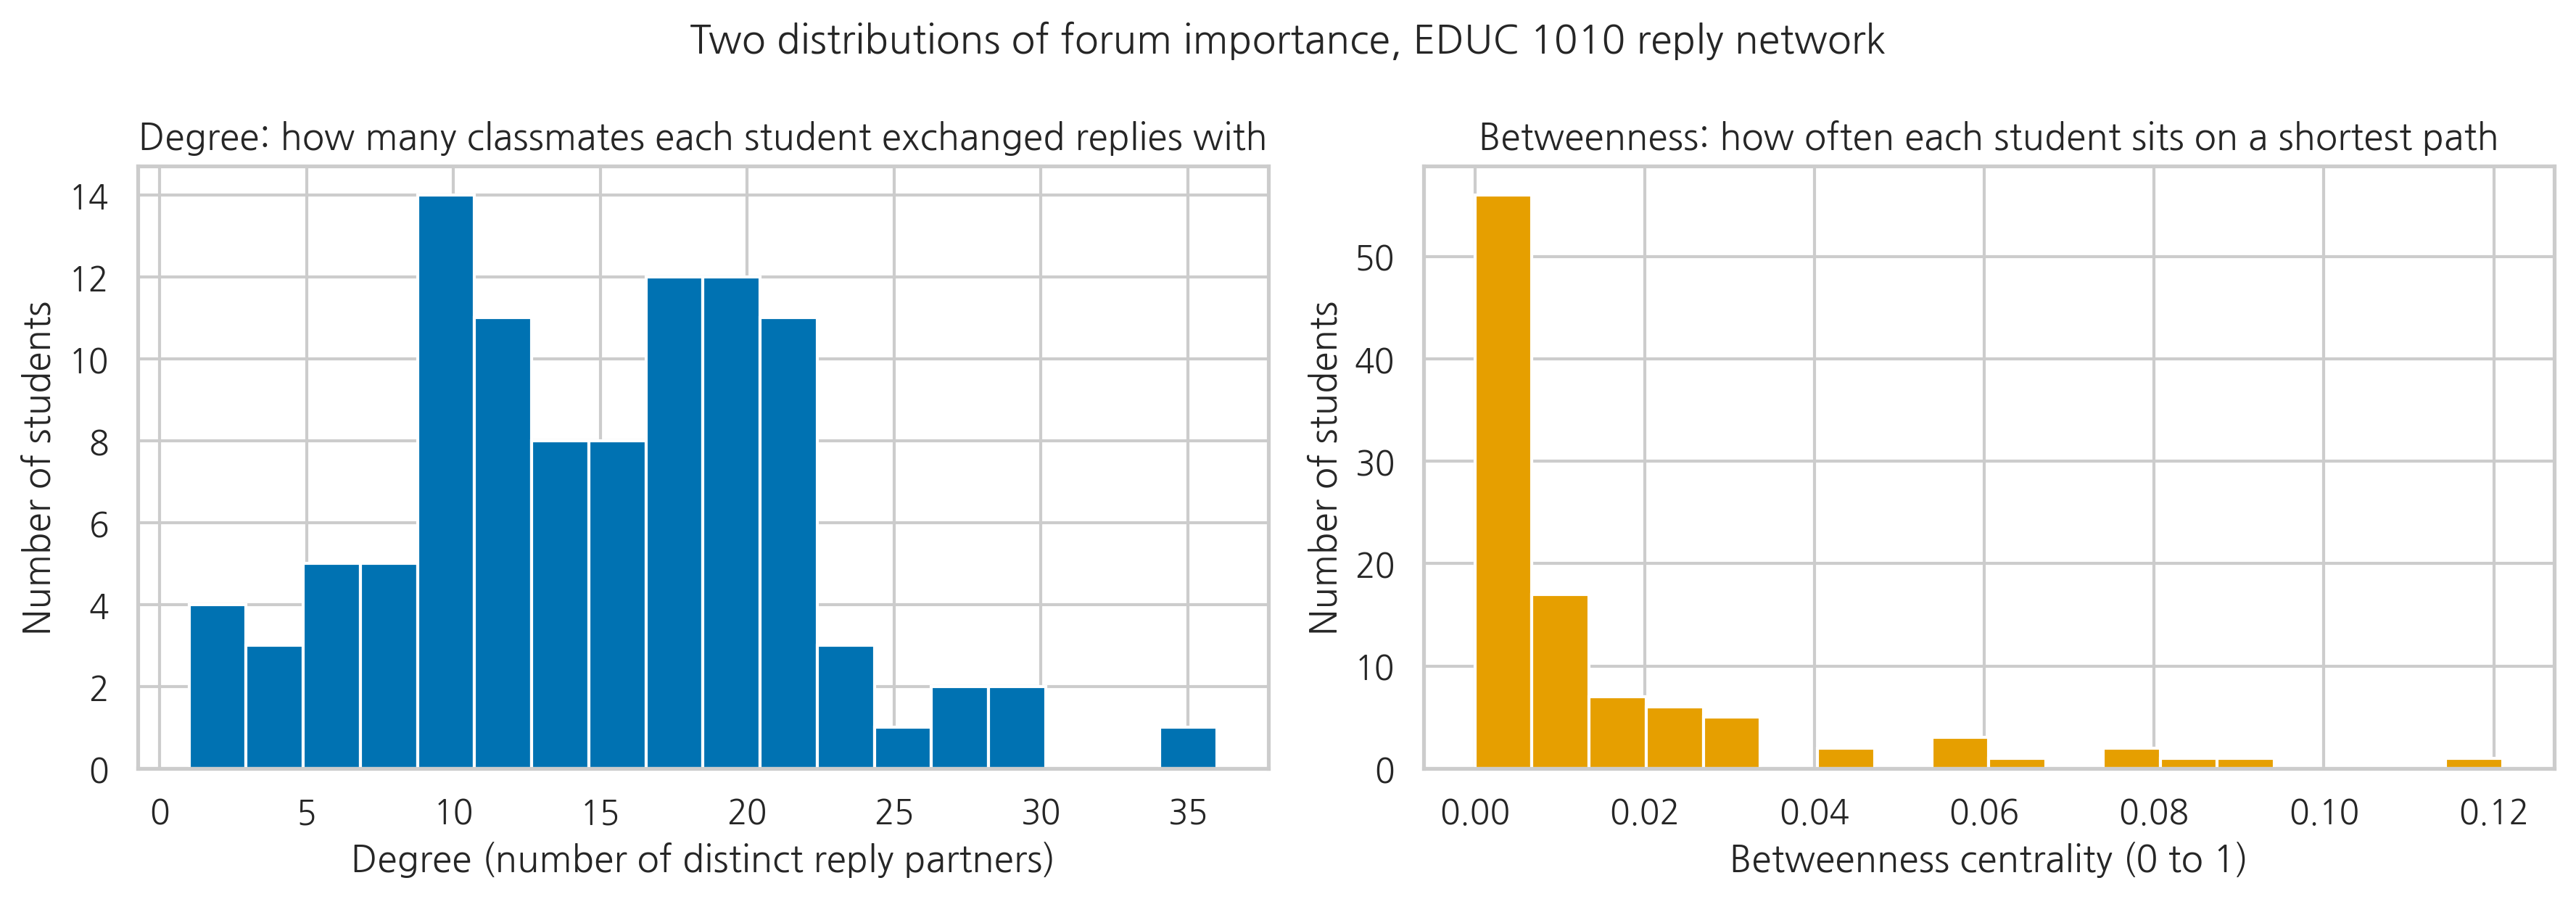

Top 8 by degree:
student_id  degree  betweenness  betweenness_pct
      S039      36     0.121073            100.0
      S002      29     0.057132             93.0
      S087      29     0.010613             66.0
      S057      28     0.046246             90.0
      S065      27     0.088723             99.0
      S045      25     0.021972             80.0
      S072      24     0.033462             89.0
      S076      24     0.046325             91.0

Top 8 by betweenness:
student_id  degree  degree_pct  betweenness
      S039      36       100.0     0.121073
      S065      27        96.0     0.088723
      S020      18        65.0     0.082370
      S043      19        72.0     0.075978
      S101      17        59.0     0.075393
      S075      22        88.0     0.065737
      S031      15        52.0     0.059042
      S002      29        99.0     0.057132


In [8]:
degree      = dict(G.degree())
betweenness = nx.betweenness_centrality(G)          # normalized to 0 to 1
strength    = dict(G.degree(weight='weight'))       # ties, counting repeats

cent = pd.DataFrame({'student_id': sorted(G.nodes())})
cent['degree']      = cent['student_id'].map(degree)
cent['strength']    = cent['student_id'].map(strength)
cent['betweenness'] = cent['student_id'].map(betweenness)
cent['degree_pct']      = (cent['degree'].rank(pct=True) * 100).round(0)
cent['betweenness_pct'] = (cent['betweenness'].rank(pct=True) * 100).round(0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].hist(cent['degree'], bins=18, color=BLUE, edgecolor='white')
axes[0].set_title('Degree: how many classmates each student exchanged replies with')
axes[0].set_xlabel('Degree (number of distinct reply partners)')
axes[0].set_ylabel('Number of students')

axes[1].hist(cent['betweenness'], bins=18, color=ORANGE, edgecolor='white')
axes[1].set_title('Betweenness: how often each student sits on a shortest path')
axes[1].set_xlabel('Betweenness centrality (0 to 1)')
axes[1].set_ylabel('Number of students')

fig.suptitle('Two distributions of forum importance, EDUC 1010 reply network', fontsize=13)
fig.tight_layout()
plt.show()

print('Top 8 by degree:')
print(cent.nlargest(8, 'degree')[['student_id', 'degree', 'betweenness', 'betweenness_pct']].to_string(index=False))
print()
print('Top 8 by betweenness:')
print(cent.nlargest(8, 'betweenness')[['student_id', 'degree', 'degree_pct', 'betweenness']].to_string(index=False))

**💬 Interpretation prompt.** Compare the two top-8 lists. Some names appear on both. Some appear on only one.
Pick one student who ranks high on betweenness but sits nowhere near the top on degree, and write a sentence
predicting what their position in the forum looks like. You are about to find out whether you were right.

## 1.5 Putting the two measures on one picture

A table of ranks makes it easy to miss the students who are interesting *because* their two ranks disagree.
A scatterplot makes that disagreement visible: degree on the horizontal axis, betweenness on the vertical.

The reference lines mark the class median degree and the 90th percentile of betweenness. The upper-left region
(unremarkable degree, unusually high betweenness) is where the interesting people live. The upper-right region
holds the students who are central simply because they are everywhere, which is a different phenomenon and
worth less of your attention than it usually gets.

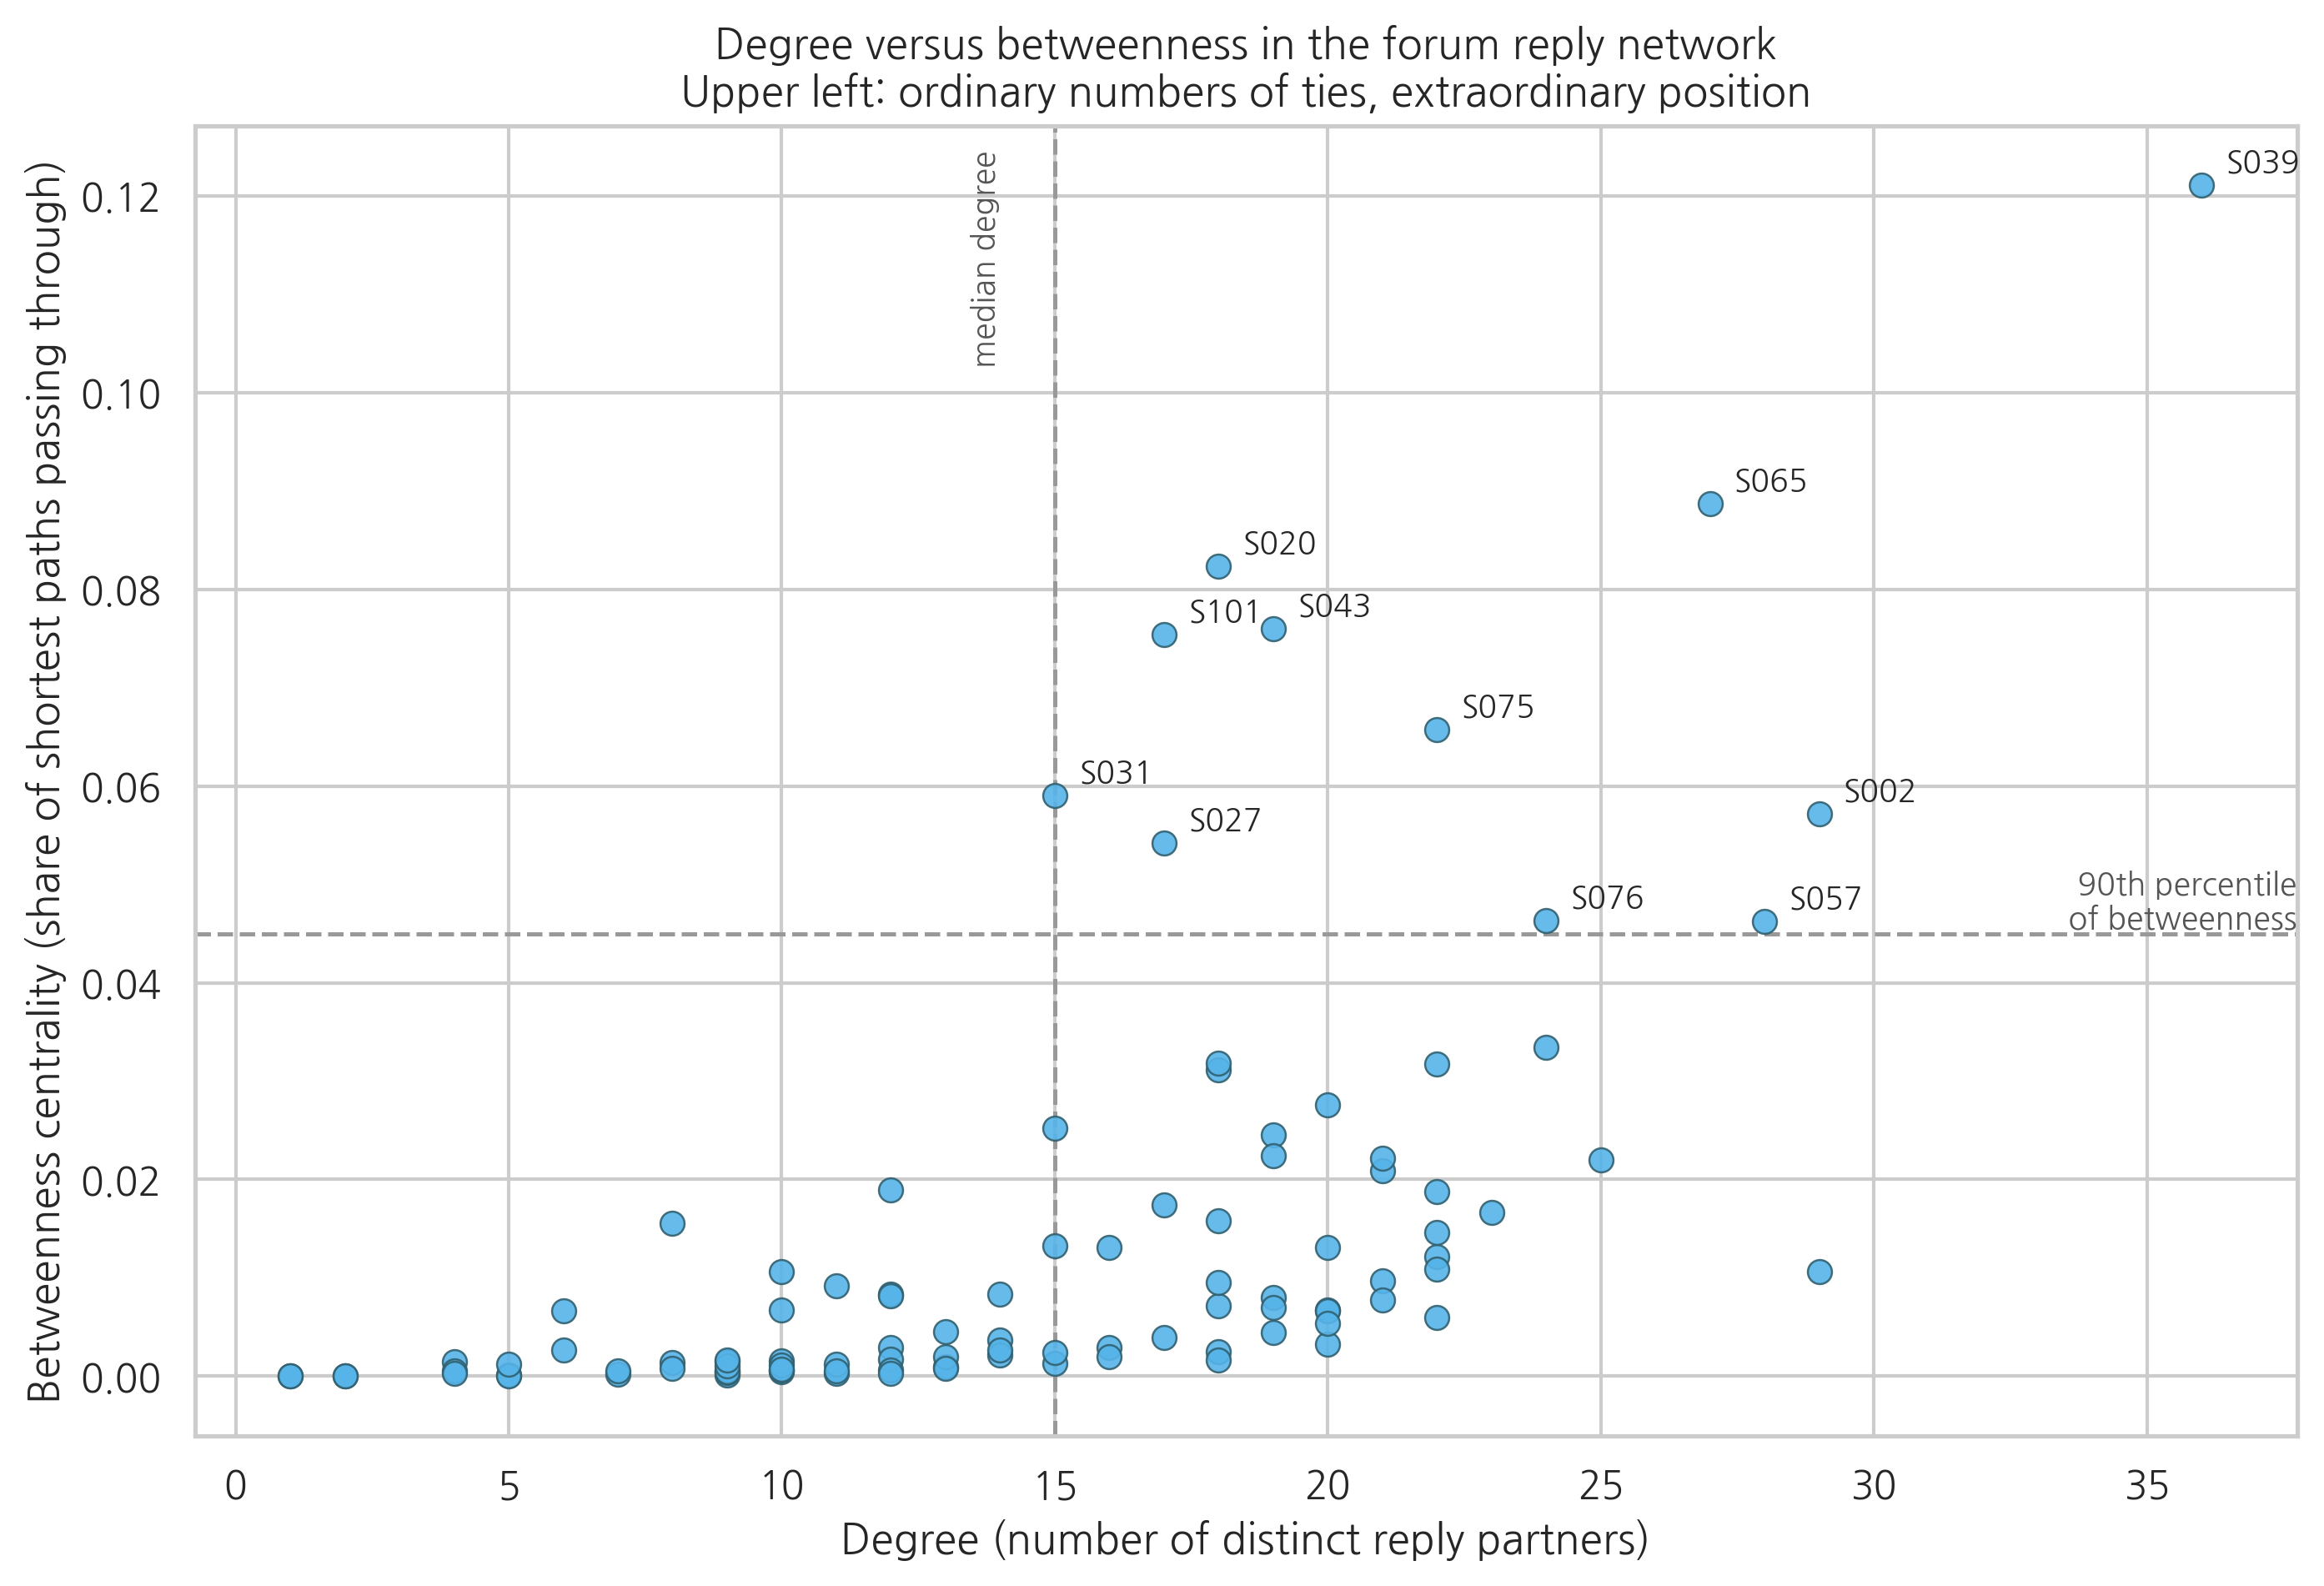

Students with top-10 percent betweenness but no more than the 75th percentile of degree:
student_id  degree  degree_pct  betweenness  betweenness_pct
      S020      18        65.0     0.082370             98.0
      S043      19        72.0     0.075978             97.0
      S101      17        59.0     0.075393             96.0
      S031      15        52.0     0.059042             94.0
      S027      17        59.0     0.054169             92.0


In [9]:
deg_median = cent['degree'].median()
btw_p90    = cent['betweenness'].quantile(0.90)

fig, ax = plt.subplots(figsize=(9.5, 6.5))
ax.scatter(cent['degree'], cent['betweenness'], s=48, color=SKY,
           edgecolor='#31606f', linewidth=0.6, alpha=0.9, zorder=3)

ax.axvline(deg_median, color=GRAY, linestyle='--', linewidth=1.2, zorder=2)
ax.axhline(btw_p90, color=GRAY, linestyle='--', linewidth=1.2, zorder=2)

# Label everyone above the betweenness cut so the shortlist is readable.
for row in cent[cent['betweenness'] >= btw_p90].itertuples(index=False):
    ax.annotate(row.student_id, (row.degree, row.betweenness),
                textcoords='offset points', xytext=(7, 4), fontsize=9)

ax.text(deg_median - 1, ax.get_ylim()[1] * 0.98, 'median degree',
        rotation=90, ha='right', va='top', fontsize=9, color='#555555')
ax.text(ax.get_xlim()[1], btw_p90, ' 90th percentile\n of betweenness',
        ha='right', va='bottom', fontsize=9, color='#555555')

ax.set_title('Degree versus betweenness in the forum reply network\n'
             'Upper left: ordinary numbers of ties, extraordinary position')
ax.set_xlabel('Degree (number of distinct reply partners)')
ax.set_ylabel('Betweenness centrality (share of shortest paths passing through)')
fig.tight_layout()
plt.show()

shortlist = cent[(cent['betweenness'] >= btw_p90) & (cent['degree'] <= cent['degree'].quantile(0.75))]
print('Students with top-10 percent betweenness but no more than the 75th percentile of degree:')
print(shortlist[['student_id', 'degree', 'degree_pct', 'betweenness', 'betweenness_pct']]
      .sort_values('betweenness', ascending=False).to_string(index=False))

**💬 Interpretation prompt.** The scatterplot has given you a shortlist, not an answer. Compare the two top-8
lists printed in section 1.4: three students appear on both. Those three sit at the far right of this plot,
and they are on many shortest paths because they are attached to almost everyone, which is not the same thing
as bridging. Before you read on, write down
what evidence would convince you that a particular student is a **bridge** rather than a **hub**.

## 1.6 Finding the communities

To talk about bridging we need something to bridge. Community detection partitions the graph so that ties are
dense inside groups and sparse between them. We use greedy modularity optimization (Clauset, Newman, and Moore),
which is available directly in `networkx` and is deterministic, so your result will match your neighbor's.

**Modularity** is the quality score: roughly, how much more within-group connection there is than you would
expect if the same students had wired themselves at random. Values above about 0.3 are usually taken as real
structure. Nothing here tells you *why* the groups exist, and modularity will happily hand you communities in a
graph that has none, which is why the number matters.

In [10]:
communities = nx.community.greedy_modularity_communities(G, weight='weight')
community_of = {node: i for i, group in enumerate(communities) for node in group}
cent['community'] = cent['student_id'].map(community_of)

Q = nx.community.modularity(G, communities, weight='weight')
print('Communities found :', len(communities))
print('Modularity (Q)    :', round(Q, 3))
print()
print(cent.groupby('community')
          .agg(students=('student_id', 'size'),
               mean_degree=('degree', 'mean'),
               mean_betweenness=('betweenness', 'mean'))
          .round(3).to_string())

within  = sum(1 for a, b in G.edges() if community_of[a] == community_of[b])
across  = G.number_of_edges() - within
print()
print('Ties inside a community :', within)
print('Ties across communities :', across,
      '(' + str(round(100 * across / G.number_of_edges(), 1)) + ' percent of all ties)')

Communities found : 3
Modularity (Q)    : 0.612

           students  mean_degree  mean_betweenness
community                                         
0                36       16.722             0.014
1                34       13.382             0.016
2                32       13.969             0.013

Ties inside a community : 700
Ties across communities : 52 (6.9 percent of all ties)


## 1.7 Bridges, not hubs

Now we can separate the two kinds of importance cleanly. For each student, compute the share of their ties that
leave their own community:

`bridge_share = ties to other communities / total ties`

A hub has hundreds of ties and almost all of them are local, so its bridge share is low. A bridge has an
ordinary number of ties and an unusual share of them cross a boundary. We require at least a handful of ties
(`MIN_DEGREE`) so that a student with two ties, one of which happens to cross, does not top the list by
accident.

Connectors found: 4
student_id  community  degree  degree_pct  ties_across  bridge_share  betweenness  betweenness_pct
      S020          1      18        65.0           14         0.778        0.082             98.0
      S101          0      17        59.0            9         0.529        0.075             96.0
      S031          0      15        52.0            7         0.467        0.059             94.0
      S043          1      19        72.0            8         0.421        0.076             97.0


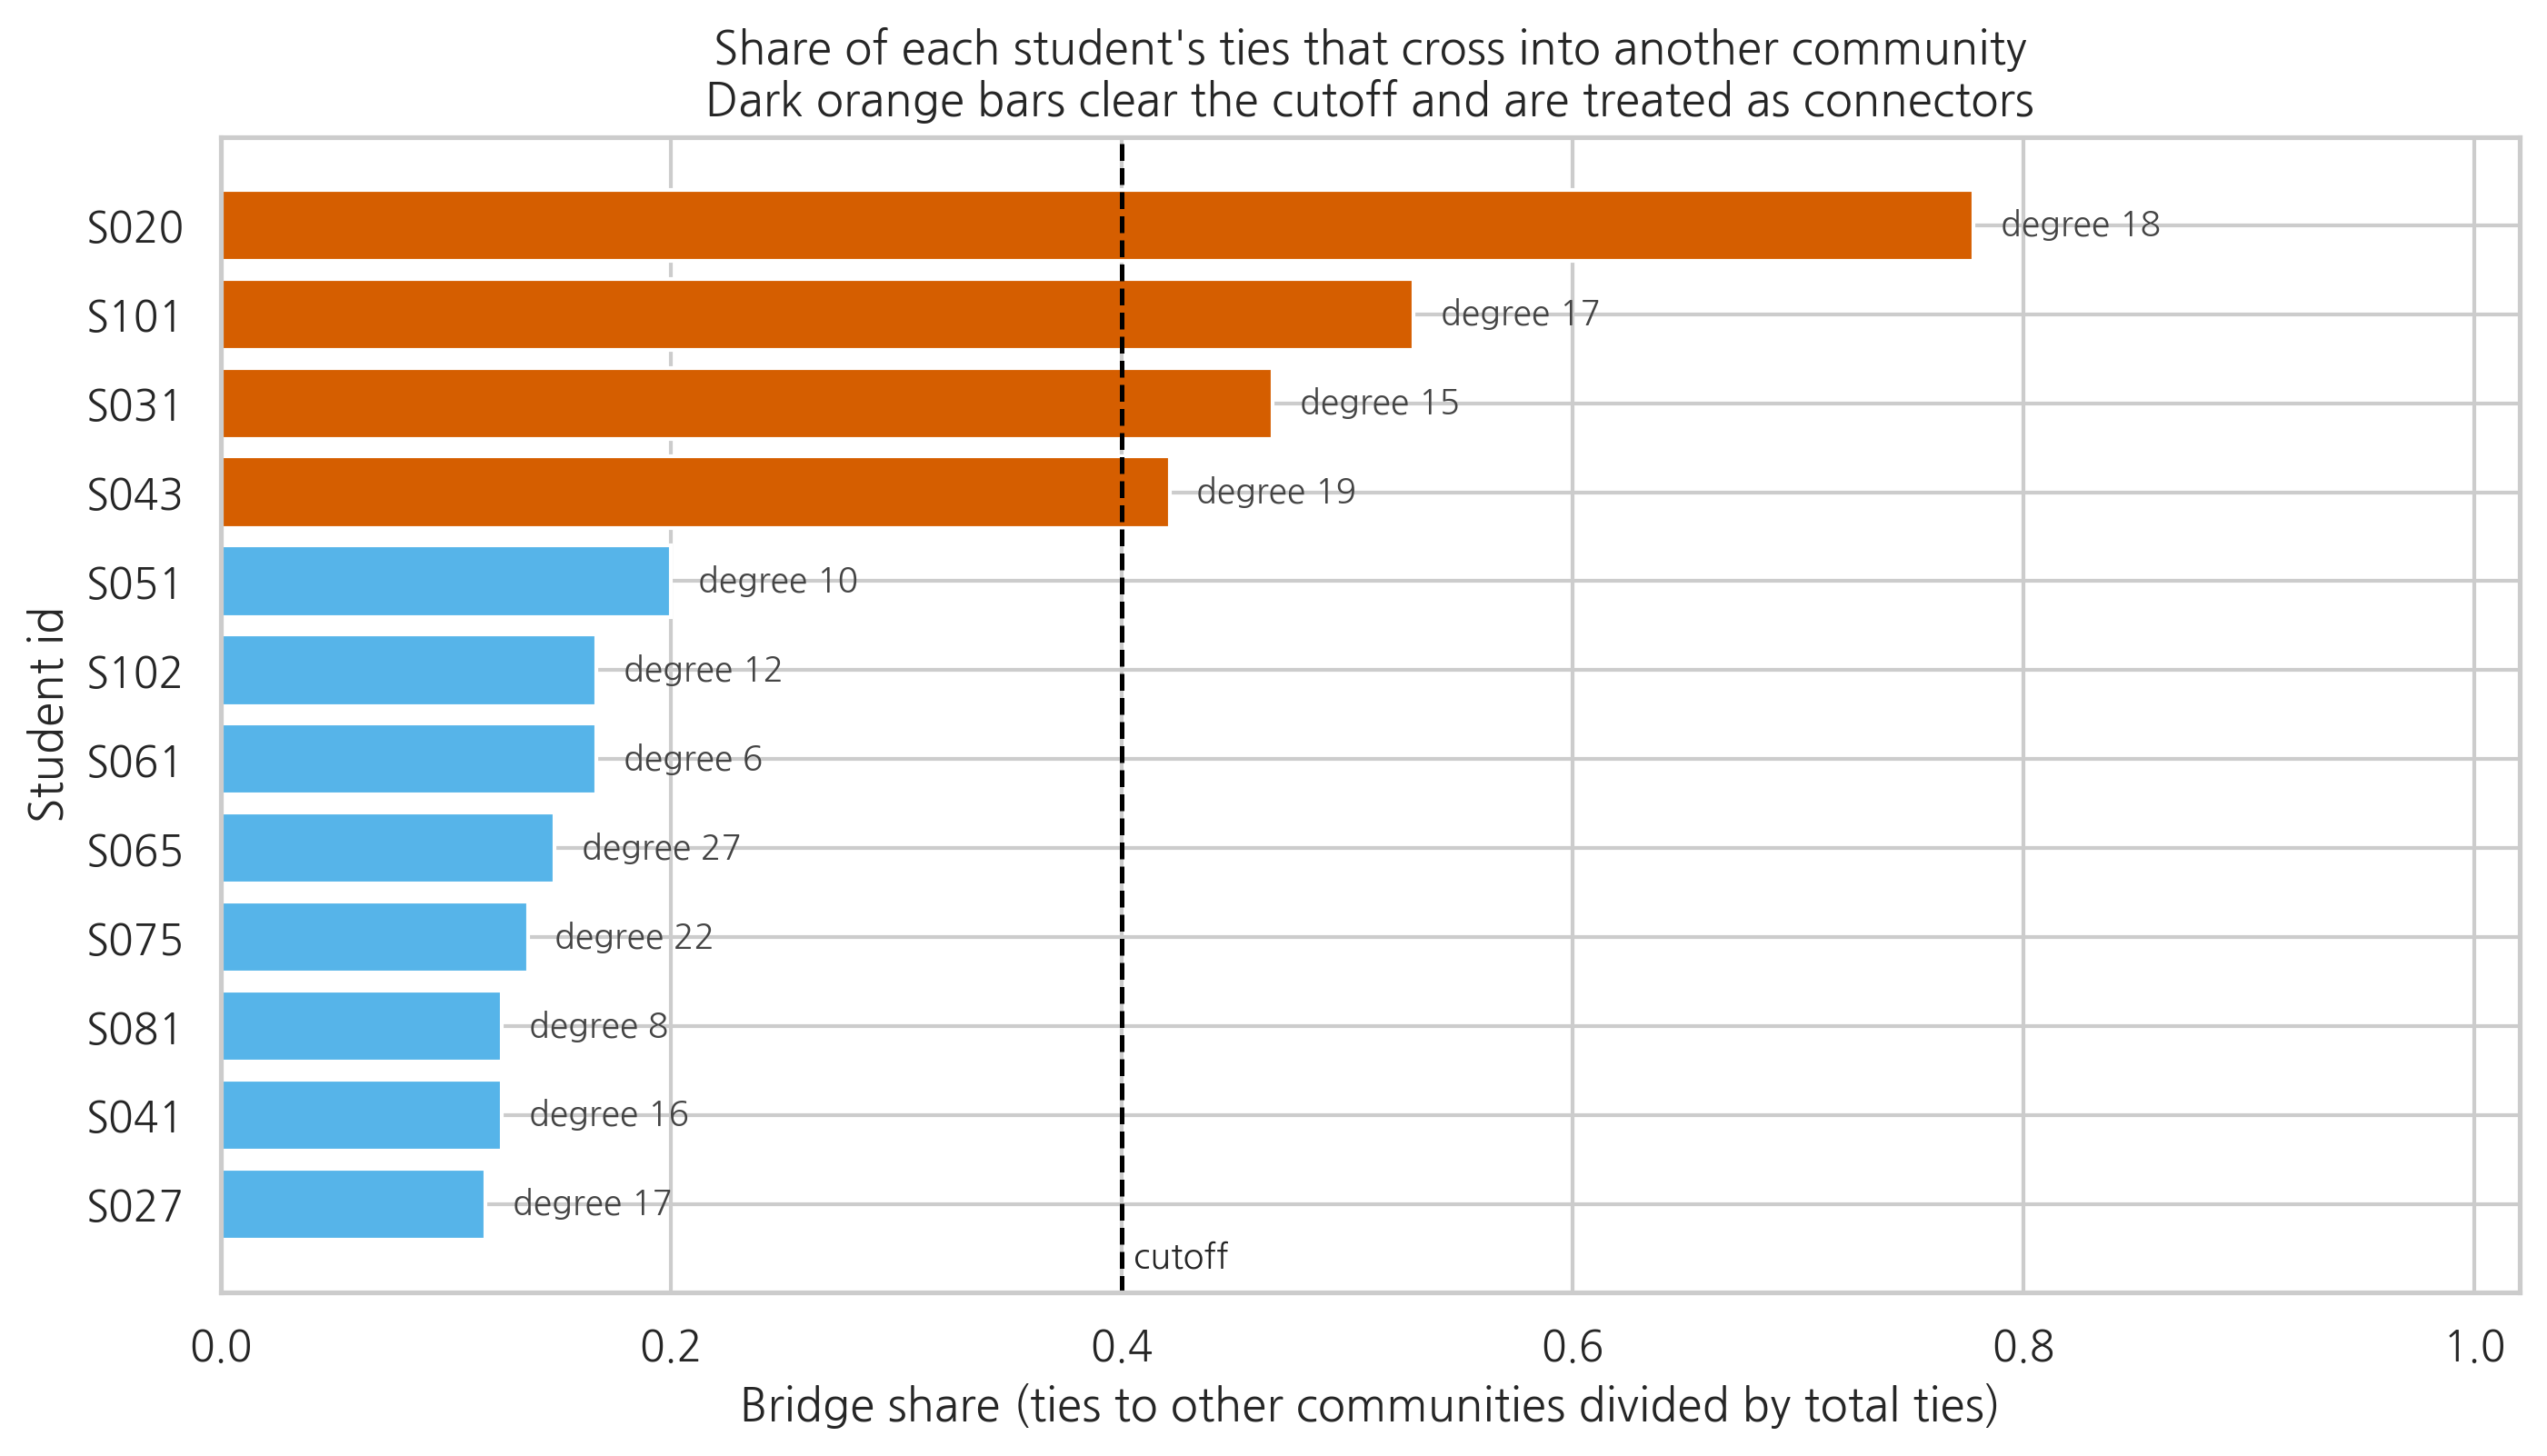

In [11]:
MIN_DEGREE    = 5      # ignore students with too few ties for the share to mean anything
BRIDGE_CUTOFF = 0.40   # a student is a connector if at least this share of their ties cross a community line

external = {n: sum(1 for m in G[n] if community_of[m] != community_of[n]) for n in G.nodes()}
cent['ties_across']  = cent['student_id'].map(external)
cent['bridge_share'] = cent['ties_across'] / cent['degree']

eligible  = cent[cent['degree'] >= MIN_DEGREE].copy()
connectors = (eligible[eligible['bridge_share'] >= BRIDGE_CUTOFF]
              .sort_values('bridge_share', ascending=False))

print('Connectors found:', len(connectors))
print(connectors[['student_id', 'community', 'degree', 'degree_pct',
                  'ties_across', 'bridge_share', 'betweenness', 'betweenness_pct']]
      .round(3).to_string(index=False))

connector_ids = connectors['student_id'].tolist()

top12 = eligible.nlargest(12, 'bridge_share').sort_values('bridge_share')
colors = [VERMILLION if s in connector_ids else SKY for s in top12['student_id']]

fig, ax = plt.subplots(figsize=(9.5, 5.5))
bars = ax.barh(top12['student_id'], top12['bridge_share'], color=colors, edgecolor='white')
for bar, deg in zip(bars, top12['degree']):
    ax.text(bar.get_width() + 0.012, bar.get_y() + bar.get_height() / 2,
            'degree ' + str(int(deg)), va='center', fontsize=9, color='#444444')
ax.axvline(BRIDGE_CUTOFF, color='black', linestyle='--', linewidth=1.2)
ax.text(BRIDGE_CUTOFF + 0.005, -0.7, 'cutoff', fontsize=9)
ax.set_xlim(0, 1.02)
ax.set_title('Share of each student\'s ties that cross into another community\n'
             'Dark orange bars clear the cutoff and are treated as connectors')
ax.set_xlabel('Bridge share (ties to other communities divided by total ties)')
ax.set_ylabel('Student id')
fig.tight_layout()
plt.show()

**💬 Interpretation prompt.** Look at the gap in the bar chart. There is a cluster of students far above the
cutoff and then a long drop, which means the cutoff value is doing much less work than it might appear. Compare
these students' degree percentiles against their betweenness percentiles in the printed table. Would any
dashboard you have seen this semester (including the one you built in Mini Project 1) have surfaced these
students? What would this forum look like in week 9 if all of them stopped posting?

## 1.8 The sociogram

Now draw it. A sociogram is just the graph with a layout: `spring_layout` treats edges as springs and pushes
unconnected nodes apart, so densely tied groups end up near each other. The layout has no units and no axes.
Position means nothing except relative connection, which is why we label the picture carefully instead of
inviting people to read distances off it.

Reading aids in this figure: node color is community, node size is degree, faint gray lines are ties inside a
community, heavy black lines are ties that cross between communities, and the ringed and labeled nodes are the
connectors we identified above.

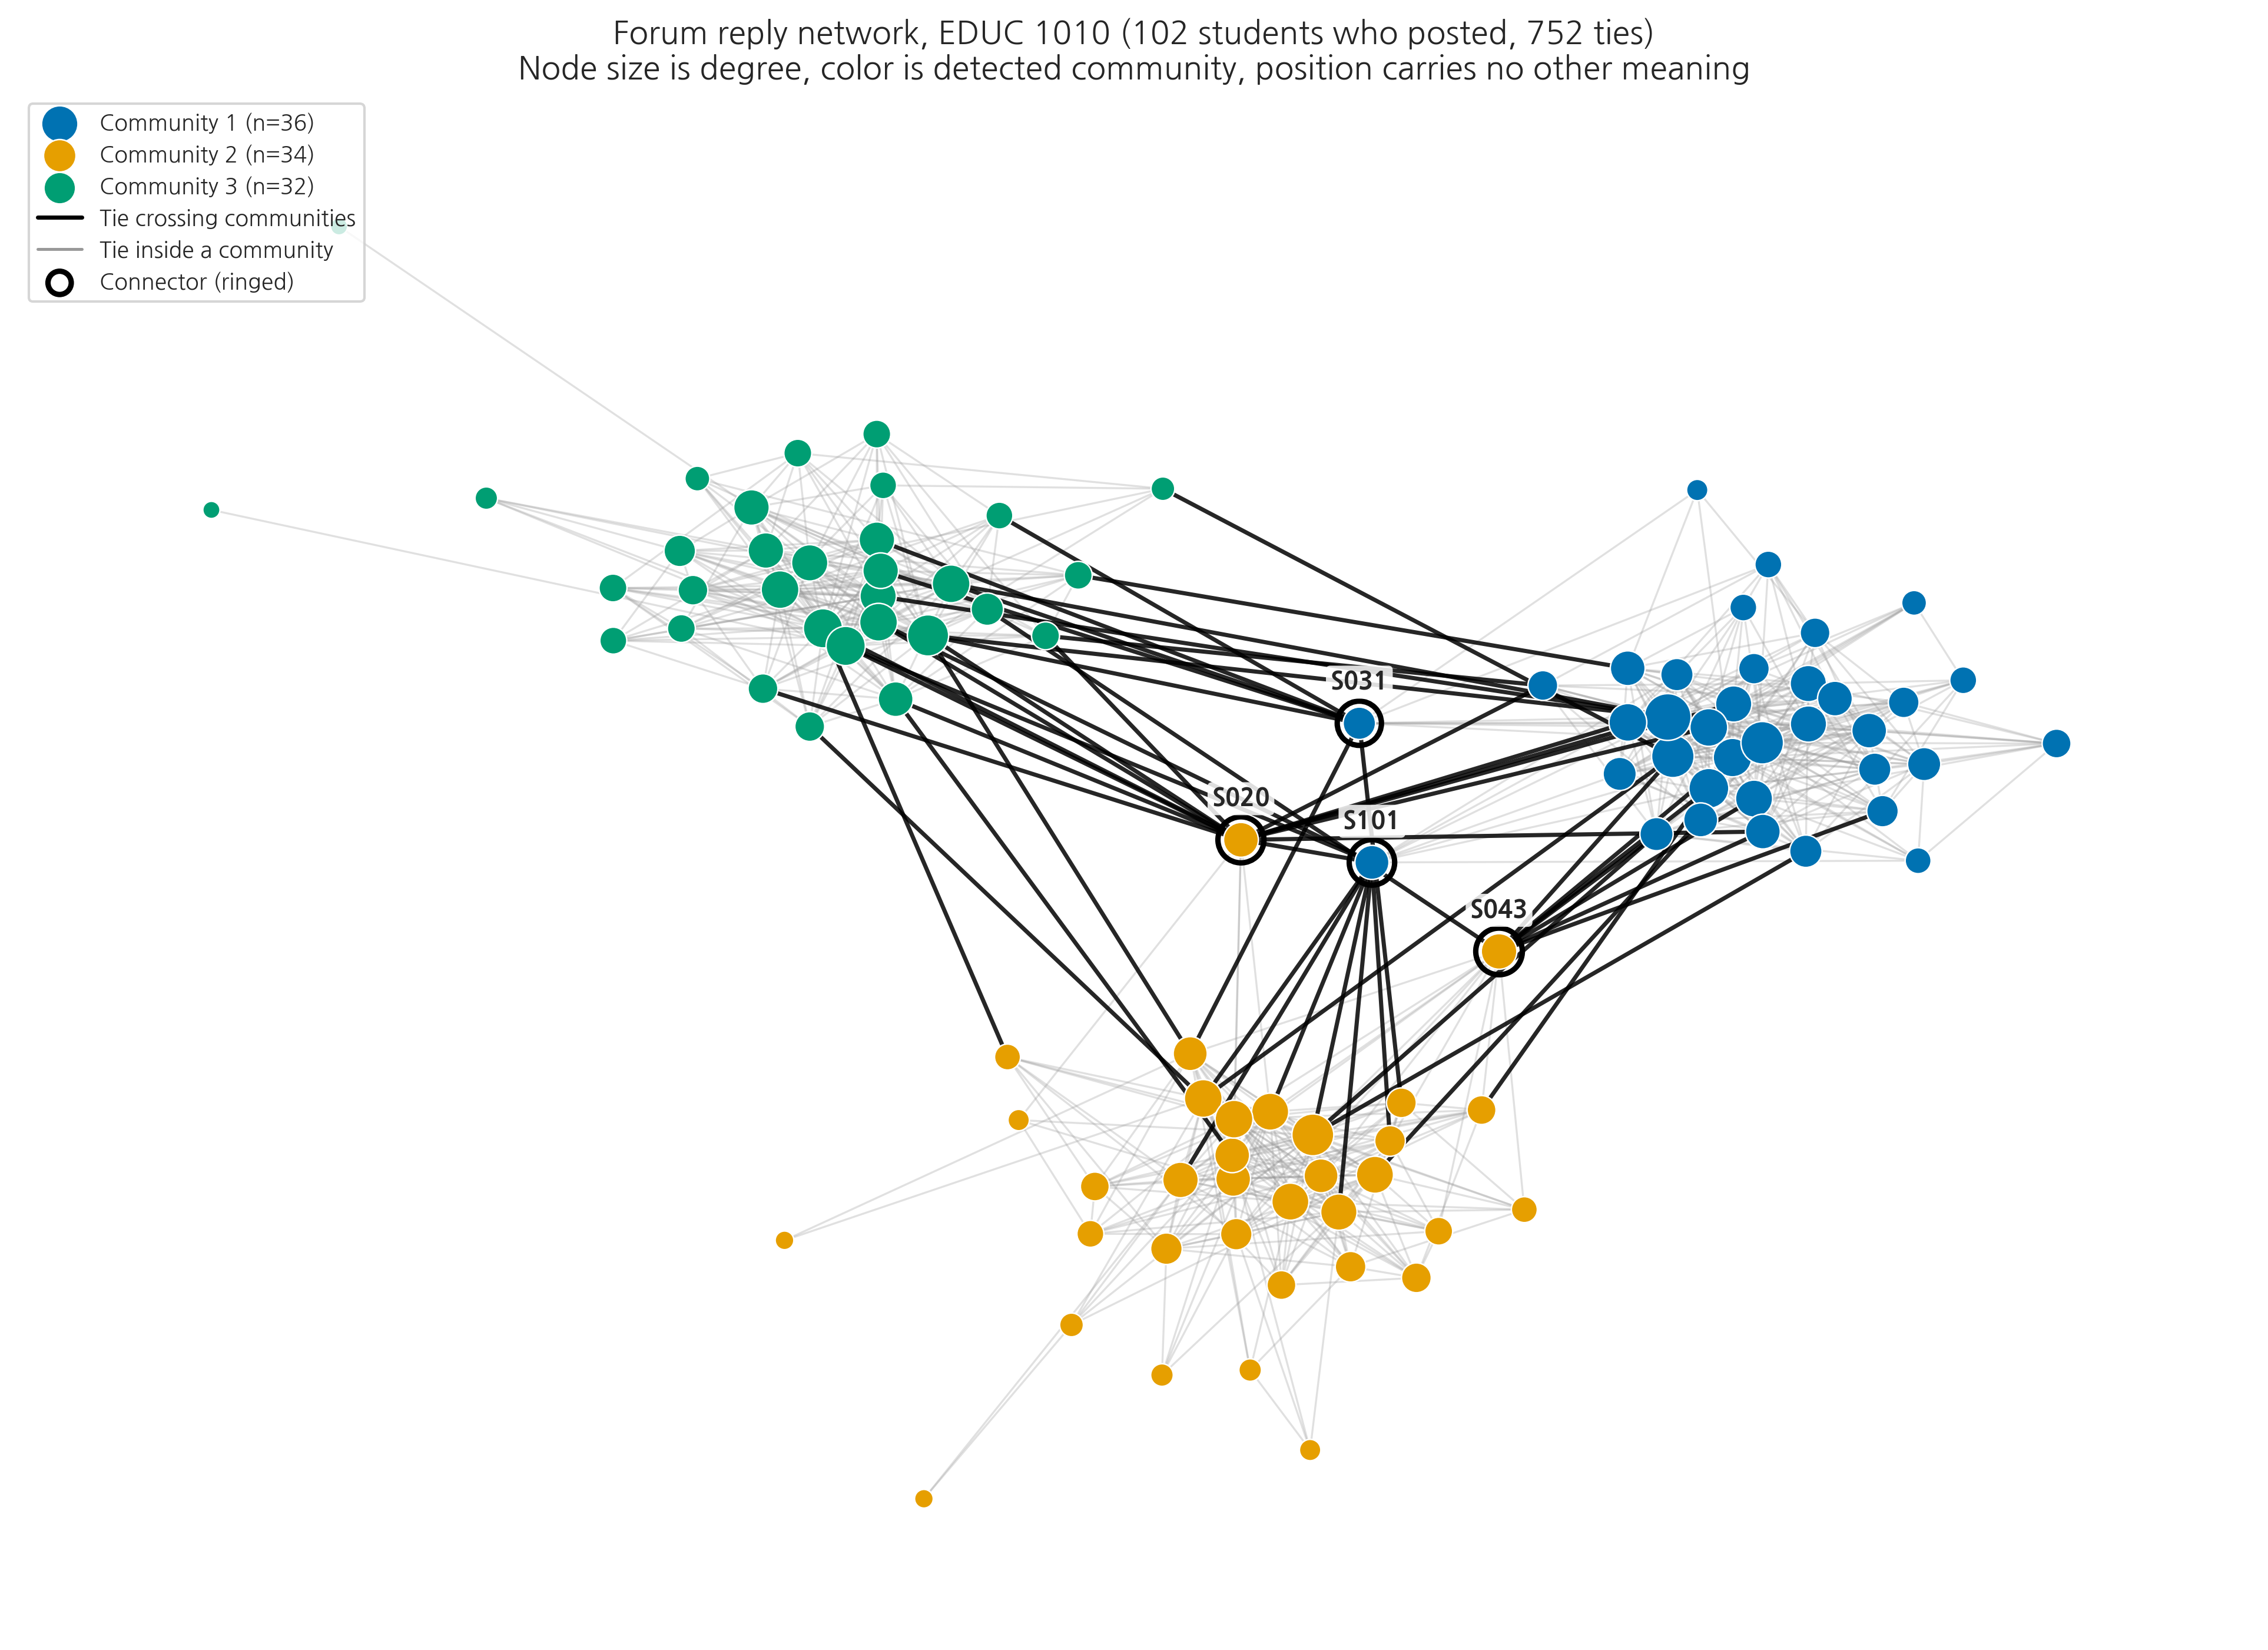

In [12]:
pos = nx.spring_layout(G, seed=8100, k=0.55, iterations=200, weight='weight')

within_edges = [(a, b) for a, b in G.edges() if community_of[a] == community_of[b]]
across_edges = [(a, b) for a, b in G.edges() if community_of[a] != community_of[b]]

fig, ax = plt.subplots(figsize=(13, 9.5))
nx.draw_networkx_edges(G, pos, edgelist=within_edges, ax=ax,
                       edge_color=GRAY, width=0.8, alpha=0.30)
nx.draw_networkx_edges(G, pos, edgelist=across_edges, ax=ax,
                       edge_color='black', width=1.7, alpha=0.85)

for i, group in enumerate(communities):
    nodes = sorted(group)
    nx.draw_networkx_nodes(G, pos, nodelist=nodes, ax=ax,
                           node_size=[40 + 9 * degree[n] for n in nodes],
                           node_color=CLUSTER_COLORS[i % len(CLUSTER_COLORS)],
                           edgecolors='white', linewidths=0.6,
                           label='Community ' + str(i + 1) + ' (n=' + str(len(nodes)) + ')')

nx.draw_networkx_nodes(G, pos, nodelist=connector_ids, ax=ax,
                       node_size=[190 + 9 * degree[n] for n in connector_ids],
                       node_color='none', edgecolors='black', linewidths=2.2)

for n in connector_ids:
    ax.annotate(n, (pos[n][0], pos[n][1]), textcoords='offset points', xytext=(0, 14),
                ha='center', fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.18', facecolor='white', edgecolor='none', alpha=0.85))

ax.plot([], [], color='black', linewidth=1.7, label='Tie crossing communities')
ax.plot([], [], color=GRAY, linewidth=1.2, label='Tie inside a community')
ax.scatter([], [], s=90, facecolor='none', edgecolor='black', linewidth=2.2, label='Connector (ringed)')
ax.legend(loc='upper left', fontsize=9, frameon=True)

ax.set_title('Forum reply network, EDUC 1010 (' + str(G.number_of_nodes()) + ' students who posted, '
             + str(G.number_of_edges()) + ' ties)\n'
             'Node size is degree, color is detected community, position carries no other meaning',
             fontsize=13)
ax.axis('off')
fig.tight_layout()
plt.show()

**💬 Interpretation prompt.** Answer three questions in a sentence each.

1. The ringed students sit in the middle of the picture. Are they in the middle because they are popular, or
   because of something else? Use the numbers from section 1.7, not the picture, to defend your answer.
2. One hundred and two nodes are drawn here. One hundred and twenty students are enrolled. Where are the other
   eighteen in this figure, and what would you have to say in a memo to keep a reader from forgetting them?
3. Poquet and Joksimovic (2022) call the field a "cacophony of networks" partly because the same students
   produce a different graph depending on what you count as a tie. Name one other tie definition you could have
   used with this dataset, and say who would gain or lose visibility under it.

## ✏️ Your turn 1: move the connector thresholds

The two numbers below decided who counted as a connector. They are judgment calls, not discoveries, and part of
doing this well is knowing how fragile your finding is when you move them.

Change `MY_MIN_DEGREE` and `MY_BRIDGE_CUTOFF`, then run the cell. Try a cutoff of `0.25` and watch how many
students qualify. Try `MY_MIN_DEGREE = 2` and see who a low bar lets in.

In [13]:
# TODO: change one or both of these numbers, then run the cell.
MY_MIN_DEGREE    = 5      # working default
MY_BRIDGE_CUTOFF = 0.40   # working default

my_pool = cent[cent['degree'] >= MY_MIN_DEGREE]
my_connectors = (my_pool[my_pool['bridge_share'] >= MY_BRIDGE_CUTOFF]
                 .sort_values('bridge_share', ascending=False))

print('With min degree', MY_MIN_DEGREE, 'and cutoff', MY_BRIDGE_CUTOFF,
      'the connector list has', len(my_connectors), 'students:')
print(my_connectors[['student_id', 'degree', 'ties_across', 'bridge_share', 'betweenness']]
      .round(3).to_string(index=False))

With min degree 5 and cutoff 0.4 the connector list has 4 students:
student_id  degree  ties_across  bridge_share  betweenness
      S020      18           14         0.778        0.082
      S101      17            9         0.529        0.075
      S031      15            7         0.467        0.059
      S043      19            8         0.421        0.076


## ✏️ Your turn 2: one week at a time

The network above pools all eight weeks, which quietly assumes that a reply in week 1 and a reply in week 8
mean the same thing and belong in the same picture. Molenaar and Wise (2022) would call that an assumption
about time worth stating out loud.

Change `WEEK_TO_INSPECT` to any week from 1 to 8 and rerun. Notice how much thinner a single week is, and how
much less stable the centrality ranking becomes when it rests on fewer ties.

In [14]:
# TODO: change this to any week from 1 to 8.
WEEK_TO_INSPECT = 3   # working default

week_posts = forum[forum['week'] == WEEK_TO_INSPECT]
G_week = build_reply_network(week_posts)

print('Week', WEEK_TO_INSPECT, ': posts =', len(week_posts),
      '| students in network =', G_week.number_of_nodes(),
      '| ties =', G_week.number_of_edges(),
      '| density =', round(nx.density(G_week), 3),
      '| components =', nx.number_connected_components(G_week))

week_btw = nx.betweenness_centrality(G_week)
week_tab = (pd.DataFrame({'student_id': list(week_btw), 'betweenness': list(week_btw.values())})
            .assign(degree=lambda d: d['student_id'].map(dict(G_week.degree())))
            .nlargest(5, 'betweenness'))
print()
print('Top 5 by betweenness in week', str(WEEK_TO_INSPECT) + ':')
print(week_tab.round(3).to_string(index=False))

Week 3 : posts = 177 | students in network = 74 | ties = 147 | density = 0.054 | components = 1

Top 5 by betweenness in week 3:
student_id  betweenness  degree
      S084        0.347       6
      S067        0.308       4
      S082        0.235       4
      S040        0.233       8
      S043        0.225       3


---

# Part 2. ⏱️ Time, order, and a hypothesis that does not survive

Everything from here runs on the **real** Open University data.

You are about to do something this course has not asked of you yet. You hold a belief about learning, you have
held it for six weeks, the data you held it in confirmed it, and now you are going to test it somewhere else.

Do it in the right order. State the belief first, in writing, while it still feels obvious. Then test it. The
order matters, because a hypothesis stated after the result is not a hypothesis, and every one of us can talk
ourselves into having expected whatever we happen to find.

## 2.1 State the expectation, out loud, before you look

Since week 1 you have been living in a simulated course, and one of the things that course taught you is that
students who submit close to the deadline score lower. You met it as a teaser in week 2. Here it is measured
properly, on the synthetic gradebook, using the same 960 quiz submissions you have been analysing all term.

Two numbers, and please look at them before you go on:

- the correlation between how early a quiz arrived and what it scored, and
- Cohen's *d* between work submitted in the final six hours and everything else.

Cohen's *d* is a difference between two group means expressed in standard deviations, so it can be compared
across measures and studies. Roughly: 0.2 is small, 0.5 is medium, 0.8 is large.

In [15]:
quizzes = grades[grades['assessment'].str.startswith('quiz')].copy()
quizzes['lead_hours'] = (quizzes['deadline'] - quizzes['submitted_at']).dt.total_seconds() / 3600
quizzes['days_early'] = quizzes['lead_hours'] / 24


def cohens_d(a, b):
    """Standardized difference between two groups, pooled standard deviation."""
    na, nb = len(a), len(b)
    pooled = np.sqrt(((na - 1) * a.var(ddof=1) + (nb - 1) * b.var(ddof=1)) / (na + nb - 2))
    return (a.mean() - b.mean()) / pooled


syn_r = np.corrcoef(quizzes['days_early'], quizzes['score'])[0, 1]
syn_last = quizzes.loc[quizzes['lead_hours'].between(0, 6), 'score']
syn_rest = quizzes.loc[quizzes['lead_hours'] > 6, 'score']
syn_d = cohens_d(syn_last, syn_rest)

print('THE SYNTHETIC COURSE (the world you have been living in)')
print('  Quiz submissions                        :', len(quizzes))
print('  r (days early, score)                   :', round(syn_r, 3))
print('  Submitted in the final 6 hours          :', len(syn_last), 'submissions, mean score',
      round(syn_last.mean(), 2))
print('  Submitted earlier than that             :', len(syn_rest), 'submissions, mean score',
      round(syn_rest.mean(), 2))
print("  Cohen's d, final 6 hours vs everyone else:", round(syn_d, 3))
print()
print('That is a large effect by any convention, and it points the way everyone')
print('expects it to point. Write your prediction for the real data before moving on.')

THE SYNTHETIC COURSE (the world you have been living in)
  Quiz submissions                        : 960
  r (days early, score)                   : 0.418
  Submitted in the final 6 hours          : 175 submissions, mean score 68.15
  Submitted earlier than that             : 752 submissions, mean score 77.61
  Cohen's d, final 6 hours vs everyone else: -0.752

That is a large effect by any convention, and it points the way everyone
expects it to point. Write your prediction for the real data before moving on.


**💬 Interpretation prompt.** In the cell below, or on paper, finish these three sentences
before you run anything else. You will be asked to come back to them.

1. "In the real Open University data, I expect the correlation between how early an assignment arrives and
   what it scores to be about ______, because ______."
2. "I expect students who submit a week or more early to score about ______ points higher or lower than
   students who submit on or after the deadline day."
3. "The mechanism I have in mind is ______." (Say it properly. Not "procrastination is bad", but what you
   think is actually happening to a person between deciding to start and pressing submit.)

## 2.2 Building the real lead-time table, mess and all

Now the real data. Two files have to meet: `submissions` says when each student handed each assignment in,
and `assessments` says when each assignment was due. Both use the same clock, **days counted from the first
day of the module**, so day 19 is nineteen days after teaching started and a negative number is before it.

Real files do not merge cleanly, and the next cell shows you the four places this one does not. Watch what we
drop, because each drop costs something:

1. **Two exams have no deadline date at all.** OULAD leaves the exam date blank. We cannot compute lead time
   for an assessment with no deadline, so both exams leave the analysis, and with them the single highest
   stakes assessment in the module.
2. **CMAs are a different animal.** The module has computer-marked assignments alongside tutor-marked ones.
   They are auto-graded, often multiple choice, and "handing in early" plausibly means something different
   for them. We keep only the tutor-marked ones, which sets aside 6,416 of the 21,783 submissions and leaves
   15,367 to work with.
3. **Some submissions have no score.** A handful of rows record that work arrived and record no mark. We drop
   them, because there is nothing to correlate.
4. **Some scores are banked.** `is_banked = 1` means the score was carried over from a previous attempt at
   the module in an earlier year. The submission date attached to it is not a date on which that student did
   that work. Keeping them is defensible, dropping them is defensible, and doing it silently is not, so we
   keep them in the headline and check separately whether they change anything.

In [16]:
sub = submissions.merge(assessments, on='id_assessment', how='left')

print('Every submission in the module, by assessment type:')
print(sub['assessment_type'].value_counts().to_string())
print()
print('Assessments with no deadline recorded:', int(assessments['date'].isna().sum()), 'of', len(assessments))
print(assessments[assessments['date'].isna()].to_string(index=False))
print()

tma = sub[sub['assessment_type'] == 'TMA'].copy()
n_noscore = int(tma['score'].isna().sum())
n_banked  = int((tma['is_banked'] == 1).sum())

print('DECISIONS, stated out loud')
print('  Tutor-marked submissions to start with :', f"{len(tma):,}")
print('  Dropped, no score recorded             :', n_noscore)
print('  Kept but flagged, banked from an')
print('  earlier attempt at the module          :', n_banked)

lead = tma[tma['score'].notna()].copy()
lead['days_early'] = lead['date'] - lead['date_submitted']

print('  Analysis set                           :', f"{len(lead):,}", 'submissions')
print()
print('What lead time looks like in the real world:')
print('  Earliest submission :', int(lead['days_early'].max()), 'days before the deadline')
print('  Latest submission   :', int(-lead['days_early'].min()), 'days after the deadline')
print('  Median              :', int(lead['days_early'].median()), 'day(s) early')
print('  Handed in late      :', f"{int((lead['days_early'] < 0).sum()):,}", 'submissions')
print('  Handed in on the')
print('  deadline day itself :', f"{int((lead['days_early'] == 0).sum()):,}", 'submissions')
print()
print(lead[['id_student', 'id_assessment', 'date_submitted', 'date', 'days_early', 'score']]
      .head(6).to_string(index=False))

Every submission in the module, by assessment type:
assessment_type
TMA    15367
CMA     6416

Assessments with no deadline recorded: 2 of 18
code_module code_presentation  id_assessment assessment_type  date  weight
        BBB             2013J          15002            Exam   NaN   100.0
        BBB             2014J          15025            Exam   NaN   100.0

DECISIONS, stated out loud
  Tutor-marked submissions to start with : 15,367
  Dropped, no score recorded             : 20
  Kept but flagged, banked from an
  earlier attempt at the module          : 146
  Analysis set                           : 15,347 submissions

What lead time looks like in the real world:
  Earliest submission : 209 days before the deadline
  Latest submission   : 174 days after the deadline
  Median              : 1 day(s) early
  Handed in late      : 2,292 submissions
  Handed in on the
  deadline day itself : 3,613 submissions

 id_student  id_assessment  date_submitted  date  days_early  score
   

## 2.3 The same test, on people who existed

Same two numbers as section 2.1, computed the same way, on the real data. Then the whole distribution, binned,
so that you can see the shape and not just a coefficient.

Read the bar chart carefully. The `n =` label above each bar is there because a mean computed from 861
submissions and a mean computed from 5,905 are not equally trustworthy, and the thin black error bars are
standard errors, which show you roughly how much each bar could wobble.

THE REAL MODULE (Open University BBB, 2013J and 2014J)
  Submissions analysed                    : 15,347
  r (days early, score)                   : 0.01
  Submitted 7 or more days early          : 1,619 submissions, mean score 66.84
  Submitted on or after the deadline day  : 5,905 submissions, mean score 67.44
  Cohen's d between those two groups      : -0.028

  Sensitivity check, dropping the 146 banked scores:
    n = 15,202 | r = 0.02 | Cohen's d = -0.036

Mean score by how early the work arrived:
                  submissions  mean_score     sd
band                                            
Late or same day         5905       67.44  17.65
1 to 2 days              5563       70.17  20.49
3 to 5 days              2001       69.58  23.23
6 to 10 days             1017       70.56  27.42
11 or more days           861       64.21  32.10


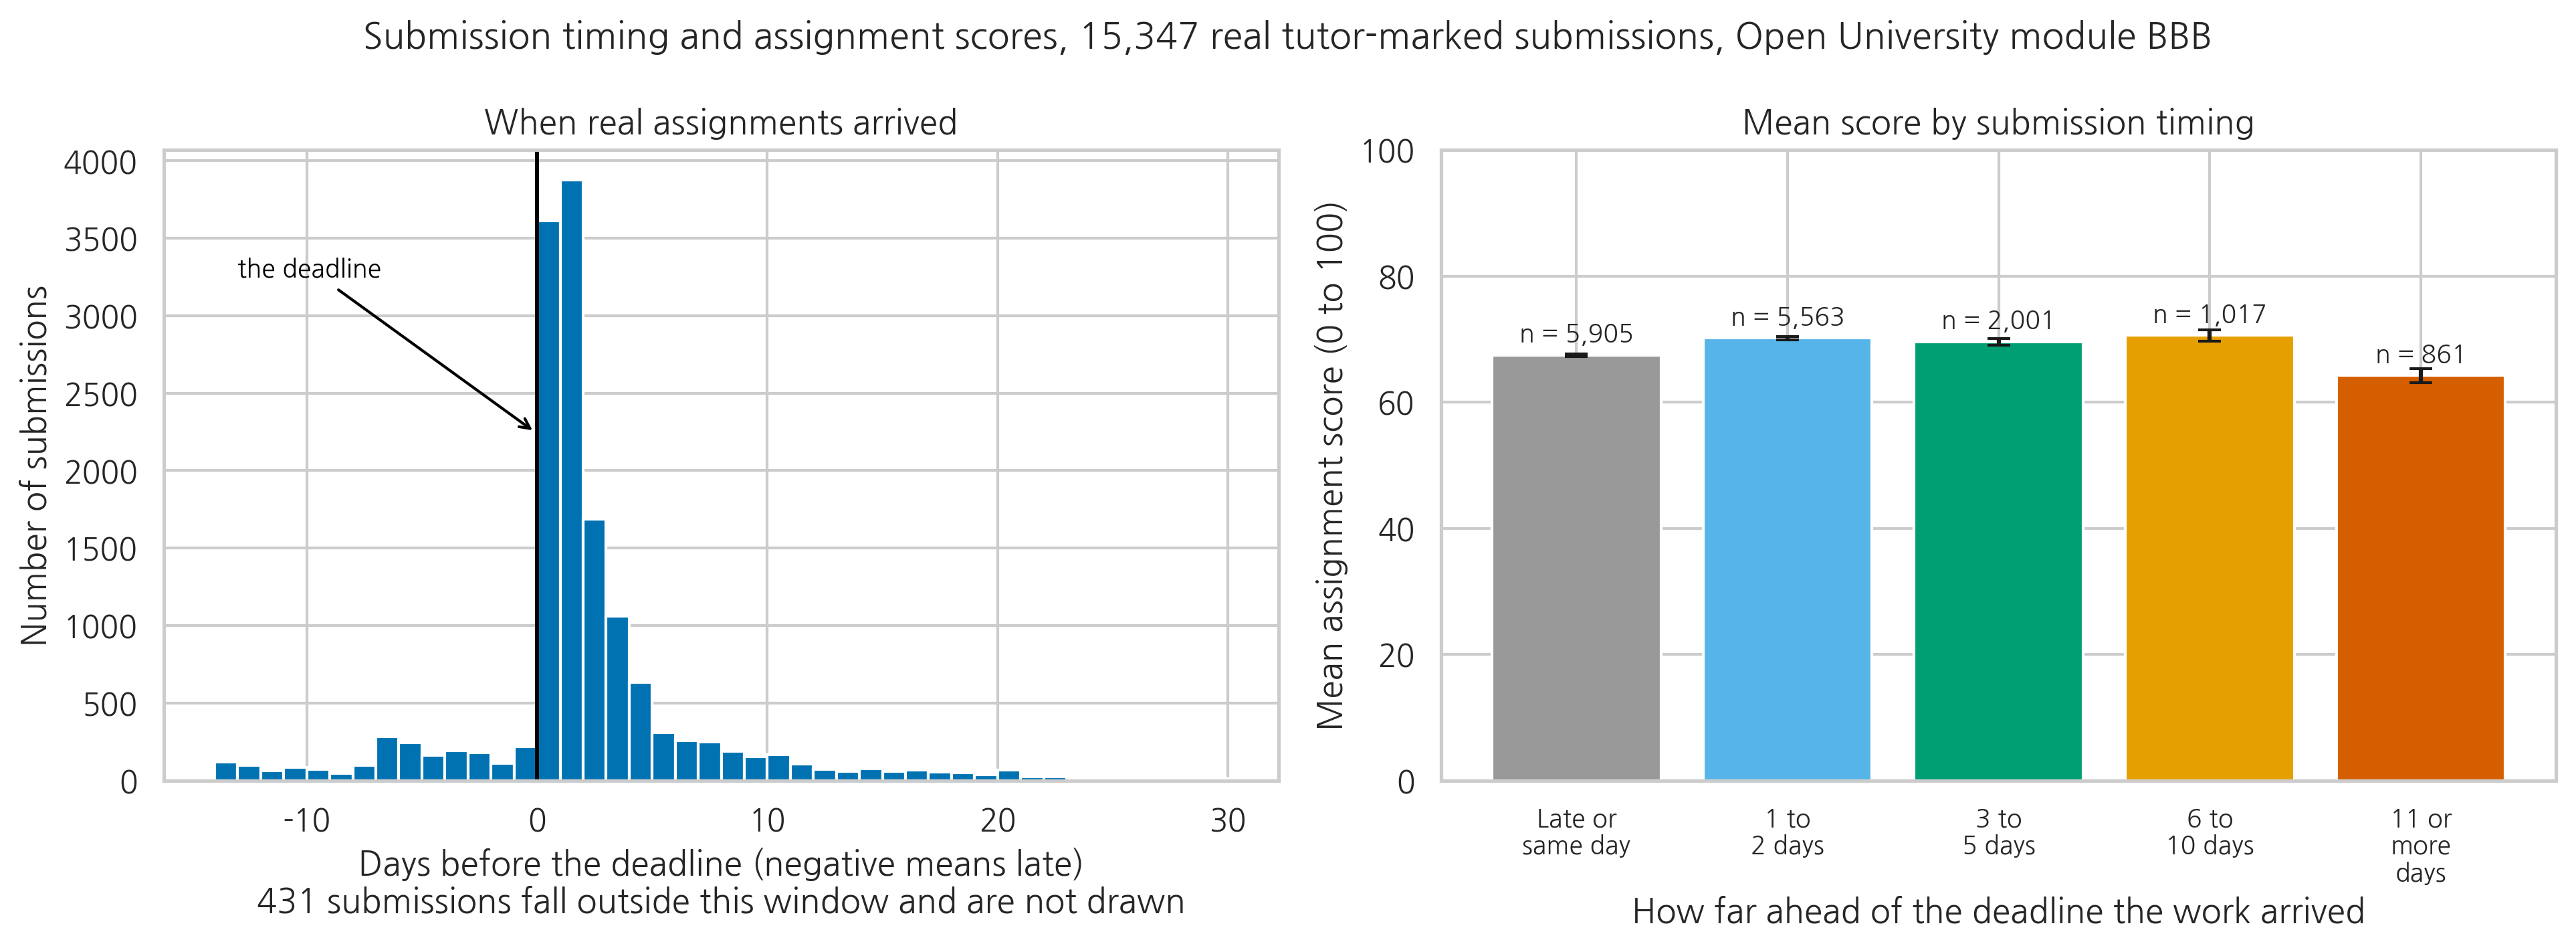

In [17]:
real_r = np.corrcoef(lead['days_early'], lead['score'])[0, 1]
very_early = lead.loc[lead['days_early'] >= 7, 'score']
on_or_late = lead.loc[lead['days_early'] <= 0, 'score']
real_d = cohens_d(very_early, on_or_late)

print('THE REAL MODULE (Open University BBB, 2013J and 2014J)')
print('  Submissions analysed                    :', f"{len(lead):,}")
print('  r (days early, score)                   :', round(real_r, 3))
print('  Submitted 7 or more days early          :', f"{len(very_early):,}", 'submissions, mean score',
      round(very_early.mean(), 2))
print('  Submitted on or after the deadline day  :', f"{len(on_or_late):,}", 'submissions, mean score',
      round(on_or_late.mean(), 2))
print("  Cohen's d between those two groups      :", round(real_d, 3))
print()

# Does the banked-score decision matter? Check rather than assume.
nb = lead[lead['is_banked'] == 0]
nb_r = np.corrcoef(nb['days_early'], nb['score'])[0, 1]
nb_d = cohens_d(nb.loc[nb['days_early'] >= 7, 'score'], nb.loc[nb['days_early'] <= 0, 'score'])
print('  Sensitivity check, dropping the', n_banked, 'banked scores:')
print('    n =', f"{len(nb):,}", '| r =', round(nb_r, 3), "| Cohen's d =", round(nb_d, 3))
print()

bands  = [-np.inf, 0, 2, 5, 10, np.inf]
labels = ['Late or same day', '1 to 2 days', '3 to 5 days', '6 to 10 days', '11 or more days']
tick_labels = [lab.replace(' or ', ' or\n').replace('to ', 'to\n').replace('more ', 'more\n')
               for lab in labels]
lead['band'] = pd.cut(lead['days_early'], bins=bands, labels=labels)
by_band = (lead.groupby('band', observed=False)
           .agg(submissions=('score', 'size'), mean_score=('score', 'mean'), sd=('score', 'std'))
           .round(2))
print('Mean score by how early the work arrived:')
print(by_band.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

hist_bins = np.arange(-14, 31, 1)
outside = int(((lead['days_early'] < -14) | (lead['days_early'] > 30)).sum())
axes[0].hist(lead['days_early'], bins=hist_bins, color=BLUE, edgecolor='white')
axes[0].axvline(0, color='black', linewidth=1.4)
axes[0].annotate('the deadline', xy=(0, axes[0].get_ylim()[1] * 0.55),
                 xytext=(-13, axes[0].get_ylim()[1] * 0.80), fontsize=9, color='black',
                 arrowprops=dict(arrowstyle='->', color='black', linewidth=1))
axes[0].set_title('When real assignments arrived')
axes[0].set_xlabel('Days before the deadline (negative means late)\n'
                   + str(outside) + ' submissions fall outside this window and are not drawn')
axes[0].set_ylabel('Number of submissions')

band_colors = [GRAY, SKY, GREEN, ORANGE, VERMILLION]
se = by_band['sd'] / np.sqrt(by_band['submissions'])
bars = axes[1].bar(range(len(by_band)), by_band['mean_score'], color=band_colors,
                   yerr=se, capsize=4, edgecolor='white')
for bar, n in zip(bars, by_band['submissions']):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2.2,
                 'n = ' + f"{int(n):,}", ha='center', fontsize=9)
axes[1].set_xticks(range(len(by_band)))
axes[1].set_xticklabels(tick_labels, fontsize=9)
axes[1].set_ylim(0, 100)
axes[1].set_title('Mean score by submission timing')
axes[1].set_xlabel('How far ahead of the deadline the work arrived')
axes[1].set_ylabel('Mean assignment score (0 to 100)')

fig.suptitle('Submission timing and assignment scores, ' + f"{len(lead):,}"
             + ' real tutor-marked submissions, Open University module BBB', fontsize=13)
fig.tight_layout()
plt.show()

**💬 Interpretation prompt.** Go back and read what you wrote in section 2.1. Then answer,
before reading further:

1. How far off was your prediction? Not "was I right", but by how much and in which direction.
2. Look at the bars, in order, left to right. The pattern is not a line. It goes up, down a little, up again,
   and then falls off a cliff at the far right. Describe that shape in one sentence to someone who cannot see
   it. Does any story you currently believe about procrastination predict that shape?
3. Look at the rightmost bar and its `n`. If you wanted to report "students who submit very early do worse",
   how many submissions would that sentence be resting on, out of how many, and how would you have to
   describe the width of the error bar?
4. The synthetic effect and the real effect were computed with the same function on the same day by the same
   person. What, then, is different?

## 2.4 The two worlds side by side

It is one thing to read that *d* fell from three quarters of a standard deviation to essentially zero. It is
another to see the two effects drawn on one axis.

The bars below are the same contrast in both datasets. To make the comparison fair, both are computed as
Cohen's *d* between work submitted early and work submitted on or after the deadline, at two definitions of
"early", because the synthetic course ran eight weeks and the real module ran many times longer than that, so
"a week early" does not mean the same thing in both.

         dataset            threshold  cohens_d  n_early  n_on_or_after
Synthetic course 3 or more days early     0.872      225             33
Synthetic course 7 or more days early     1.969       50             33
 Real module BBB 3 or more days early     0.056     3879           5905
 Real module BBB 7 or more days early    -0.028     1619           5905

Correlation between days early and score:
  Synthetic course : r = 0.418
  Real module BBB  : r = 0.01


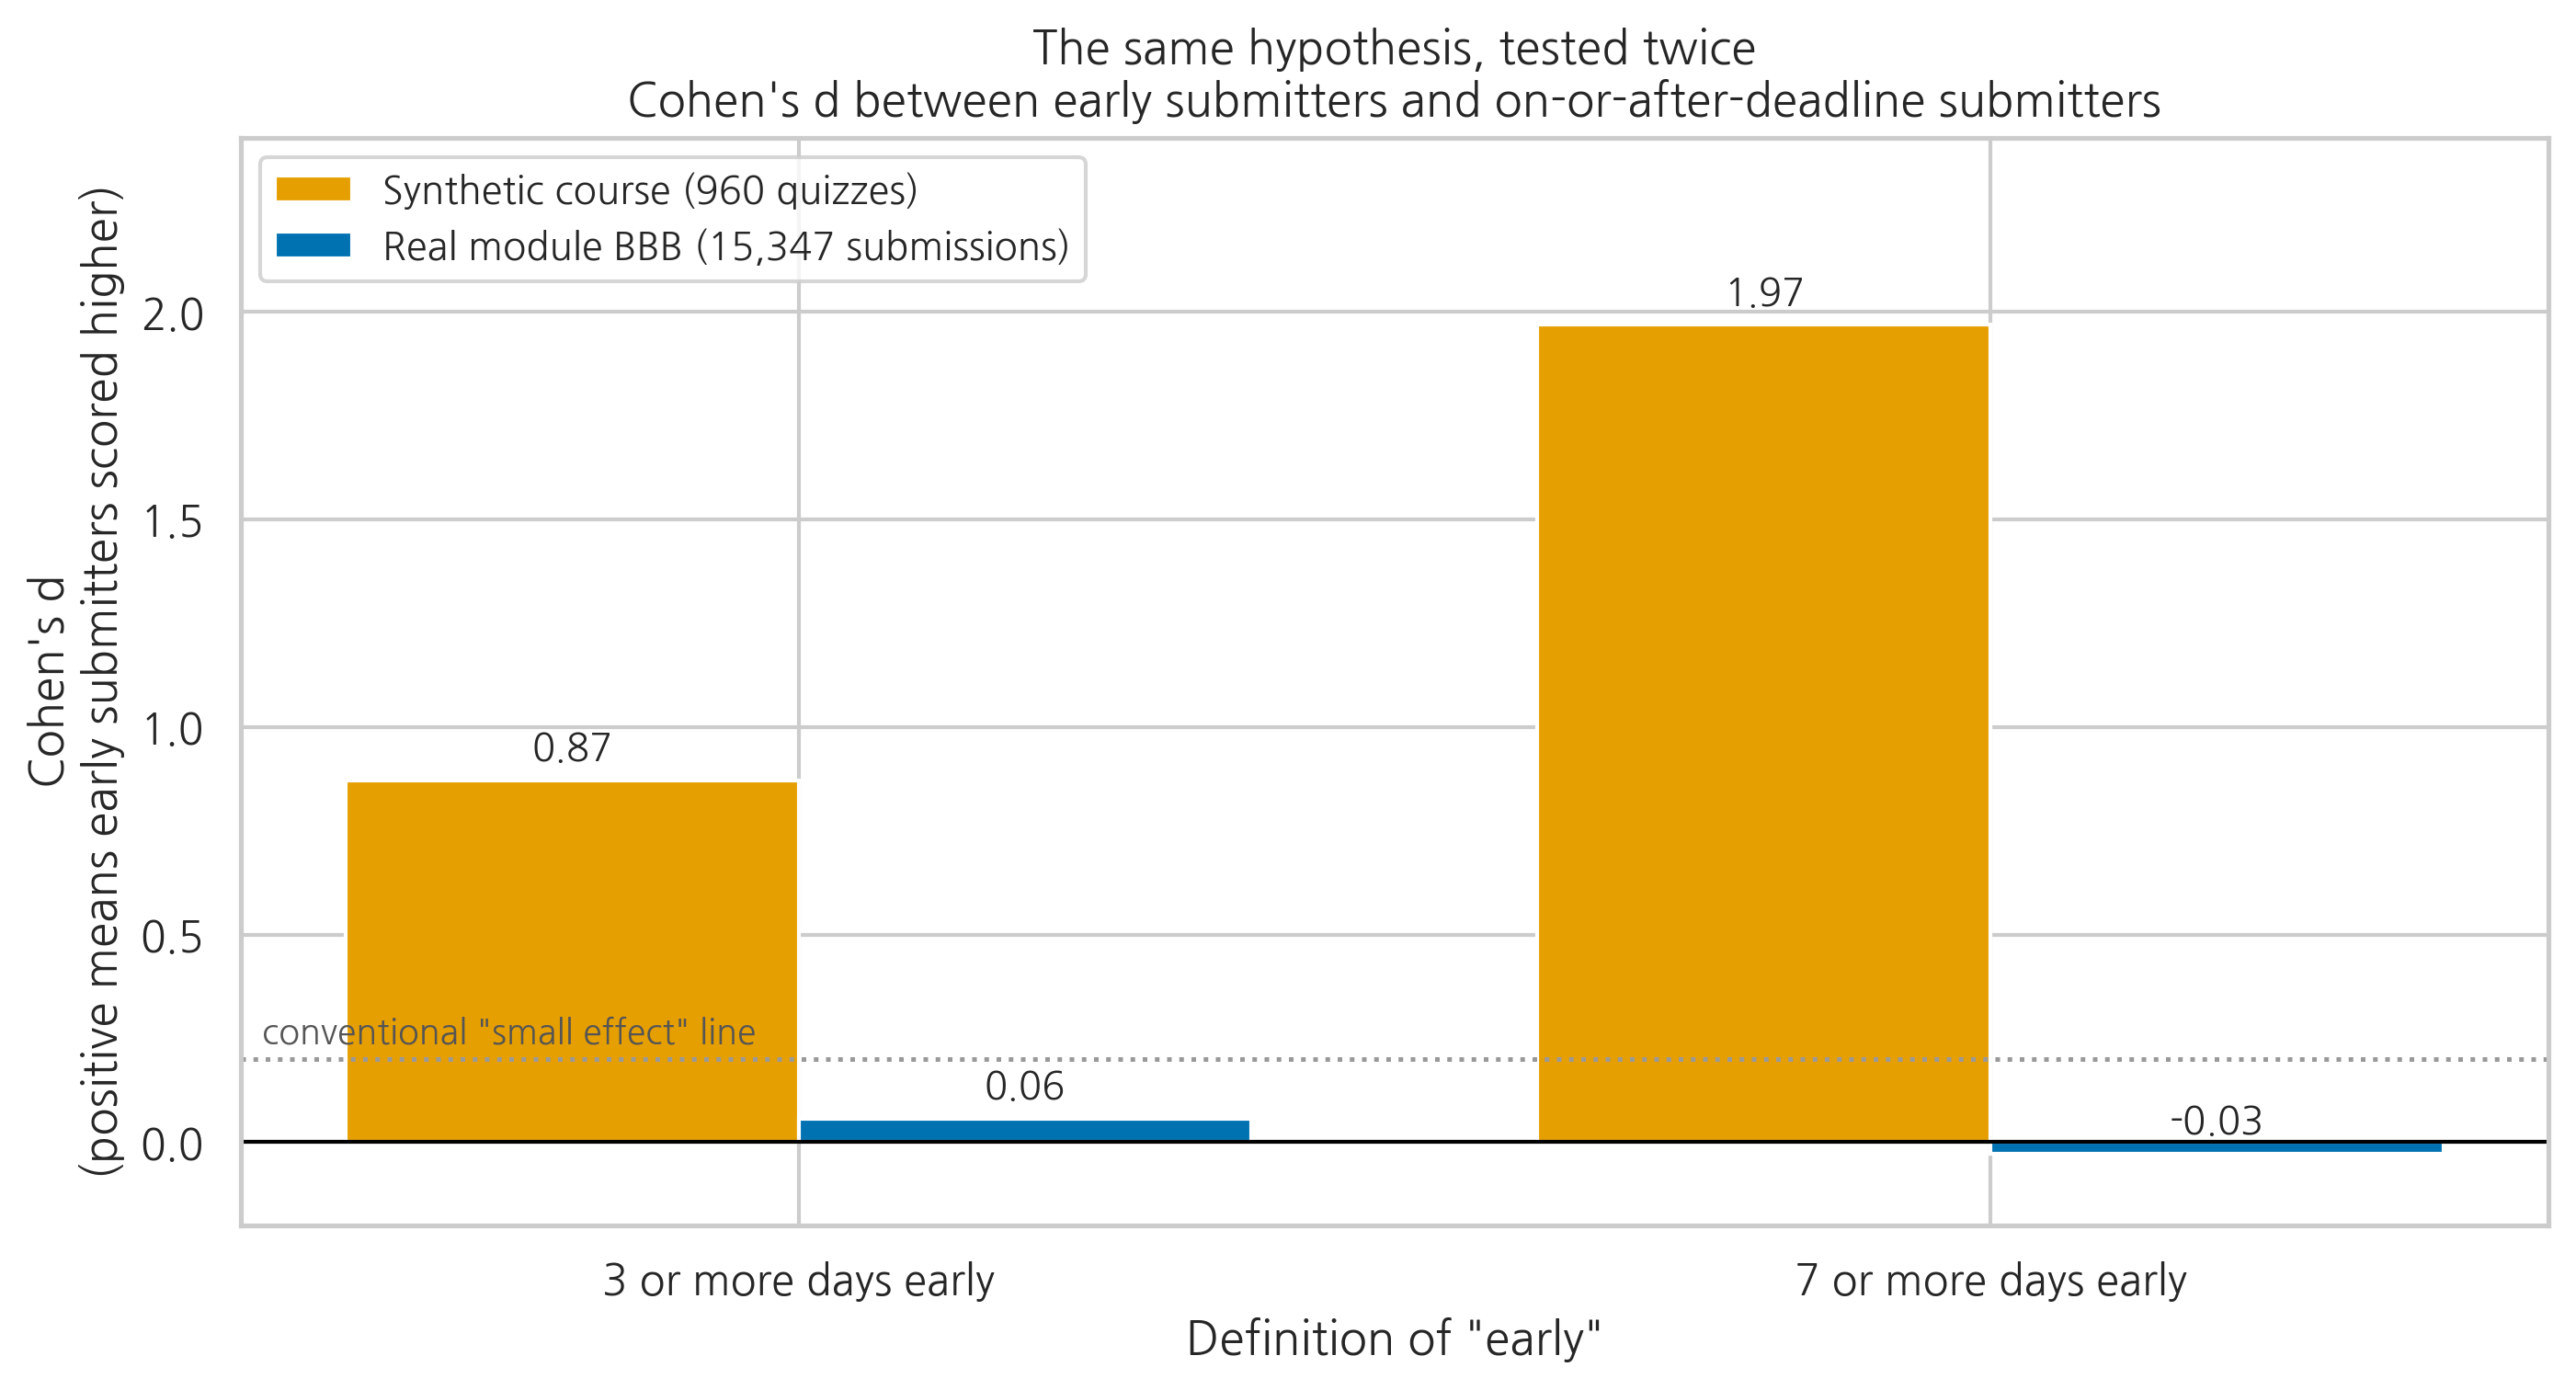

In [18]:
def contrast(df, days_col, score_col, threshold):
    """Cohen's d between 'at least `threshold` days early' and 'on or after the deadline'."""
    a = df.loc[df[days_col] >= threshold, score_col]
    b = df.loc[df[days_col] <= 0, score_col]
    return cohens_d(a, b), len(a), len(b)

rows = []
for label, df, col in [('Synthetic course', quizzes, 'days_early'), ('Real module BBB', lead, 'days_early')]:
    for thr in (3, 7):
        d, na, nb = contrast(df, col, 'score', thr)
        rows.append({'dataset': label, 'threshold': str(thr) + ' or more days early',
                     'cohens_d': round(d, 3), 'n_early': na, 'n_on_or_after': nb})
comparison = pd.DataFrame(rows)
print(comparison.to_string(index=False))
print()
print('Correlation between days early and score:')
print('  Synthetic course : r =', round(syn_r, 3))
print('  Real module BBB  : r =', round(real_r, 3))

fig, ax = plt.subplots(figsize=(9.5, 5.2))
x = np.arange(2)
syn_vals = comparison.loc[comparison['dataset'] == 'Synthetic course', 'cohens_d'].values
real_vals = comparison.loc[comparison['dataset'] == 'Real module BBB', 'cohens_d'].values
ax.bar(x - 0.19, syn_vals, width=0.38, color=ORANGE, edgecolor='white', label='Synthetic course (960 quizzes)')
ax.bar(x + 0.19, real_vals, width=0.38, color=BLUE, edgecolor='white',
       label='Real module BBB (' + f"{len(lead):,}" + ' submissions)')
top = max(syn_vals.max(), real_vals.max())
for xi, v in zip(x - 0.19, syn_vals):
    ax.text(xi, v + 0.05, str(round(v, 2)), ha='center', fontsize=10)
for xi, v in zip(x + 0.19, real_vals):
    ax.text(xi, v + 0.05, str(round(v, 2)), ha='center', fontsize=10)
ax.axhline(0, color='black', linewidth=1)
ax.axhline(0.2, color=GRAY, linestyle=':', linewidth=1.2)
ax.text(-0.45, 0.24, 'conventional "small effect" line', fontsize=9, color='#555555', ha='left')
ax.set_xticks(x)
ax.set_xticklabels(['3 or more days early', '7 or more days early'])
ax.set_ylim(-0.2, top + 0.45)
ax.set_title('The same hypothesis, tested twice\n'
             "Cohen's d between early submitters and on-or-after-deadline submitters")
ax.set_xlabel('Definition of "early"')
ax.set_ylabel("Cohen's d\n(positive means early submitters scored higher)")
ax.legend(fontsize=10, loc='upper left')
fig.tight_layout()
plt.show()

**💬 Interpretation prompt.** One sentence each.

1. The synthetic bars and the real bars are the same analysis. Which of the two is telling you something
   about how people learn, and which is telling you something about how a data generator was written?
2. Suppose you had done six weeks of coursework on the real data first and then met the synthetic data. What
   would you have concluded about the synthetic course?
3. This is the uncomfortable one. Every method you have practised this term was practised on data built to
   contain the answer. Name one thing you now think you know about learning that you might only know about
   `generate_all_data.py`.

## 2.5 Maybe the unit is wrong: from submissions to students

There is a reasonable objection to everything above. Pooling 15,347 submissions means a student who submits
six times counts six times, and it mixes together two different questions: whether *a given piece of work*
does better when it arrives early, and whether *a person who tends to work early* does better overall.

The second question is the one most people actually mean by "procrastination". So compute it that way: one
dot per enrolment, average lead time on one axis, average score on the other.

Enrolments with at least one tutor-marked submission : 3,496
  r (mean days early, mean score)                    : 0.025
Enrolments with at least four submissions            : 2,603
  r (mean days early, mean score)                    : 0.031

For comparison, the same correlation in the synthetic course was r = 0.418.
Enrolments falling outside the -20 to 40 day window of the figure : 49


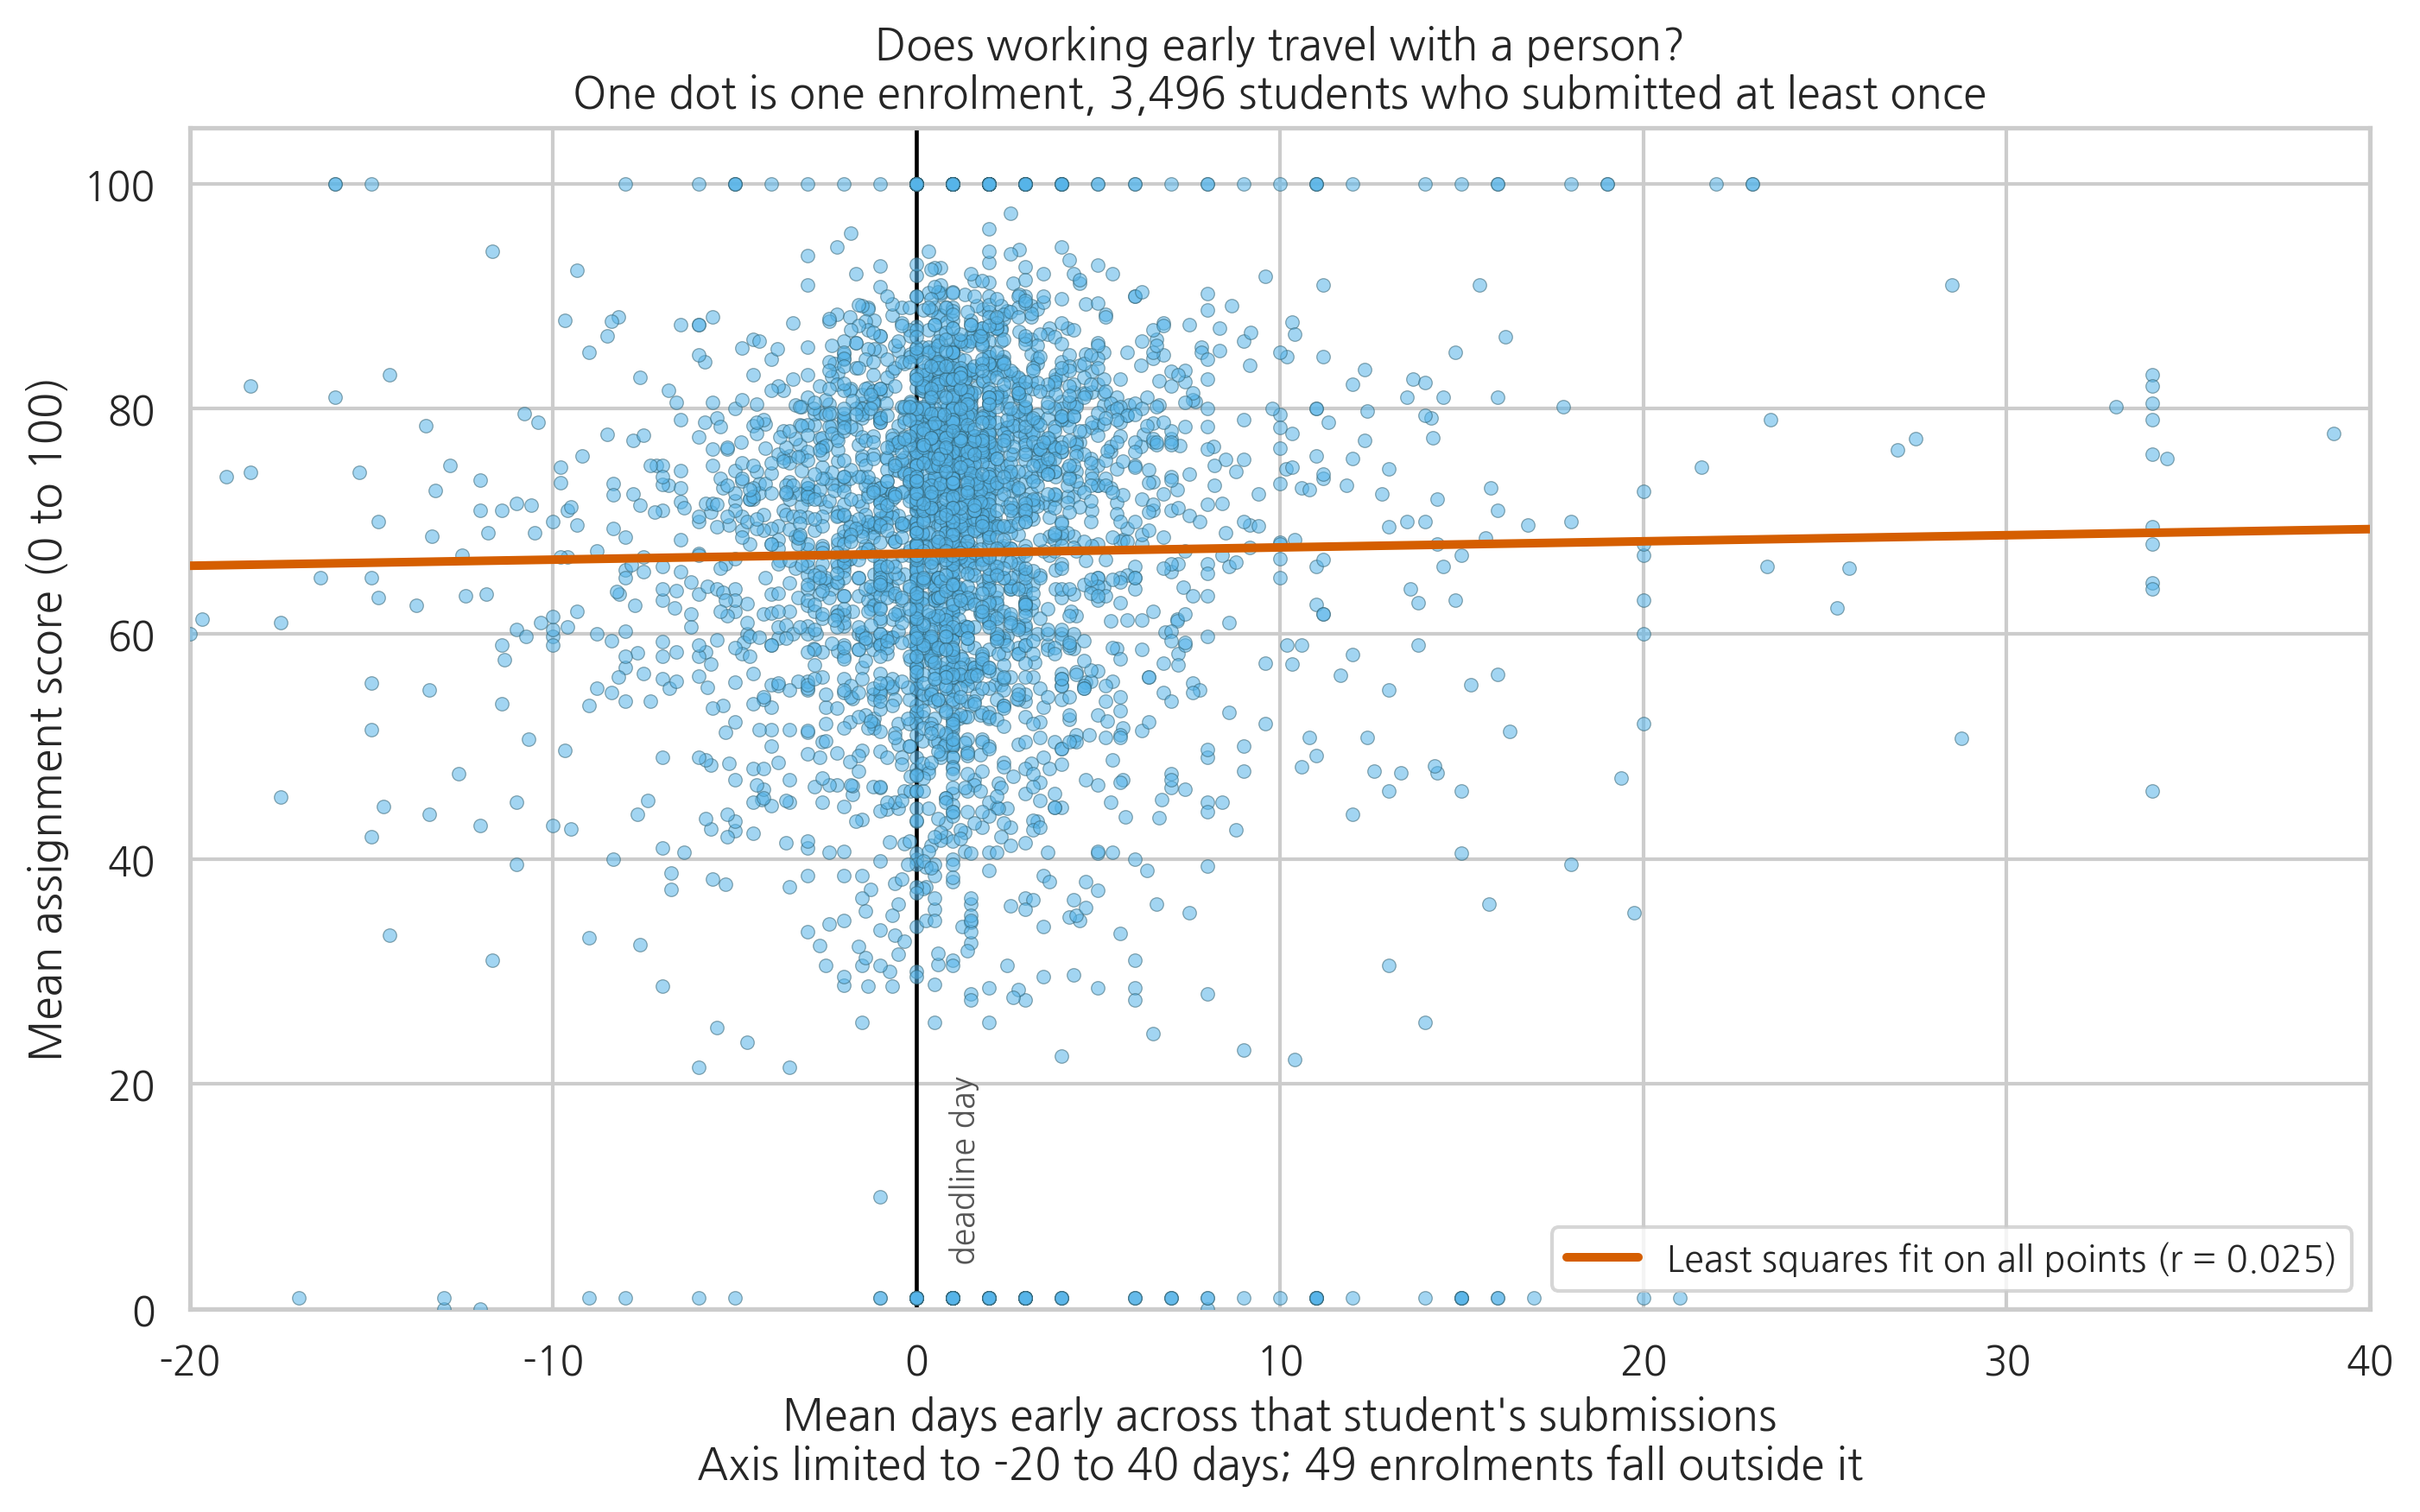

In [19]:
KEY = ['code_module', 'code_presentation', 'id_student']

per_student = (lead.groupby(KEY)
               .agg(mean_score=('score', 'mean'),
                    mean_days_early=('days_early', 'mean'),
                    n_submissions=('score', 'size'))
               .reset_index())

r_person = np.corrcoef(per_student['mean_days_early'], per_student['mean_score'])[0, 1]
solid = per_student[per_student['n_submissions'] >= 4]
r_solid = np.corrcoef(solid['mean_days_early'], solid['mean_score'])[0, 1]

print('Enrolments with at least one tutor-marked submission :', f"{len(per_student):,}")
print('  r (mean days early, mean score)                    :', round(r_person, 3))
print('Enrolments with at least four submissions            :', f"{len(solid):,}")
print('  r (mean days early, mean score)                    :', round(r_solid, 3))
print()
print('For comparison, the same correlation in the synthetic course was r = '
      + str(round(syn_r, 3)) + '.')

slope, intercept = np.polyfit(per_student['mean_days_early'], per_student['mean_score'], 1)
xs = np.linspace(-20, 40, 50)
off_axis = int(((per_student['mean_days_early'] < -20)
                | (per_student['mean_days_early'] > 40)).sum())
print('Enrolments falling outside the -20 to 40 day window of the figure :', off_axis)

fig, ax = plt.subplots(figsize=(9.5, 6))
ax.scatter(per_student['mean_days_early'], per_student['mean_score'], s=14, color=SKY,
           edgecolor='#31606f', linewidth=0.3, alpha=0.55, zorder=3)
ax.plot(xs, intercept + slope * xs, color=VERMILLION, linewidth=2.4, zorder=4,
        label='Least squares fit on all points (r = ' + str(round(r_person, 3)) + ')')
ax.axvline(0, color='black', linewidth=1.1, zorder=2)
ax.text(0.9, 4, 'deadline day', fontsize=9, rotation=90, va='bottom', color='#555555')
ax.set_xlim(-20, 40)
ax.set_ylim(0, 105)
ax.set_title('Does working early travel with a person?\n'
             'One dot is one enrolment, ' + f"{len(per_student):,}" + ' students who submitted at least once')
ax.set_xlabel('Mean days early across that student\'s submissions\n'
              'Axis limited to -20 to 40 days; ' + str(off_axis) + ' enrolments fall outside it')
ax.set_ylabel('Mean assignment score (0 to 100)')
ax.legend(fontsize=10, loc='lower right')
fig.tight_layout()
plt.show()

**💬 Interpretation prompt.** The dots form a cloud, and the fitted line is nearly flat.

1. Find the vertical strip of dots directly above "deadline day". Those are students whose work arrived, on
   average, right at the deadline. How wide is the range of scores in that strip? What does that width alone
   tell you about how much of a student's outcome this axis could possibly explain?
2. Changing the unit of analysis from submissions to people did not rescue the effect. Name a third unit you
   could have chosen, and say what question it would answer that neither of these two does.
3. A dashboard vendor offers your institution a "procrastination risk" indicator built on exactly this axis.
   Using this figure, write the one sentence you would say in that meeting.

## 2.6 Who is not in the file

Here is the most important thing in this notebook, and it is not visible in any chart above.

To appear in the submission file at all, a student has to have submitted something. Everyone who registered,
struggled, and never handed anything in is simply absent. This is **range restriction**: the correlation you
just computed was computed on the survivors, and the people whose story would most obviously support
"disorganised timing goes with poor outcomes" are the people who are not in the calculation.

Enrolments in module BBB                     :

 4,529
  Submitted at least one tutor-marked task   : 3,496
  Never submitted anything, so never in any
  of the analyses above                      : 1,033

Where the missing students went:
              submitted at least once  never submitted
final_result                                          
Distinction                       356                0
Fail                              765              147
Pass                             1866                2
Withdrawn                         509              884

Enrolments with not one single recorded click: 738
final_result
Withdrawn    664
Fail          72
Pass           2


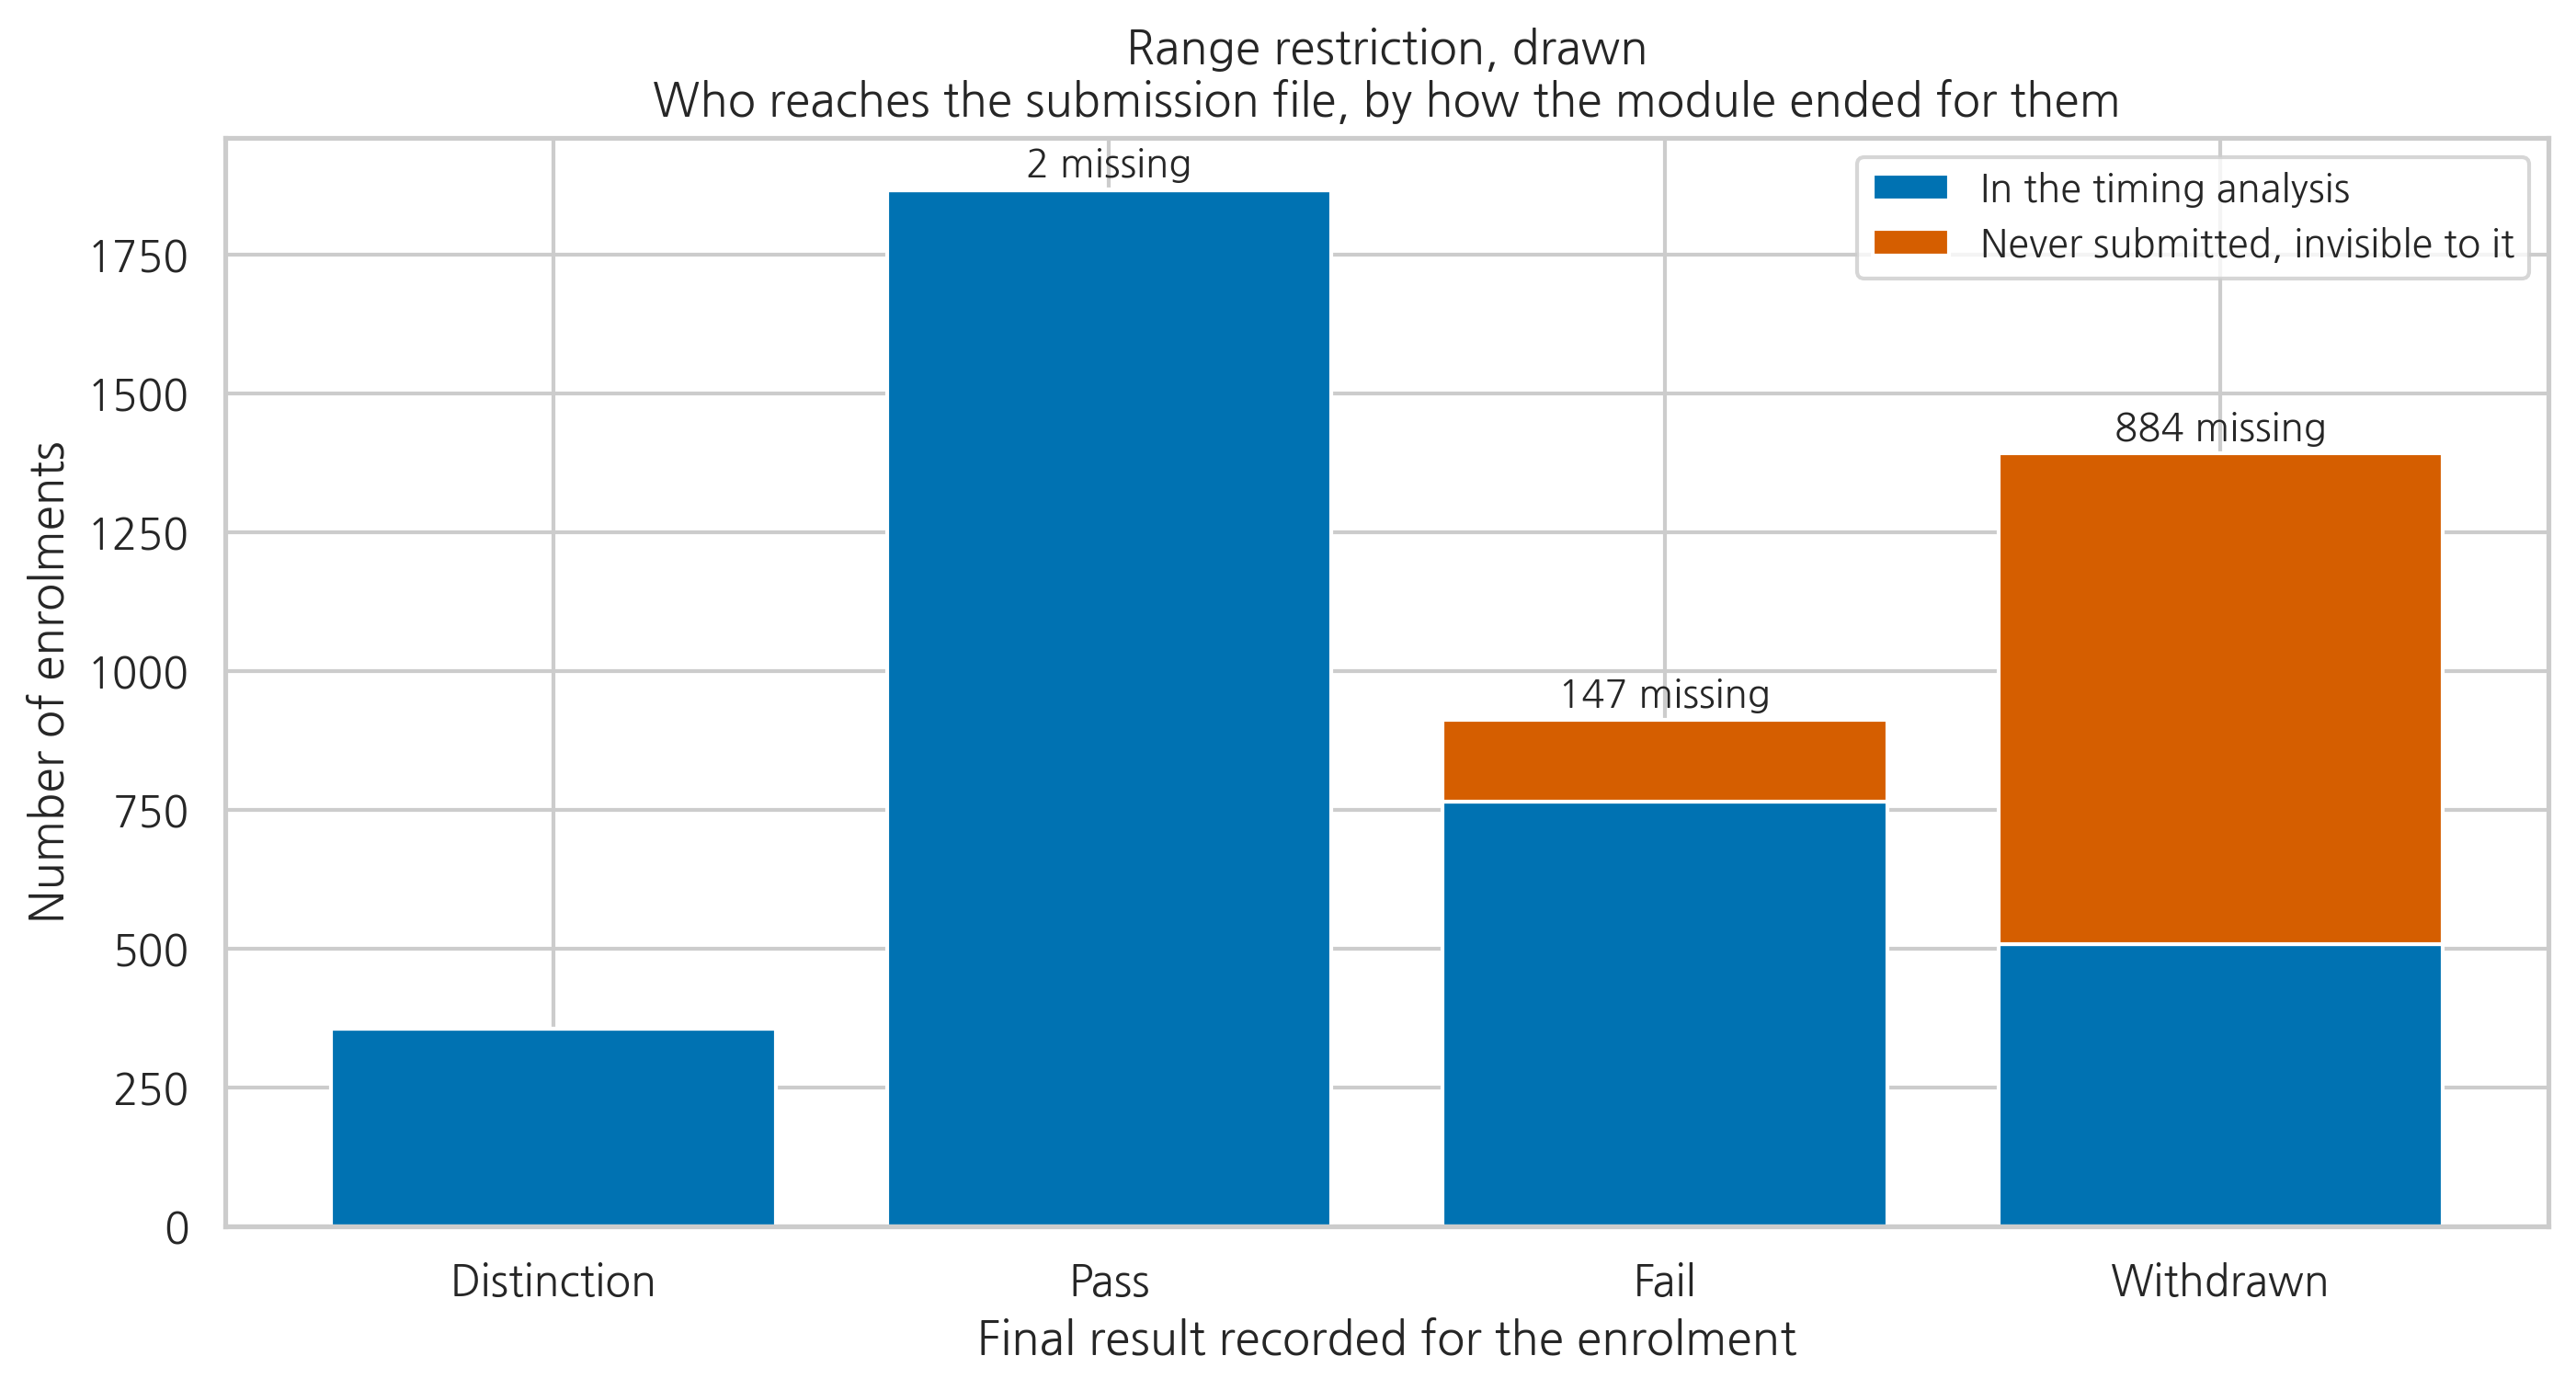

In [20]:
enrolled = student_info.merge(per_student[KEY + ['n_submissions']], on=KEY, how='left')
enrolled['n_submissions'] = enrolled['n_submissions'].fillna(0)
enrolled['submitted_any'] = enrolled['n_submissions'] > 0

print('Enrolments in module BBB                     :', f"{len(enrolled):,}")
print('  Submitted at least one tutor-marked task   :', f"{int(enrolled['submitted_any'].sum()):,}")
print('  Never submitted anything, so never in any')
print('  of the analyses above                      :', f"{int((~enrolled['submitted_any']).sum()):,}")
print()

ct = pd.crosstab(enrolled['final_result'], enrolled['submitted_any'])
ct.columns = ['never submitted', 'submitted at least once']
ct = ct[['submitted at least once', 'never submitted']]
print('Where the missing students went:')
print(ct.to_string())
print()

# Same question for the click data.
activity = (student_vle.groupby(KEY)
            .agg(total_clicks=('sum_click', 'sum'), active_days=('date', 'nunique'))
            .reset_index())
enrolled = enrolled.merge(activity, on=KEY, how='left')
n_no_clicks = int(enrolled['total_clicks'].isna().sum())
print('Enrolments with not one single recorded click:', n_no_clicks)
print(enrolled[enrolled['total_clicks'].isna()]['final_result'].value_counts().to_string())

order = ['Distinction', 'Pass', 'Fail', 'Withdrawn']
ct = ct.reindex(order)
fig, ax = plt.subplots(figsize=(9.5, 5.2))
ax.bar(order, ct['submitted at least once'], color=BLUE, edgecolor='white',
       label='In the timing analysis')
ax.bar(order, ct['never submitted'], bottom=ct['submitted at least once'],
       color=VERMILLION, edgecolor='white', label='Never submitted, invisible to it')
for i, cat in enumerate(order):
    miss = int(ct.loc[cat, 'never submitted'])
    if miss > 0:
        ax.text(i, ct.loc[cat].sum() + 25, str(miss) + ' missing', ha='center', fontsize=10)
ax.set_title('Range restriction, drawn\n'
             'Who reaches the submission file, by how the module ended for them')
ax.set_xlabel('Final result recorded for the enrolment')
ax.set_ylabel('Number of enrolments')
ax.legend(fontsize=10)
fig.tight_layout()
plt.show()

**💬 Interpretation prompt.** Look at the vermillion segments.

1. Almost all of the missing students withdrew. If disorganised work habits do lead to bad outcomes, where
   would you expect those students to be in the timing distribution, and what does their absence do to a
   correlation computed without them?
2. Two students who never submitted a tutor-marked assignment nevertheless passed the module. Before you
   decide that is an error in the data, propose two ordinary institutional explanations.
3. Write the sentence that has to appear in the limitations paragraph of any paper using this file. Then say
   why that sentence almost never appears in the marketing copy for a learning analytics product.

## 2.7 The rhythm is real even when the effect is not

It would be easy to conclude that this data is simply inert, that real data is noise and nothing is in it.
That is the wrong lesson, and this section is here to prevent it.

Below is one presentation of the module (2013J, starting in October 2013) as a heartbeat: total clicks per
day across all students, with a seven-day rolling mean over the top, and the six tutor-marked deadlines
marked. A rolling mean smooths each day together with the six before it, so that a weekly rhythm becomes a
level rather than a sawtooth.

The cell also prints, for each deadline, the busiest day in the five days leading up to it. That is worth a
line of code rather than a glance at the chart, because "activity surges at the deadline" and "activity
surges two days before the deadline and has fallen by the time the deadline arrives" are different claims
about how people work, and only one of them is true here.

Day 0 is the first day of teaching. Negative days are before it, which is a real thing this data records and
most exports throw away.

Presentation                : 2013J
Students with click records : 1,870
Total clicks                : 1,378,656
Days covered                : 292 days, from day -23 to day 268
Busiest single day          : day 2 with 19,872 clicks
Tutor-marked deadlines fall on days: [19, 47, 96, 131, 166, 208]

Mean clicks per day, first 30 days of teaching : 9254.2
Mean clicks per day, days 180 to 209           : 3659.9

Every deadline has a surge beside it. None of them peaks on the deadline itself:
 deadline_day  busiest_day_in_the_5_before  days_ahead_of_the_deadline  clicks_on_that_busiest_day  clicks_on_the_deadline_day
           19                           17                           2                       12887                        8145
           47                           45                           2                       12086                        9226
           96                           95                           1                       11081                        9834
 

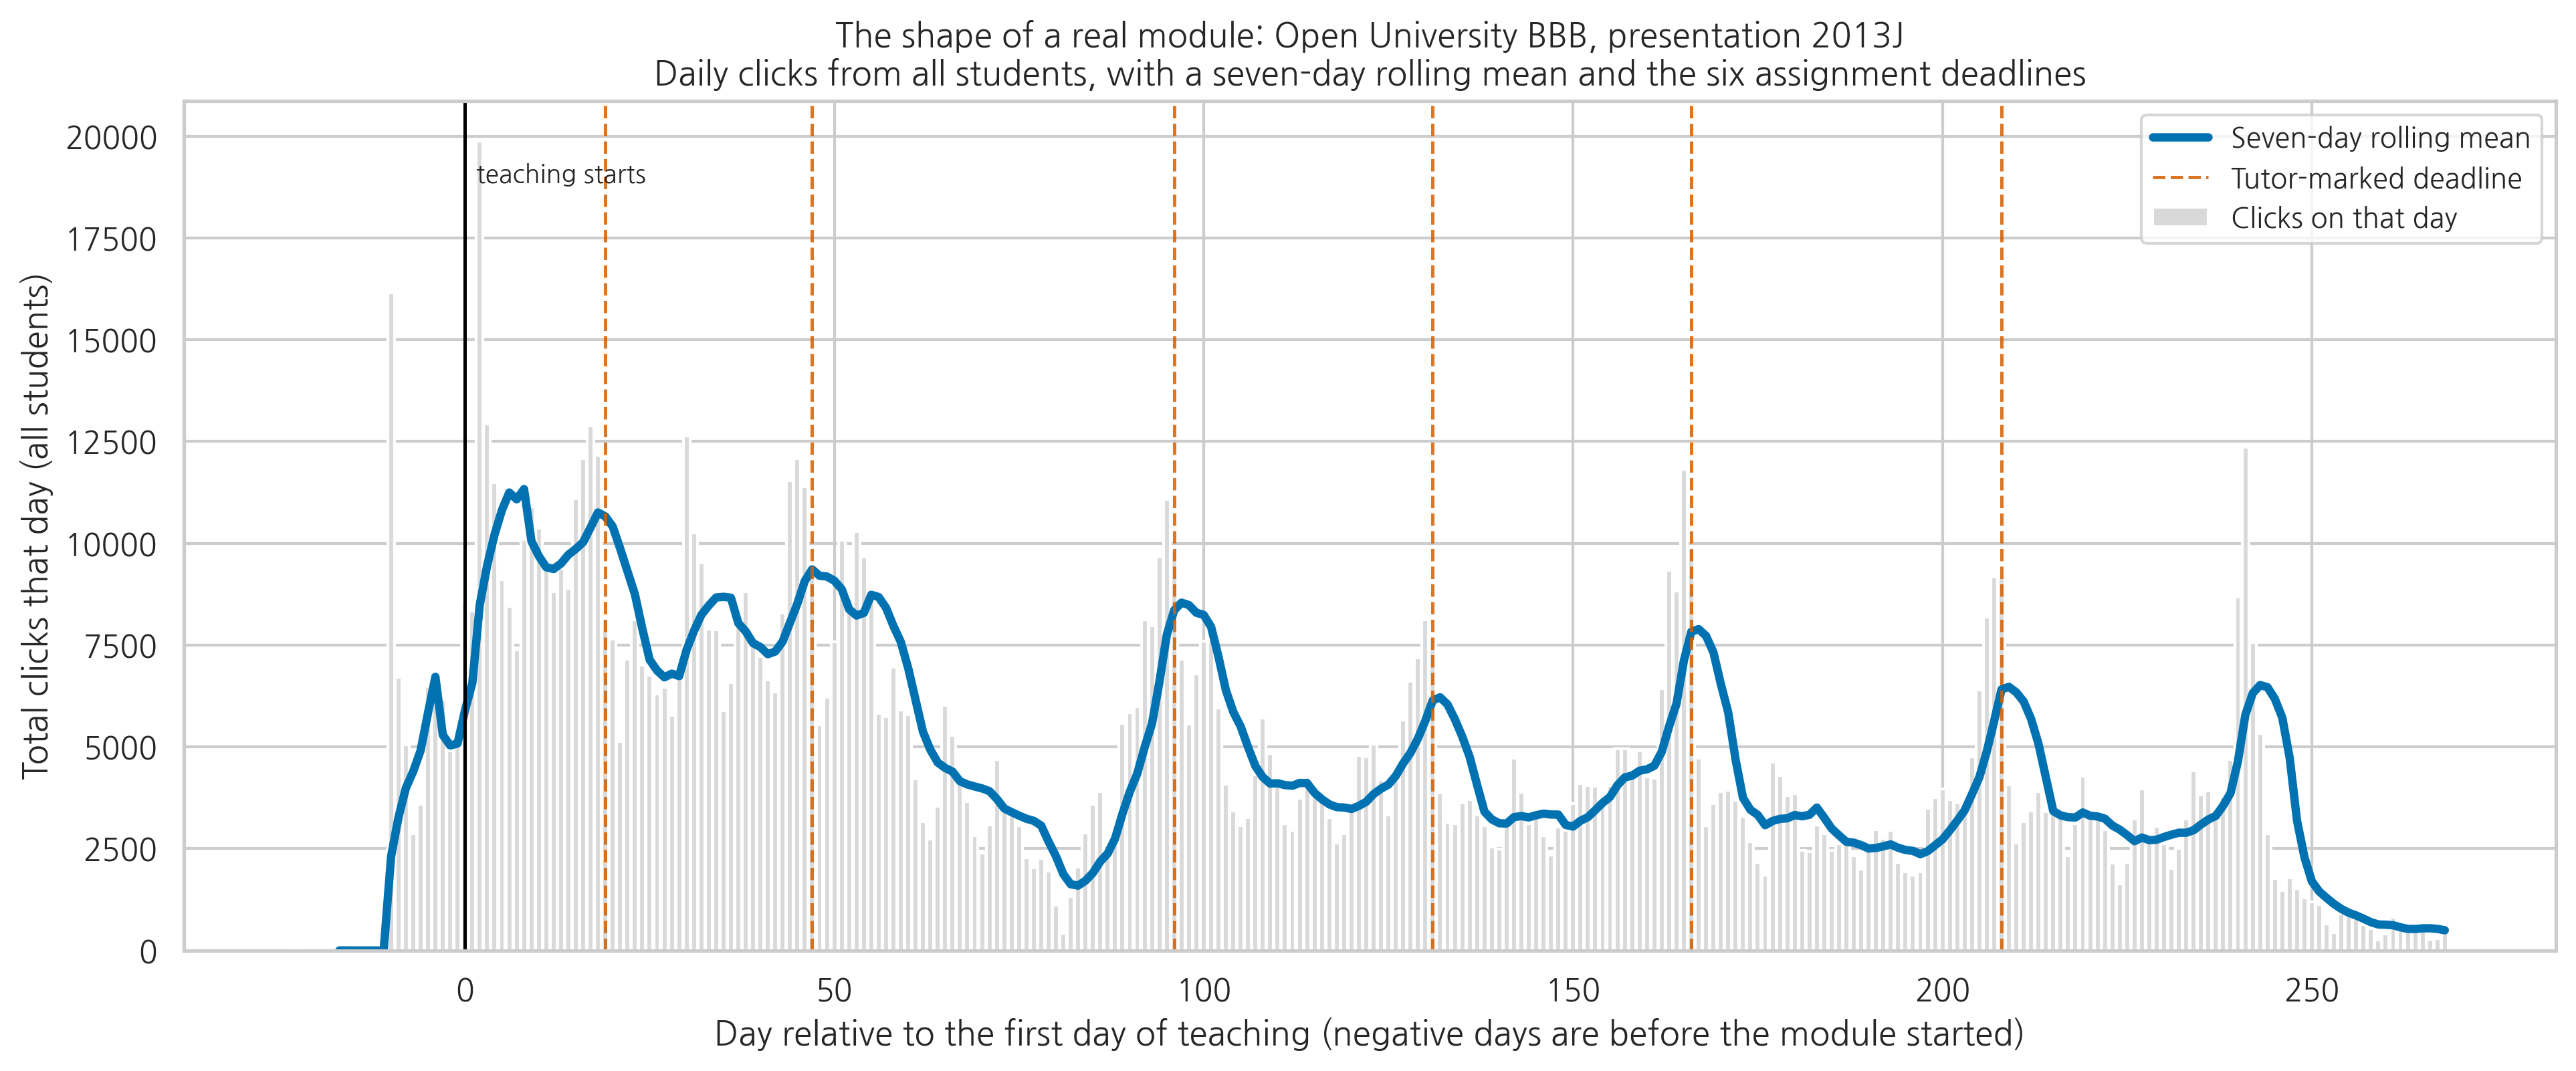

In [21]:
PRESENTATION = '2013J'

pres_clicks = student_vle[student_vle['code_presentation'] == PRESENTATION]
daily = pres_clicks.groupby('date')['sum_click'].sum()
daily = daily.reindex(range(int(daily.index.min()), int(daily.index.max()) + 1), fill_value=0)
rolling7 = daily.rolling(7, min_periods=7).mean()

deadlines = sorted(assessments.loc[(assessments['code_presentation'] == PRESENTATION)
                                   & (assessments['assessment_type'] == 'TMA'), 'date']
                   .dropna().astype(int).tolist())

print('Presentation                :', PRESENTATION)
print('Students with click records :', f"{pres_clicks['id_student'].nunique():,}")
print('Total clicks                :', f"{int(daily.sum()):,}")
print('Days covered                :', len(daily), 'days, from day', int(daily.index.min()),
      'to day', int(daily.index.max()))
print('Busiest single day          : day', int(daily.idxmax()), 'with',
      f"{int(daily.max()):,}", 'clicks')
print('Tutor-marked deadlines fall on days:', deadlines)
print()
print('Mean clicks per day, first 30 days of teaching :', round(daily.loc[0:29].mean(), 1))
print('Mean clicks per day, days 180 to 209           :', round(daily.loc[180:209].mean(), 1))
print()

# Where does the surge around each deadline actually peak? Check, rather than eyeball the chart.
peaks = pd.DataFrame([{'deadline_day': d,
                       'busiest_day_in_the_5_before': int(daily.loc[d - 5:d].idxmax()),
                       'days_ahead_of_the_deadline': int(d - daily.loc[d - 5:d].idxmax()),
                       'clicks_on_that_busiest_day': int(daily.loc[d - 5:d].max()),
                       'clicks_on_the_deadline_day': int(daily.loc[d])}
                      for d in deadlines])
print('Every deadline has a surge beside it. None of them peaks on the deadline itself:')
print(peaks.to_string(index=False))

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.bar(daily.index, daily.values, width=0.9, color='#d9d9d9', label='Clicks on that day')
ax.plot(rolling7.index, rolling7.values, color=BLUE, linewidth=3, label='Seven-day rolling mean')
for i, d in enumerate(deadlines):
    ax.axvline(d, color=VERMILLION, linestyle='--', linewidth=1.2, alpha=0.85,
               label='Tutor-marked deadline' if i == 0 else None)
ax.axvline(0, color='black', linewidth=1.2)
ax.text(1.5, daily.max() * 0.95, 'teaching starts', fontsize=9)
ax.set_title('The shape of a real module: Open University BBB, presentation ' + PRESENTATION + '\n'
             'Daily clicks from all students, with a seven-day rolling mean and the six assignment deadlines')
ax.set_xlabel('Day relative to the first day of teaching (negative days are before the module started)')
ax.set_ylabel('Total clicks that day (all students)')
ax.legend(fontsize=10)
fig.tight_layout()
plt.show()

**💬 Interpretation prompt.** Three things, and the third is the one worth arguing about.

1. The line falls a long way from the start of teaching to the end. Name two explanations that have nothing
   to do with students caring less. (One of them is sitting in the chart you drew in section 2.6.)
2. There is real activity before day 0. What are people doing in a course that has not started, and what does
   it mean that most institutional dashboards begin their clock at the first day of teaching?
3. Here is the tension of the whole week. This data clearly has temporal structure: rhythm, deadlines,
   decline, a start before the start. It just does not have *the* temporal structure you went looking for.
   What does that tell you about the difference between "there is a pattern in the data" and "the pattern I
   hypothesised is in the data"?

## 2.8 Two students, one number, two terms

One last look, at the level of two people who actually existed.

The two students below clicked almost exactly the same number of times all term: 1,166 and 1,160. A dashboard
reporting total activity would have shown them as the same student twice. They did not have the same term,
and, importantly for the argument of this notebook, they did not have the outcome the intuition predicts.

 id_student  total_clicks  active_days  busiest_day_clicks  submissions  mean_days_early  mean_score final_result age_band  studied_credits
     574973          1166          198                  38            6             7.00        77.3         Pass     0-35              180
     614556          1160           58                 183            6            -0.33        78.8         Pass     0-35              120

Student 614556 handed in 5 of 6 assignments on the deadline day itself and
1 of them after it, by 2 days, and still finished with the
higher mean score of the two.


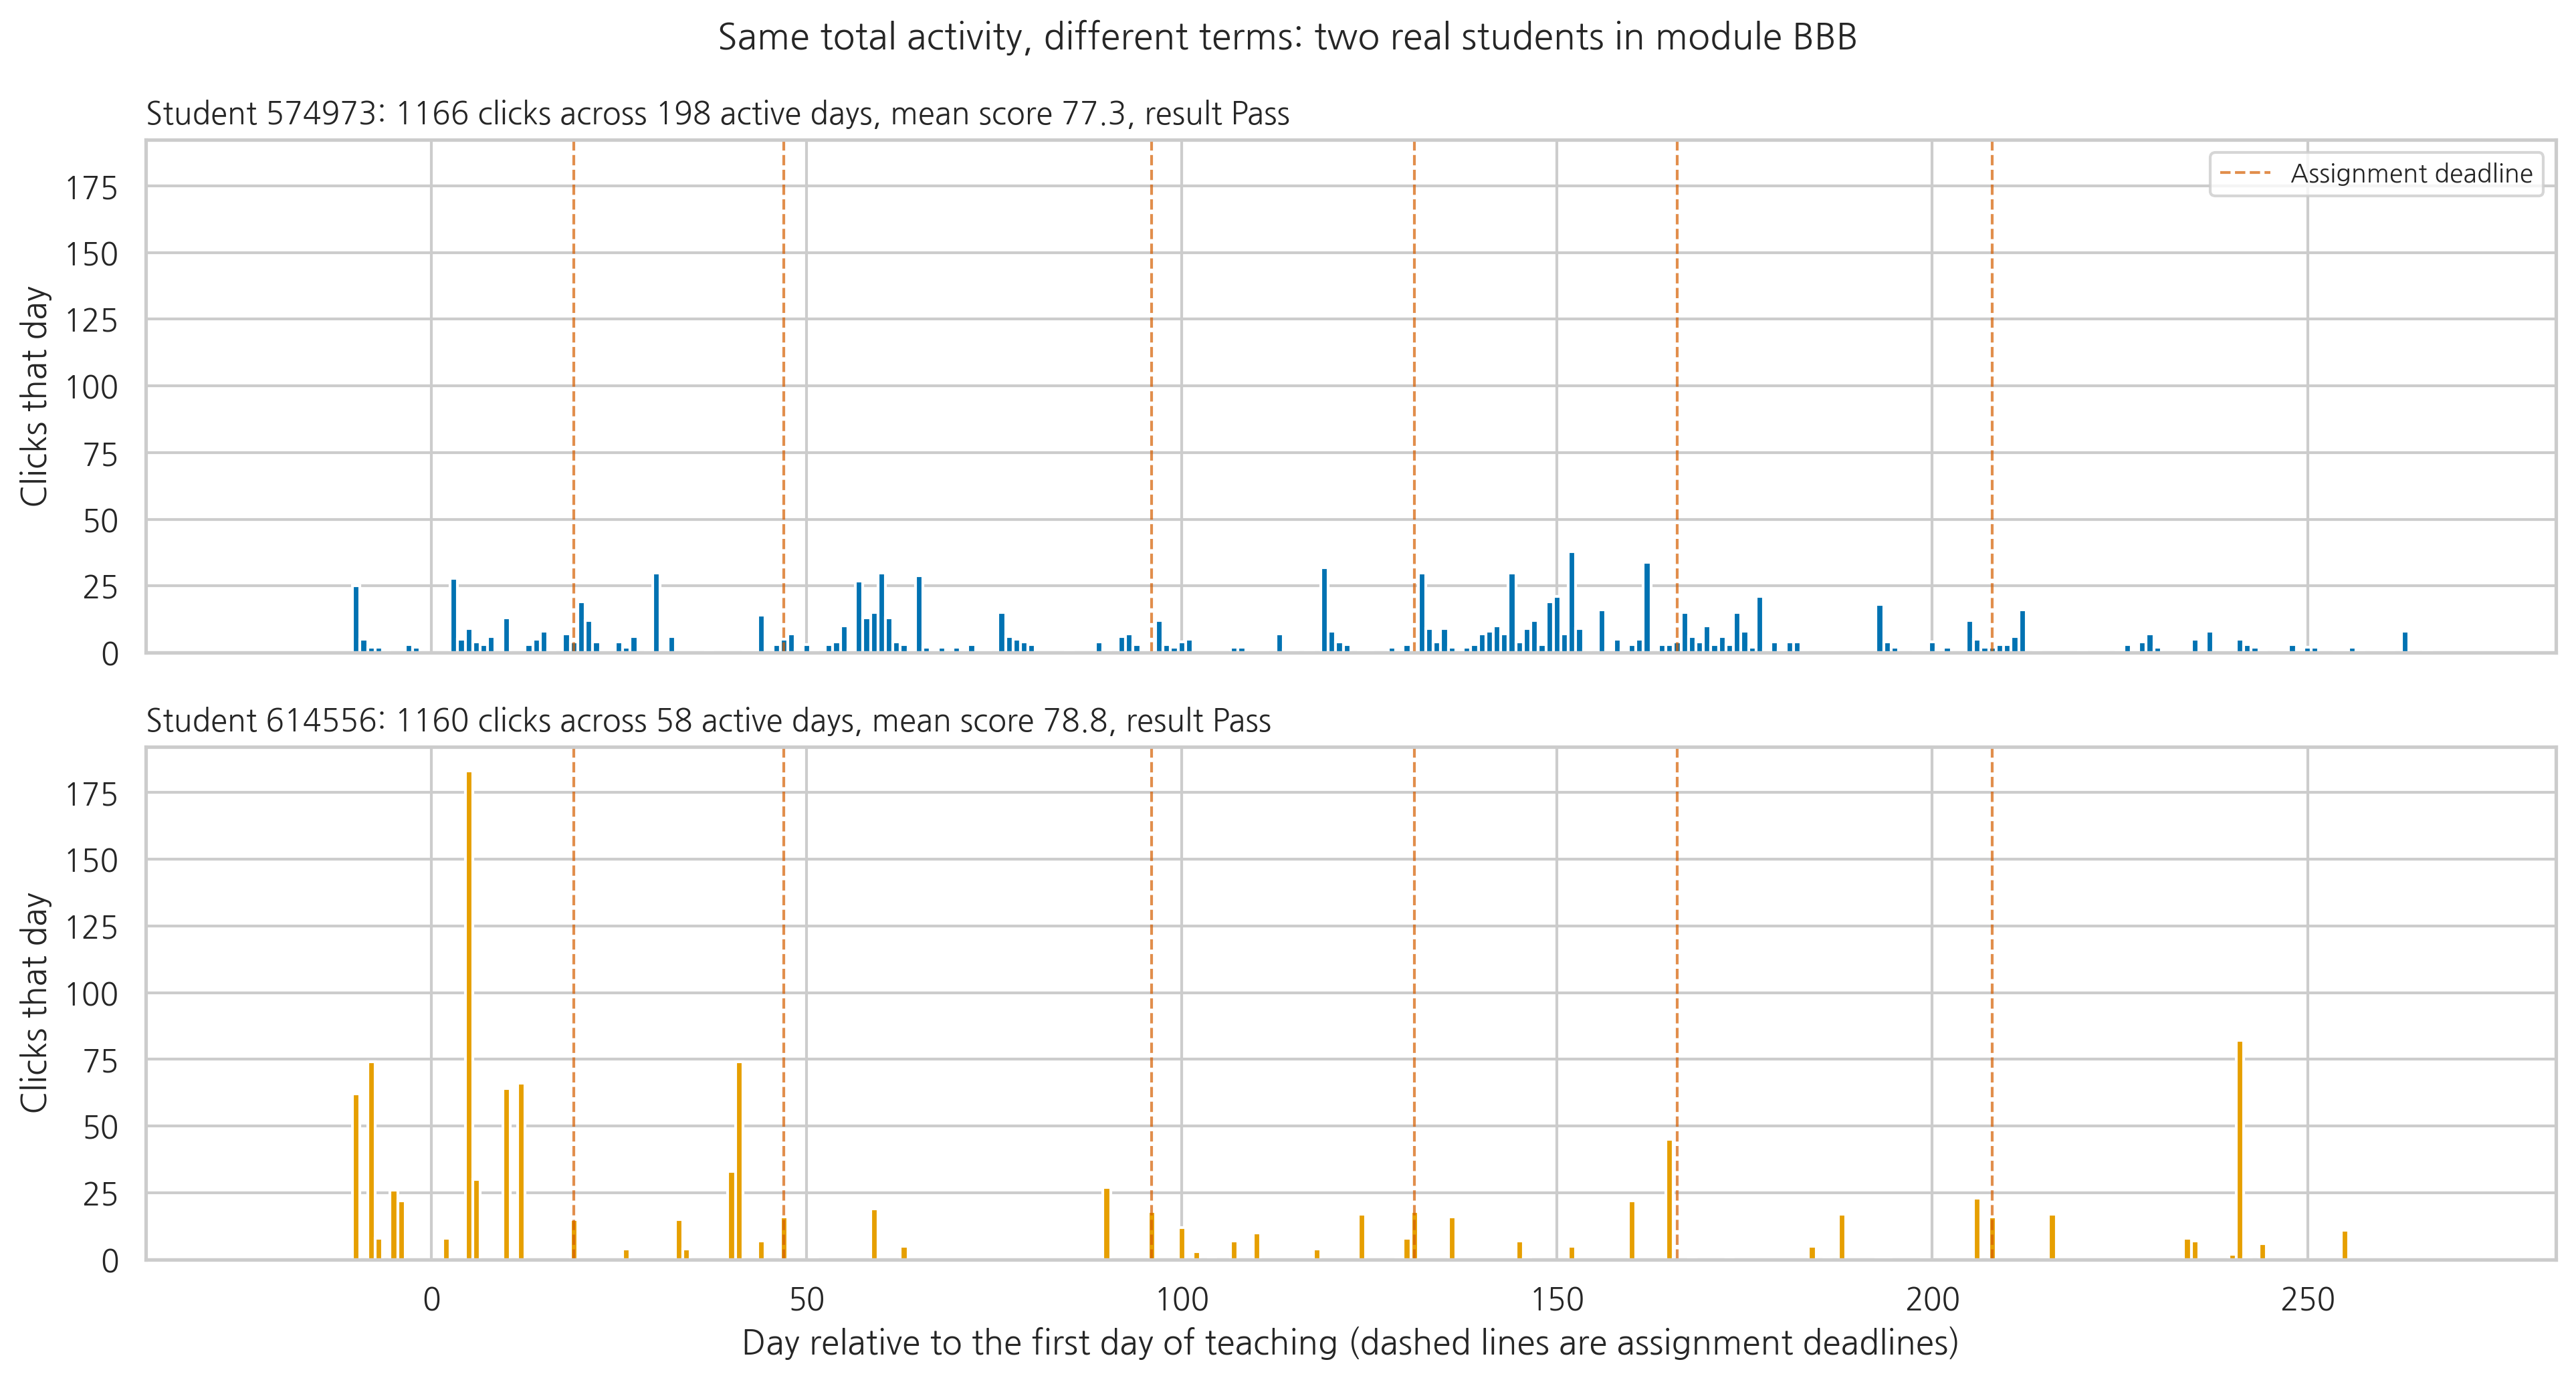

In [22]:
STUDENT_A = 574973   # steady, spread across the term
STUDENT_B = 614556   # concentrated, and submits on the deadline day every time

def student_profile(sid, presentation=PRESENTATION):
    """Daily clicks, submissions, and roster row for one student in one presentation."""
    v = student_vle[(student_vle['id_student'] == sid)
                    & (student_vle['code_presentation'] == presentation)]
    by_day = v.groupby('date')['sum_click'].sum()
    subs = lead[(lead['id_student'] == sid) & (lead['code_presentation'] == presentation)]
    info = student_info[(student_info['id_student'] == sid)
                        & (student_info['code_presentation'] == presentation)].iloc[0]
    return by_day, subs, info


def profile_row(sid, presentation=PRESENTATION):
    """One tidy summary row for a student, used here and again in Your turn 4."""
    by_day, subs, info = student_profile(sid, presentation)
    return {'id_student': sid,
            'total_clicks': int(by_day.sum()),
            'active_days': int(len(by_day)),
            'busiest_day_clicks': int(by_day.max()),
            'submissions': len(subs),
            'mean_days_early': round(subs['days_early'].mean(), 2),
            'mean_score': round(subs['score'].mean(), 1),
            'final_result': info['final_result'],
            'age_band': info['age_band'],
            'studied_credits': int(info['studied_credits'])}


profile_table = pd.DataFrame([profile_row(STUDENT_A), profile_row(STUDENT_B)])
print(profile_table.to_string(index=False))
print()
b_subs   = lead[(lead['id_student'] == STUDENT_B) & (lead['code_presentation'] == PRESENTATION)]
b_on_day = int((b_subs['days_early'] == 0).sum())
b_late   = int((b_subs['days_early'] < 0).sum())
print('Student', STUDENT_B, 'handed in', b_on_day, 'of', len(b_subs),
      'assignments on the deadline day itself and')
print(b_late, 'of them after it, by', int(-b_subs['days_early'].min()), 'days, and still finished with the')
print('higher mean score of the two.')

all_days = range(int(student_vle['date'].min()), int(student_vle['date'].max()) + 1)
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True, sharey=True)
for ax, sid, color in zip(axes, (STUDENT_A, STUDENT_B), (BLUE, ORANGE)):
    by_day, subs, info = student_profile(sid)
    series = by_day.reindex(all_days, fill_value=0)
    ax.bar(series.index, series.values, width=1.0, color=color)
    for i, d in enumerate(deadlines):
        ax.axvline(d, color=VERMILLION, linestyle='--', linewidth=1.0, alpha=0.7,
                   label='Assignment deadline' if (i == 0 and sid == STUDENT_A) else None)
    row = profile_table[profile_table['id_student'] == sid].iloc[0]
    ax.set_title('Student ' + str(sid) + ': ' + str(row['total_clicks']) + ' clicks across '
                 + str(row['active_days']) + ' active days, mean score ' + str(row['mean_score'])
                 + ', result ' + row['final_result'], fontsize=11, loc='left')
    ax.set_ylabel('Clicks that day')
axes[0].legend(fontsize=9, loc='upper right')
axes[1].set_xlabel('Day relative to the first day of teaching (dashed lines are assignment deadlines)')
fig.suptitle('Same total activity, different terms: two real students in module BBB', fontsize=13)
fig.tight_layout()
plt.show()

**💬 Interpretation prompt.**

1. An early-warning system built on "days active in the last two weeks" would have flagged one of these
   students repeatedly. Which one, and what exactly would it have got wrong about them?
2. Look at `studied_credits` in the table. One of these students was carrying half again as much study load
   as the other. Does that change which rhythm you would call healthy?
3. Molenaar and Wise (2022) separate measuring how much of something happened from measuring its passage,
   order, and pacing. Which of these two panels could you summarise honestly with a single number, and what
   would that number have to be?
4. You could have found a pair that told the opposite story, and the ✏️ Your turn cell below lets you. What
   obligation does that put on you when you choose which students appear in your memo?

## 2.9 So why is there no effect?

You had a hypothesis. You had a mechanism you could state. You had six weeks of data that agreed with you.
And the real module says nothing, or so close to nothing that the difference is not worth defending.

Do not resolve this quickly. Below are five explanations that survive contact with what you have seen. They
are not ranked, and this notebook is not going to pick one, because picking one is not something this data can
do for you.

**1. The measure may not be measuring the thing.** `date_submitted` is when a file arrived. It says nothing
about when the work started, how long it took, or how many evenings it swallowed. A student who begins three
weeks out and polishes until the last hour submits at the deadline and is not procrastinating in any sense
you care about. If that is common, then this whole analysis has been about upload times.

**2. These are not the students in your head.** OULAD students are adults in a distance-teaching university,
many with jobs, dependants, and a fixed number of hours a week that do not move. For someone who studies on
Sundays because Sunday is the day that exists, "early" is not a virtue and "at the deadline" is not a
symptom. Whatever the procrastination literature was built on, it was mostly not built on them.

**3. Very early may not mean what you think.** Look again at the rightmost bar in section 2.3. The people who
submitted eleven or more days early scored lowest of anyone. One reading: some of them are doing the smallest
piece of work that can be handed in, and getting it off the list. Early can be a sign of care, and it can be a
sign of disengagement, and a single axis cannot separate them.

**4. Range restriction, again.** Section 2.6 showed you 1,033 enrolments that never reach this analysis, most
of them withdrawals. If the strongest version of the effect lives in students who never submit at all, then
this file cannot see it, and no amount of care with the rows that remain will fix that.

**5. The effect may simply be smaller than we believe.** This is the possibility that is hardest to sit with
and the one worth taking most seriously. Plenty of findings that everyone knows are true turn out, in a large
enough sample of ordinary people, to be somewhere between tiny and absent. Here the sample is 15,347
submissions, which means an effect of any practical size would have shown up. It did not.

### The question this course exists to teach

You had a hypothesis, a plausible mechanism, and a synthetic dataset that confirmed it.

**What would you need to believe the effect exists in the world?**

Answer it concretely, in the reflection. Not "more research". What measurement, in what population, with what
comparison, would move you? And, because this is a course about consequences and not only about method: what
would you need before you would allow an institution to act on it?

## ✏️ Your turn 3: move the boundary and watch nothing happen

Seven days was a choice, not a fact about learning. A finding that appears only at one threshold is an
artefact of the threshold; a non-finding that survives every threshold is a much stronger claim.

Change `MY_THRESHOLD_DAYS` and rerun. Try `1`, then `3`, then `14`, then `21`. The cell also prints the whole
sweep, so you can see your chosen value in context.

In [23]:
# TODO: change this to any number of days you like.
MY_THRESHOLD_DAYS = 7   # working default

d_mine, n_early_mine, n_late_mine = contrast(lead, 'days_early', 'score', MY_THRESHOLD_DAYS)
print('Threshold                          :', MY_THRESHOLD_DAYS, 'or more days early')
print('Submissions that early             :', f"{n_early_mine:,}")
print('Submissions on or after the deadline:', f"{n_late_mine:,}")
print("Cohen's d between them             :", round(d_mine, 3))
print()

sweep = []
for thr in (1, 2, 3, 5, 7, 10, 14, 21):
    d, na, nb = contrast(lead, 'days_early', 'score', thr)
    sweep.append({'days_early_at_least': thr, 'n_early': na, 'cohens_d': round(d, 3)})
sweep = pd.DataFrame(sweep)
print('The whole sweep, for context:')
print(sweep.to_string(index=False))
print()
print('Every value sits between ' + str(sweep['cohens_d'].min()) + ' and '
      + str(sweep['cohens_d'].max()) + ', and it changes sign along the way.')
print('For scale, the same sweep on the synthetic course gives:')
for thr in (1, 3, 7):
    d, na, _ = contrast(quizzes, 'days_early', 'score', thr)
    print('  ' + str(thr) + ' or more days early: d =', round(d, 3), '(n =', str(na) + ')')

Threshold                          : 7 or more days early
Submissions that early             : 1,619
Submissions on or after the deadline: 5,905
Cohen's d between them             : -0.028

The whole sweep, for context:
 days_early_at_least  n_early  cohens_d
                   1     9442     0.099
                   2     5565     0.073
                   3     3879     0.056
                   5     2185     0.015
                   7     1619    -0.028
                  10     1029    -0.100
                  14      624    -0.205
                  21      213    -0.090

Every value sits between -0.205 and 0.099, and it changes sign along the way.
For scale, the same sweep on the synthetic course gives:
  1 or more days early: d = 0.616 (n = 482)
  3 or more days early: d = 0.872 (n = 225)
  7 or more days early: d = 1.969 (n = 50)


## ✏️ Your turn 4: find your own pair of real students

Section 2.8 showed you a pair that undercuts the intuition. The cell below searches the whole presentation for
pairs of students with near-identical click totals and very different rhythms, prints the ten most extreme,
and then plots whichever pair you name.

Choose deliberately, and notice how easy it is to choose a pair that flatters whatever you already believe.
That ease is the point of the exercise.

Pairs with near-identical click totals and very different rhythms: 294
 student_a  student_b  clicks_a  clicks_b  days_a  days_b  score_a  score_b    result_a  result_b  day_gap
    586516     600121      2573      2579      36     225     90.0     70.7   Withdrawn      Pass      189
    382979     586516      2578      2573     203      36     83.8     90.0 Distinction Withdrawn      167
    582591     600121      2569      2579      59     225     66.5     70.7        Fail      Pass      166
    509845     588910       908       907      36     191     53.0     85.8   Withdrawn      Pass      155
    189095     588910       904       907      38     191     69.0     85.8        Fail      Pass      153
    571779     574973      1175      1166      46     198     66.0     77.3        Pass      Pass      152
    593898     601499      1587      1578     223      77     72.3     64.7        Pass      Pass      146
    382979     582591      2578      2569     203      59     83.8     66

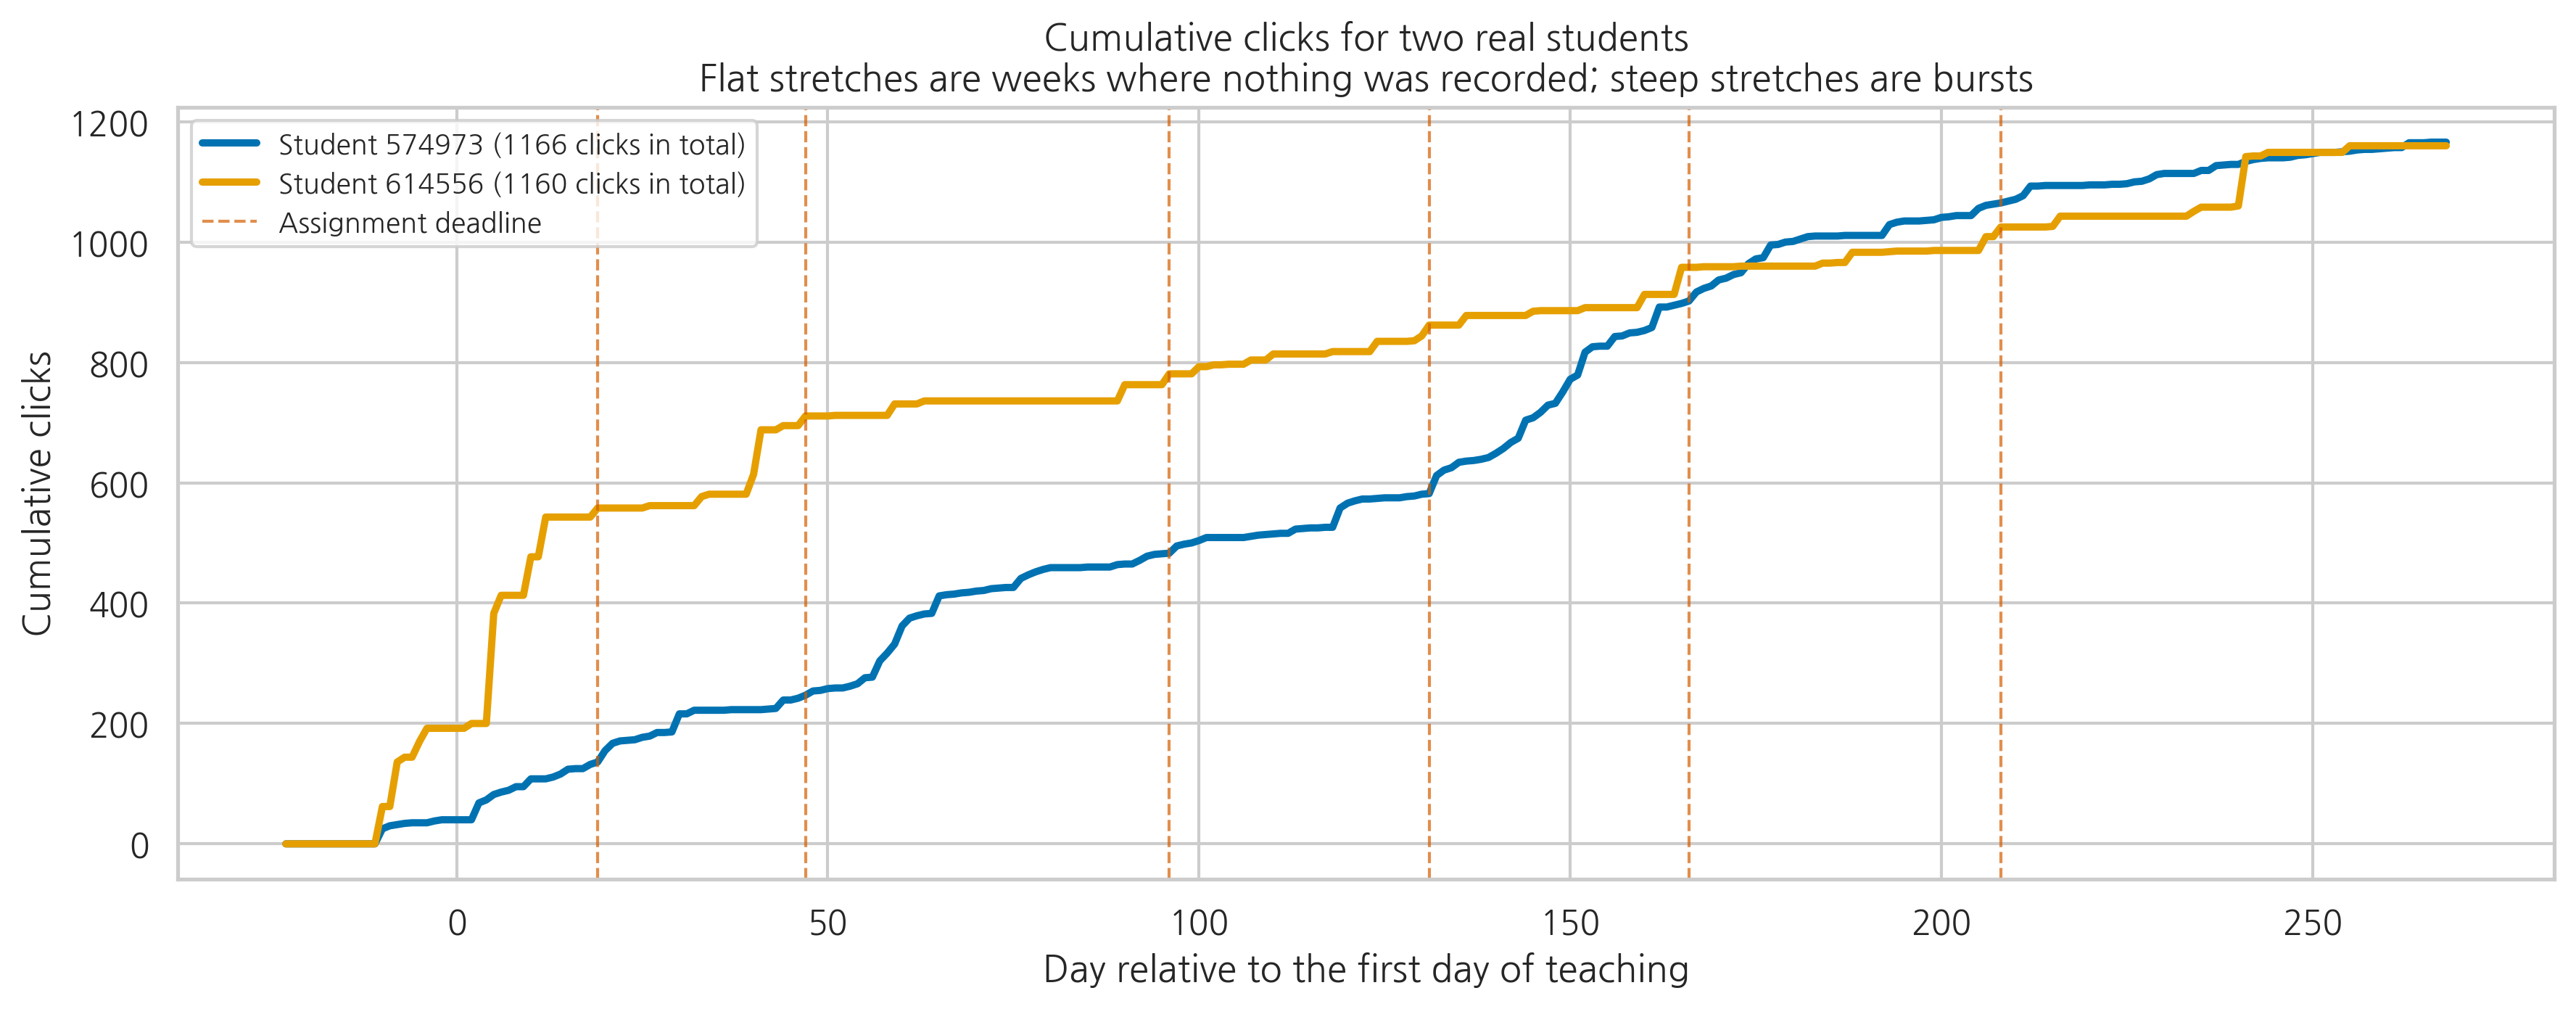

In [24]:
pres_profile = (student_vle[student_vle['code_presentation'] == PRESENTATION]
                .groupby('id_student')
                .agg(total_clicks=('sum_click', 'sum'), active_days=('date', 'nunique'))
                .reset_index())
pres_scores = (lead[lead['code_presentation'] == PRESENTATION]
               .groupby('id_student')['score'].mean().round(1).rename('mean_score').reset_index())
pool = (pres_profile.merge(pres_scores, on='id_student')
        .merge(student_info[student_info['code_presentation'] == PRESENTATION][['id_student', 'final_result']],
               on='id_student'))
pool = pool[(pool['total_clicks'] >= 800) & (pool['total_clicks'] <= 3000)].reset_index(drop=True)

clicks_arr = pool['total_clicks'].values
days_arr   = pool['active_days'].values
found = []
for i in range(len(pool)):
    close = np.abs(clicks_arr[i + 1:] - clicks_arr[i]) <= 10
    apart = np.abs(days_arr[i + 1:] - days_arr[i]) >= 45
    for j in np.where(close & apart)[0] + i + 1:
        a, b = pool.iloc[i], pool.iloc[j]
        found.append({'student_a': int(a['id_student']), 'student_b': int(b['id_student']),
                      'clicks_a': int(a['total_clicks']), 'clicks_b': int(b['total_clicks']),
                      'days_a': int(a['active_days']), 'days_b': int(b['active_days']),
                      'score_a': a['mean_score'], 'score_b': b['mean_score'],
                      'result_a': a['final_result'], 'result_b': b['final_result'],
                      'day_gap': int(abs(a['active_days'] - b['active_days']))})
found = pd.DataFrame(found).sort_values('day_gap', ascending=False)
print('Pairs with near-identical click totals and very different rhythms:', len(found))
print(found.head(10).to_string(index=False))

# TODO: change these two ids to any pair from the list above (or any two ids at all).
MY_A = 574973   # working default
MY_B = 614556   # working default

print()
print('Your chosen pair, in full:')
print(pd.DataFrame([profile_row(MY_A), profile_row(MY_B)]).to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 4.8))
for sid, color in zip((MY_A, MY_B), (BLUE, ORANGE)):
    by_day, _, _ = student_profile(sid)
    series = by_day.reindex(all_days, fill_value=0).cumsum()
    ax.plot(series.index, series.values, color=color, linewidth=2.4,
            label='Student ' + str(sid) + ' (' + str(int(series.iloc[-1])) + ' clicks in total)')
for i, d in enumerate(deadlines):
    ax.axvline(d, color=VERMILLION, linestyle='--', linewidth=1.0, alpha=0.7,
               label='Assignment deadline' if i == 0 else None)
ax.set_title('Cumulative clicks for two real students\n'
             'Flat stretches are weeks where nothing was recorded; steep stretches are bursts')
ax.set_xlabel('Day relative to the first day of teaching')
ax.set_ylabel('Cumulative clicks')
ax.legend(fontsize=9, loc='upper left')
fig.tight_layout()
plt.show()

**💬 Interpretation prompt.** Your two cumulative lines finish at the same height and get there
differently.

1. Name the stretch of the term where the two lines separate the most, and say what an instructor might
   have done in that stretch that a total click count would never have prompted.
2. Look at the `submissions` column in the profile table your pair printed. If a mean score is standing on
   one or two submissions, that number belongs in every sentence you write about that student. Write the
   sentence properly, with the number in it.
3. These are two real people, anonymised past the point of identification. Say one thing this figure does
   not entitle you to conclude about either of them.

---

# 🚀 Stretch: temporal network slices

Optional, and back on the synthetic forum. Everything in Part 1 pooled all eight weeks into one graph, which
treats the forum as a single static object. It is not. People arrive, drift, and reorganise.

This section splits the term in half (weeks 1 to 4, weeks 5 to 8), builds a network for each, and asks whether
the connectors are a stable role or a moment. If you have time, this is the richest place to extend the mini
project, and it is also the place where the two halves of this notebook finally speak to each other: it takes
a network question and makes it a temporal one.

       slice  posts  students  ties  density  avg_degree  communities  modularity  avg_path
Weeks 1 to 4    726        99   474    0.098        9.58            4       0.607      2.74
Weeks 5 to 8    730        98   486    0.102        9.92            3       0.620      2.86

Do the connectors keep bridging in both halves of the term?
student_id  betweenness_weeks_1_4  betweenness_weeks_5_8  rank_weeks_1_4  rank_weeks_5_8
      S020                  0.059                  0.170               7               2
      S101                  0.060                  0.113               6               5
      S031                  0.028                  0.049              21              14
      S043                  0.038                  0.134              13               3


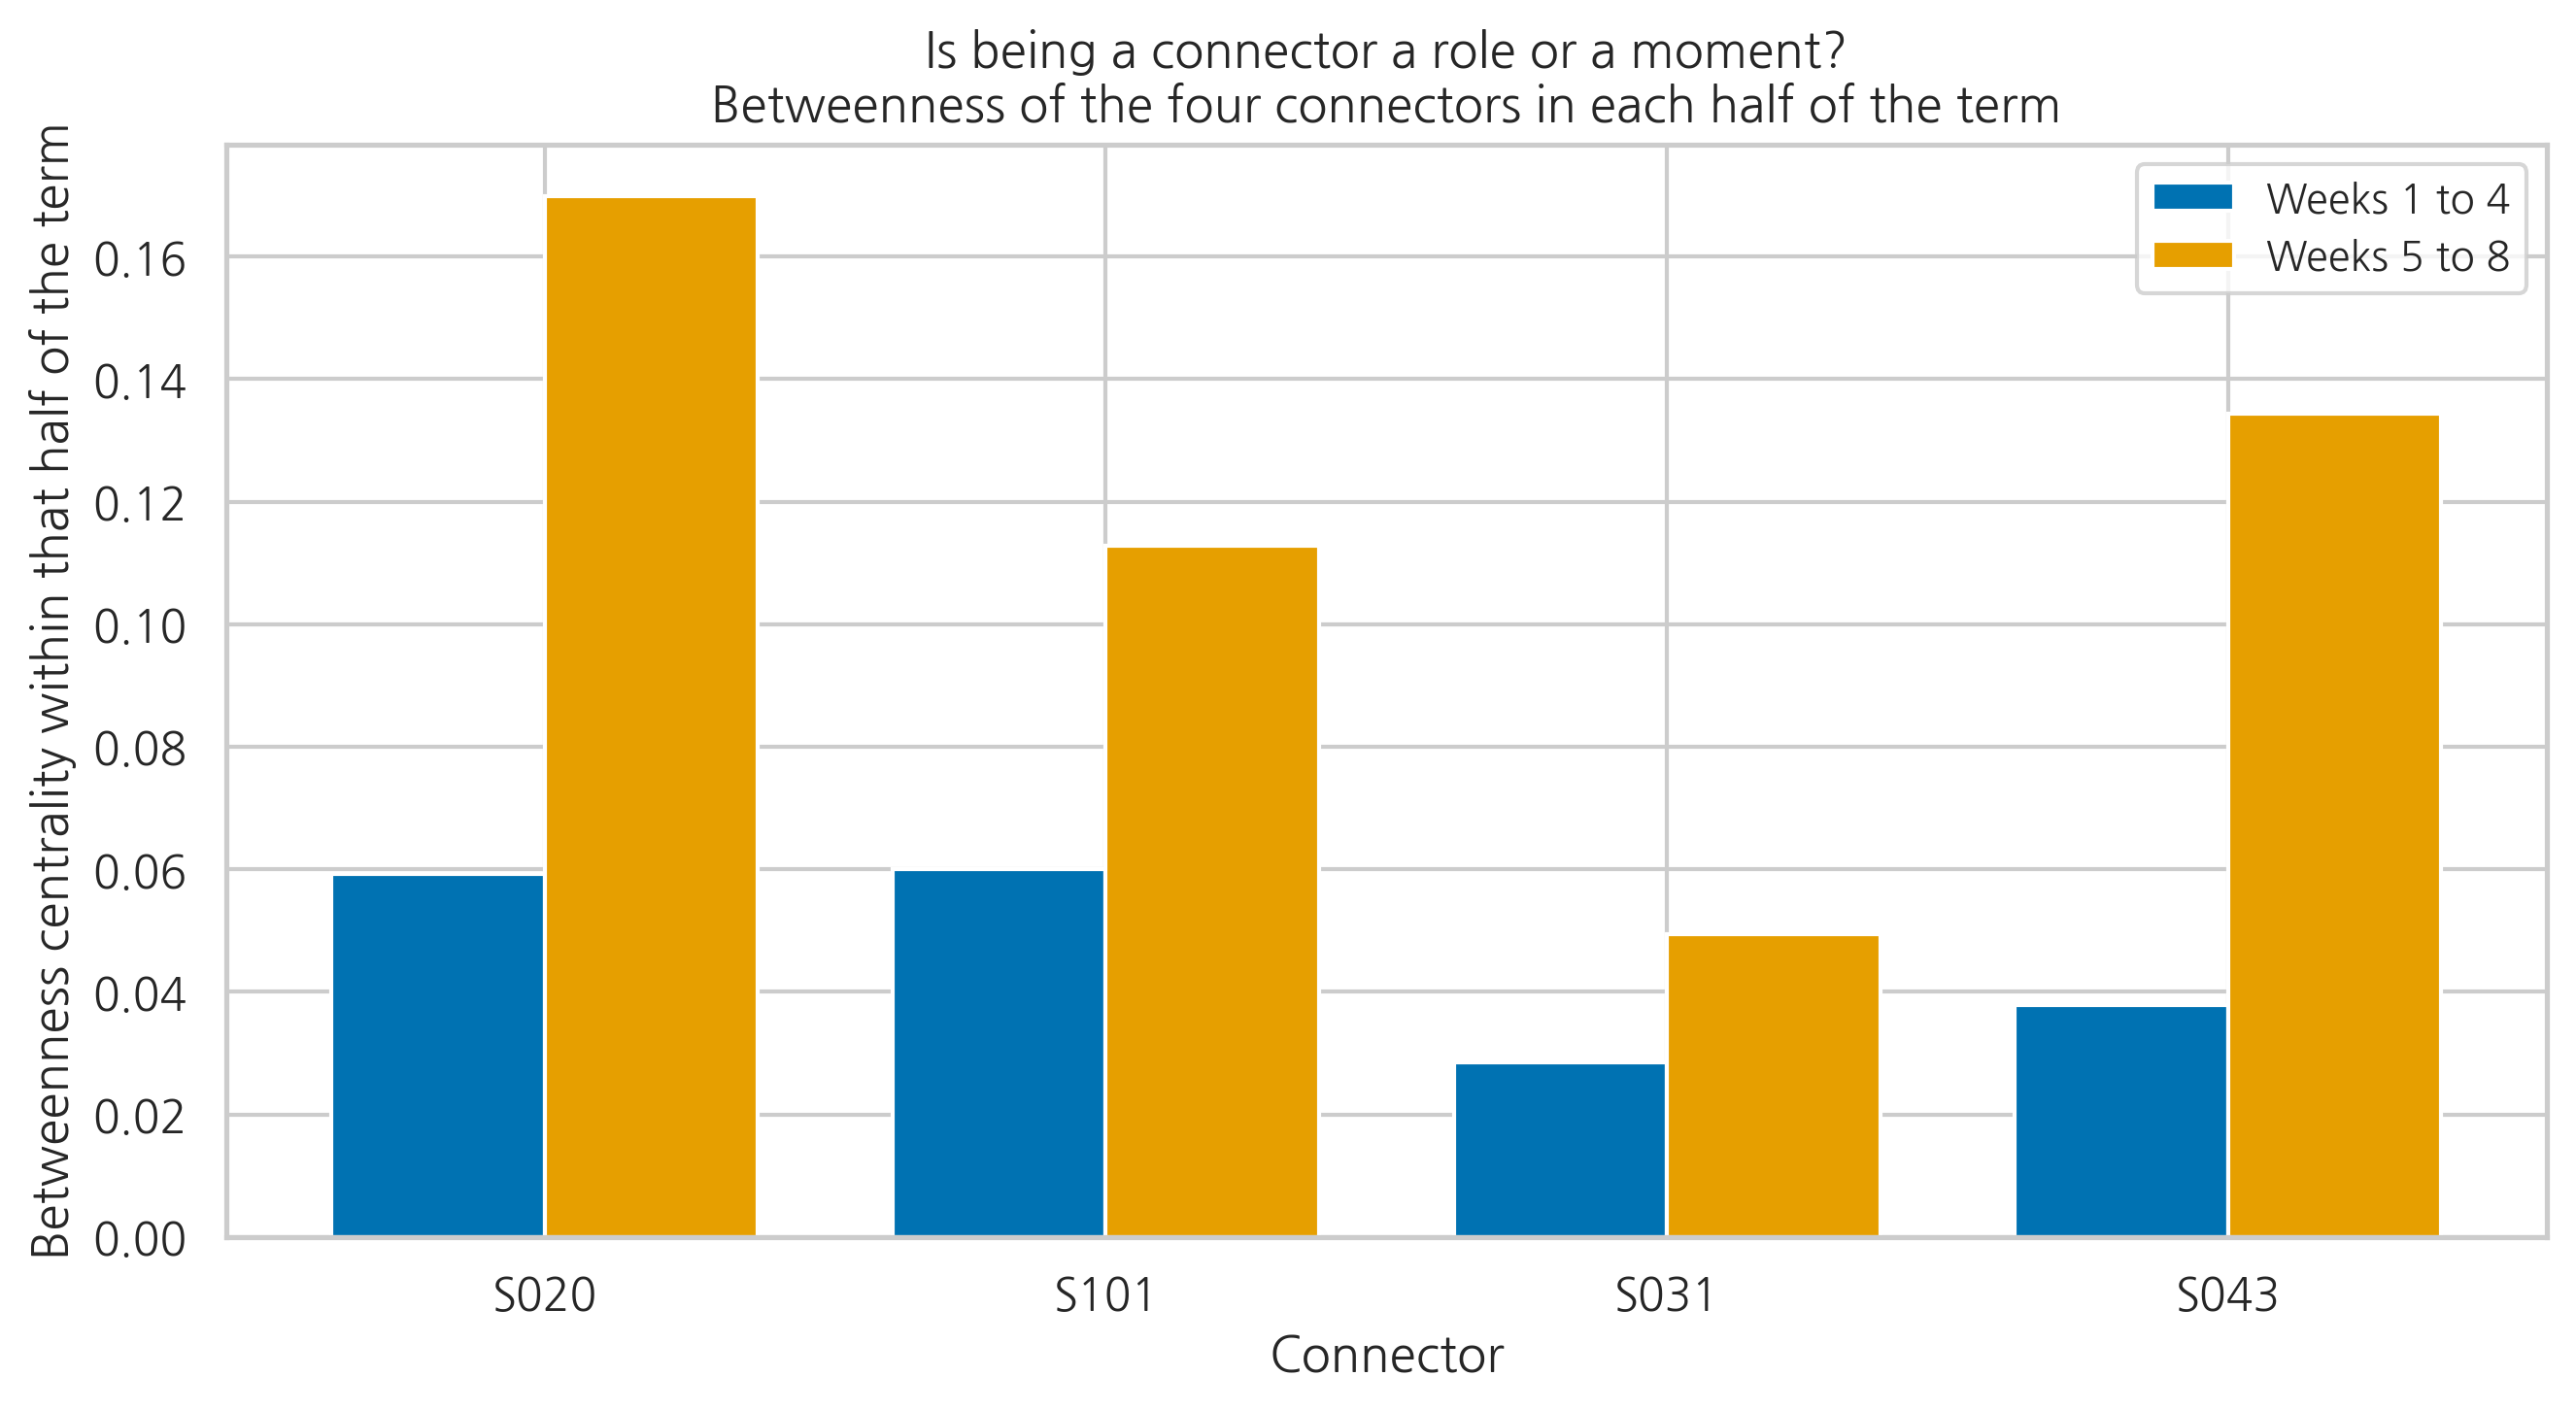

In [25]:
slices = {'Weeks 1 to 4': forum[forum['week'].between(1, 4)],
          'Weeks 5 to 8': forum[forum['week'].between(5, 8)]}

rows, slice_graphs = [], {}
for name, posts in slices.items():
    Gs = build_reply_network(posts)
    slice_graphs[name] = Gs
    comms = nx.community.greedy_modularity_communities(Gs, weight='weight')
    big = Gs.subgraph(max(nx.connected_components(Gs), key=len))
    rows.append({'slice': name, 'posts': len(posts),
                 'students': Gs.number_of_nodes(), 'ties': Gs.number_of_edges(),
                 'density': round(nx.density(Gs), 3),
                 'avg_degree': round(2 * Gs.number_of_edges() / Gs.number_of_nodes(), 2),
                 'communities': len(comms),
                 'modularity': round(nx.community.modularity(Gs, comms, weight='weight'), 3),
                 'avg_path': round(nx.average_shortest_path_length(big), 2)})
print(pd.DataFrame(rows).to_string(index=False))

btw_early = nx.betweenness_centrality(slice_graphs['Weeks 1 to 4'])
btw_late  = nx.betweenness_centrality(slice_graphs['Weeks 5 to 8'])

compare = pd.DataFrame({'student_id': connector_ids})
compare['betweenness_weeks_1_4'] = compare['student_id'].map(btw_early).fillna(0)
compare['betweenness_weeks_5_8'] = compare['student_id'].map(btw_late).fillna(0)
compare['rank_weeks_1_4'] = compare['student_id'].map(
    pd.Series(btw_early).rank(ascending=False).astype(int).to_dict())
compare['rank_weeks_5_8'] = compare['student_id'].map(
    pd.Series(btw_late).rank(ascending=False).astype(int).to_dict())
print()
print('Do the connectors keep bridging in both halves of the term?')
print(compare.round(3).to_string(index=False))

x = np.arange(len(compare))
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - 0.19, compare['betweenness_weeks_1_4'], width=0.38, color=BLUE, label='Weeks 1 to 4')
ax.bar(x + 0.19, compare['betweenness_weeks_5_8'], width=0.38, color=ORANGE, label='Weeks 5 to 8')
ax.set_xticks(x)
ax.set_xticklabels(compare['student_id'])
ax.set_title('Is being a connector a role or a moment?\n'
             'Betweenness of the four connectors in each half of the term')
ax.set_xlabel('Connector')
ax.set_ylabel('Betweenness centrality within that half of the term')
ax.legend(fontsize=10)
fig.tight_layout()
plt.show()

**💬 Interpretation prompt.** Compare the two halves in the summary table first: the number
of communities, the modularity, and the average path length. Is the forum's structure stable, or did the class
reorganise?

Then look at the bar chart. A connector whose betweenness holds up across both halves is playing a role. A
connector who appears in only one half was in the right place at the right time. Which of the four are which,
and how would that distinction change what you would say to an instructor who asked "who is holding this
discussion together"?

And one question you can only ask now: this is a temporal analysis of a network, run on invented data, next to
a temporal analysis of real data that refused to produce a finding. If you ran this slice comparison on a real
forum, which of your conclusions here would you expect to survive?

---

# ✍️ Your network reading memo

This is a required part of Mini Project 4. Write it in the cell below (double click the cell to edit it), or
write it in a document and upload it alongside the notebook, whichever you prefer.

**Roughly 500 to 600 words.** Address all five. Item 5 is new this week and it is not a throwaway.

1. **What the network shows.** Describe the structure of this forum for a reader who has not seen the figures.
   Use numbers, and be specific about which measure you are using at each point.
2. **The connectors.** Who are they, what makes them different from the highest degree students, and what
   would change in this forum without them? Say what you would need to know beyond this dataset before you
   were willing to act on the finding.
3. **The temporal half, and the result you did not get.** State the hypothesis you began with, state what the
   real Open University data returned, and give the two explanations from section 2.9 you find most credible
   and why. Then answer the closing question: what would you need in order to believe the effect exists in
   the world? Be concrete about measurement, population, and comparison.
4. **Limits, ethics, and equity.** Who is invisible in each analysis, and what would it cost them to be made
   visible? Reference at least one of this week's readings by author and year (Poquet and Joksimović, 2022;
   Molenaar and Wise, 2022; or Yan et al., 2025).
5. **On the fact that one half had to be simulated.** The network analysis in this notebook could not be done
   on open data, and the reason is not technical: the text that makes ties visible is the text that makes
   people identifiable, so it is removed before release or gated behind a data use agreement. What does that
   mean for the field, given that the network methods you just practised are published, taught, and cited
   constantly? Whose forums get studied, whose do not, and what should you personally do about it in your
   course project? Cite the Open University data properly if you refer to it (Kuzilek, Hlosta, and Zdrahal,
   2017).

### My network reading memo

*(Double click here and replace this text with your memo.)*

**What the network shows.**

**The connectors.**

**The temporal half, and the result I did not get.**

**Limits, ethics, and equity.**

**On the fact that one half had to be simulated.**

---

# 💬 Reflection

Answer these in the cell below, in a few sentences each. They are graded as part of the mini project's
Critical Reflection criterion, and they are also the questions the guest speaker is most likely to ask you.

1. **Poquet and Joksimović (2022)** describe learning analytics as a "cacophony of networks" because the same
   people yield different graphs depending on what the analyst counts as a tie. You built one graph from one
   choice. Name a second tie definition available in the synthetic data universe (forum, chat, studio, tutor),
   and say whose importance would rise or fall under it.

2. **Molenaar and Wise (2022)** argue that analyses have to be grounded in an explicit concept of time: time
   as a container to be filled, time as passage, time as order, time as rhythm. Which concept of time was the
   rolling engagement chart in section 2.7 using? Which was the timing analysis in section 2.3 using? Were
   they the same concept, and could that difference be part of why one of them found structure and the other
   did not?

3. **Yan et al. (2025)** dissect temporal dynamics in collaborative learning by treating sequence, not
   frequency, as the unit of analysis. Take the submission timing question and redesign it as a question about
   sequence rather than a question about a single date. What data would you need that OULAD does not have,
   and who would have to agree to collect it?

4. **Kuzilek, Hlosta, and Zdrahal (2017)** published the Open University data so that people outside the
   institution could study it. Someone decided that was acceptable, and the students in it were not asked.
   Write two sentences you actually believe: one about what open educational data makes possible, and one
   about what it costs. Then say what you would want a university to do before releasing your own records.

5. **The question the notebook ends on.** You had a hypothesis, a mechanism, and a dataset that agreed with
   you, and then a much larger real dataset that did not. What would you need to believe the effect exists in
   the world? And separately: what would you need before you would let an institution act on it?

6. **Guest speaker connection.** Yukyeong Song (University of Tennessee, Knoxville) works on fairness-aware
   analysis of learning behaviour. Pick one threshold you set in this notebook (the bridge share cutoff, the
   seven-day window, the decision to analyse only tutor-marked assignments) and say who could be
   systematically misclassified by it.

### My reflection

*(Double click here and replace this text with your answers.)*

**1.**

**2.**

**3.**

**4.**

**5.**

**6.**

---

# ✅ Submission checklist

**Mini Project 4 is due this week via Canvas.** Check the Canvas assignment page for the exact time.

Before you submit:

- [ ] The notebook runs top to bottom without errors. Use `Runtime` > `Restart session and run all` and watch
      it go green all the way down. The first cell needs an internet connection.
- [ ] All four **✏️ Your turn** cells have been edited at least once, and the notebook still runs afterward.
- [ ] Every **💬 Interpretation prompt** has a written answer in a markdown cell beneath it, including the
      prediction you wrote in section 2.1 **before** you saw the real result. Leave it in even though it was
      wrong. Especially because it was wrong.
- [ ] Your **network reading memo** (500 to 600 words, five parts) is complete, either in the memo cell or as
      a separate document.
- [ ] The **💬 Reflection** section is answered, referencing this week's readings by author and year.
- [ ] Anywhere you report a result from the real data, you have named the dataset and cited it: Open
      University Learning Analytics Dataset, CC BY 4.0, Kuzilek, Hlosta, and Zdrahal (2017).
- [ ] Download the notebook: `File` > `Download` > `Download .ipynb`. Upload it to the Mini Project 4
      assignment on Canvas.

**AI interaction log and reflection (required, separate Canvas submission).**

The course AI policy permits AI use in this activity and requires that you document it. Both pieces go to the
**AI Reflection** submission on Canvas, in two different places on that page:

- [ ] The full exchanges of every AI conversation connected to this project, across every session and every
      tool, pasted into a Word file and attached to that submission. Not into the text box, and not a link to
      a shared conversation.
- [ ] The reflection typed into the Canvas text box on the same page, copying in and answering the four
      questions from the syllabus: how you used it; whether it helped and how; whether it made your work
      harder in any way; and what lesson about AI from this week you would pass on to a classmate. If you used
      no AI at all, say so in the text box. That is a complete and legitimate answer.

Undisclosed AI use is an Honor Code violation. Disclosed AI use costs you nothing.

**Grading.** See the rubric in this folder's `README.md`: five criteria at 20 points each (End-to-End Analytics
Workflow, Data Preparation and Technical Care, Analysis and Visualization Choices, Interpretation and
Educational Meaning, Critical Reflection on Limits, Ethics, and Equity).

---

# 📎 Appendix: solutions to the "Your turn" cells

Read these after you have tried the exercises. They are here so you can check your reasoning, not so you can
skip the attempt. Each block is a working answer, not the only one.

### Your turn 1: moving the connector thresholds

```python
MY_MIN_DEGREE    = 5
MY_BRIDGE_CUTOFF = 0.25
```

Dropping the cutoff from 0.40 to 0.25 typically adds no one for a while, then starts admitting students whose
bridge share is in the 0.15 to 0.20 range. That gap in the bar chart is the real finding: the four connectors
are separated from everyone else by a wide margin, so the exact cutoff barely matters between roughly 0.25 and
0.40. Setting `MY_MIN_DEGREE = 2` is the instructive failure. Students with two or three ties can post a
bridge share of 0.5 or 1.0 by accident, and the list fills with people whose "bridging" rests on a single
reply.

The lesson to carry into your memo: report the sensitivity, not just the threshold. "Four students clear a
bridge share of 0.40, and the same four are the only ones above 0.25" is a much stronger sentence than "four
students clear 0.40".

### Your turn 2: one week at a time

```python
WEEK_TO_INSPECT = 7
```

Any single week holds roughly one eighth of the posts, so density falls hard (0.054 in week 3 against 0.146
for the pooled graph), the graph sometimes breaks into more than one component (weeks 7 and 8 do, week 3 does
not), and the top of the betweenness ranking changes from week to week. Some students appear in the weekly
top five once and never again.

One thing worth noticing while you are in there: a single week has about a fifth of the pooled graph's ties,
not an eighth, because pooling eight weeks merges repeat partners into one tie. The graph grows more slowly
than the posts do.

That instability is a real result about the measure, not a flaw in your code. Betweenness computed on a sparse
graph is high variance. If you want a weekly claim you need either more data per week or a measure that
degrades gracefully, such as simple degree.

### Your turn 3: moving the boundary

```python
MY_THRESHOLD_DAYS = 1    # then 3, then 14, then 21
```

The sweep printed by the cell is the answer. Cohen's *d* wanders in a narrow band around zero and changes sign
partway along: slightly positive when "early" means one or two days, slightly negative once "early" means ten
days or more. Nothing in that range would be worth reporting as a finding, and nothing in it would be worth
acting on.

Two things to take from this. First, the non-result is robust: it is not an accident of the seven-day choice,
because there is no choice that produces a result. Second, the sign change is a small warning about
researcher degrees of freedom. If you had gone looking for a positive effect you could have reported the
one-day threshold; if you had gone looking for a negative one you could have reported fourteen days. Neither
number means anything, and both would have been publishable-looking. Pre-registering the threshold, or
reporting the whole sweep as this cell does, is how you avoid fooling yourself.

### Your turn 4: find your own pair

```python
MY_A = 586516
MY_B = 600121
```

The search finds a few hundred pairs, which is the substantive point: near-identical click totals with
completely different rhythms are ordinary rather than exotic, in real data as in the simulated course.

The cumulative plot is often clearer than the daily bars for this comparison. A steady student's line is close
to straight. A burst student's line is a staircase: long flat stretches, then near-vertical climbs. Both lines
end at the same height, which is exactly the problem with reporting the height.

Now read the profile table the cell prints for the pair you chose, and compare `submissions`, `mean_score`,
and `final_result`. For the pair suggested above, one of the two has a high mean score, a very small number of
submissions standing behind it, and `Withdrawn` in the result column. A mean is a mean of something, and here
it is a mean of almost nothing.

Then, before you write a sentence about either of them, look one of them up directly:

```python
student_info[student_info['id_student'] == 586516]
```

What comes back is a good argument for never describing a student from a single row of a single table. Be
careful about which pair you choose to present, and notice how easy it is to select the pair that agrees with
you. These are real people. The anonymisation makes it impossible to identify them, which is precisely why you
owe them a careful sentence rather than a tidy one.

---

*EDIS 8100: Teaching and Learning Analytics · Fall 2026 · University of Virginia*
*Course design and synthetic data universe by Dr. Hakeoung Hannah Lee.*
*Real data: Open University Learning Analytics Dataset (module BBB), CC BY 4.0.*
*Kuzilek, J., Hlosta, M., & Zdrahal, Z. (2017). Open University Learning Analytics dataset. Scientific Data, 4, 170171.*